<a href="https://colab.research.google.com/github/EMADUDDINAsdaq/federated-learning-fairness-xray/blob/main/evaluation_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluation Notebook — CSC8639
Emaduddin Asdaq Syed Mohammed | MSc Data Science and AI

Evaluates all five FL aggregation strategies (FedAvg, q-FedAvg, Ada-IFFL,
GIFAIR-Global, GIFAIR-Per) on the frozen, patient-disjoint test splits.
Loads saved model weights only — no retraining.

**Framing:** all five methods are treated as symmetric candidates. None is
treated as a default/baseline to beat — the comparison at the end ranks
methods purely on the computed inter-client and demographic fairness metrics.

Levels:
1. Global pooled test performance per method
2. Per-hospital (inter-client fairness)
3. Per-sex within each hospital (demographic fairness)
4. Per-age-group within each hospital (demographic fairness)
4.5. Equal Opportunity Difference — Hardt, Price & Srebro (2016)
4.6. Intersectional subgroups (sex × age) — Crenshaw (1989); Buolamwini & Gebru (2018)
5. Cross-method comparison — summary table, ROC/PR curves, accuracy/FNR threshold
   sweep (0.1–0.7), and a final ranking across all fairness criteria

## Cell 1 — Environment Setup

In [ ]:
pip install flwr protobuf

In [ ]:
!pip install "flwr[simulation]" protobuf -q
print("✓ Libraries installed")

✓ Libraries installed


In [ ]:
import flwr as fl
print(f"flwr : {fl.__version__}")
print("✓ Flower working")

flwr : 1.32.1
✓ Flower working


In [ ]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import (roc_curve, precision_recall_curve,
                              roc_auc_score, average_precision_score)
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
warnings.filterwarnings('ignore')

print(f"torch : {torch.__version__}")
print(f"numpy : {np.__version__}")
print(f"GPU   : {torch.cuda.is_available()}")

# Shared plotting style — used by every figure in this notebook so ROC, PR,
# and threshold-sweep plots look consistent on the poster/report
plt.rcParams.update({
    'figure.dpi'      : 150,
    'font.size'       : 11,
    'axes.titlesize'  : 12,
    'axes.titleweight': 'bold',
    'axes.labelsize'  : 10,
    'legend.fontsize' : 9,
    'axes.grid'       : True,
    'grid.alpha'      : 0.25,
    'lines.linewidth' : 2.2,
})
print("✓ Shared plot style applied")

torch : 2.11.0+cu128
numpy : 2.0.2
GPU   : True
✓ Shared plot style applied


## Cell 2 — Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Cell 3 — Load Frozen Test Splits (check BEFORE downloading images)

In [ ]:
SPLIT_DIR = '/content/drive/MyDrive/dissertation/splits'
HOSPITAL_NAMES = ['Hospital_A', 'Hospital_B', 'Hospital_C',
                  'Hospital_D', 'Hospital_E']

test_clients = {n: pd.read_csv(f'{SPLIT_DIR}/{n}_test.csv') for n in HOSPITAL_NAMES}

for name in HOSPITAL_NAMES:
    print(f"{name}: {len(test_clients[name]):,} test images | "
          f"pathology {test_clients[name]['label'].mean()*100:.1f}%")

print("\n✓ Frozen test splits loaded — same splits used for all five training runs")

Hospital_A: 3,005 test images | pathology 59.1%
Hospital_B: 508 test images | pathology 100.0%
Hospital_C: 1,711 test images | pathology 7.9%
Hospital_D: 74 test images | pathology 70.3%
Hospital_E: 168 test images | pathology 11.3%

✓ Frozen test splits loaded — same splits used for all five training runs


## Cell 4 — Dataset Download (Kaggle) — only if images not already local

In [ ]:
import shutil

os.makedirs('/root/.kaggle', exist_ok=True)
shutil.copy('/content/drive/MyDrive/dissertation/kaggle.json',
            '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

os.system('pip install -q kaggle')
os.system('kaggle datasets download -d nih-chest-xrays/data '
          '--path /content/nih_kaggle --unzip --quiet')

DATASET_PATH = '/content/nih_kaggle'

sample_path = test_clients['Hospital_A']['image_path'].iloc[0]
assert os.path.exists(sample_path), f"Path not found: {sample_path} — check download completed"
print("✓ Image paths resolve correctly in this session")

✓ Image paths resolve correctly in this session


## Cell 5 — GPU / Batch Config

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

torch.backends.cudnn.benchmark = True

BATCH_SIZE  = 512
NUM_WORKERS = 4

print(f"✓ BATCH_SIZE  : {BATCH_SIZE}")
print(f"✓ NUM_WORKERS : {NUM_WORKERS}")

Device: cuda
✓ BATCH_SIZE  : 512
✓ NUM_WORKERS : 4


## Cell 6 — Transforms, Dataset, Model (identical to training notebooks)

In [ ]:
IMAGE_SIZE = 224

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(row['label'], dtype=torch.float32)

def build_model():
    model    = models.resnet18(weights='IMAGENET1K_V1')
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model

def load_model(path):
    model = build_model().to(device)
    state = torch.load(path, map_location=device)
    model.load_state_dict(state)
    model.eval()
    return model

print("✓ Dataset class, model, transforms ready")

✓ Dataset class, model, transforms ready


## Cell 7 — Get raw probabilities per hospital
Returns probs/labels only — all downstream metrics (AUC, FNR at any threshold,
per-sex, per-age) are computed later from these, so images are only passed
through the network once per method per hospital.

In [ ]:
def get_probs(model, dataframe):
    loader = DataLoader(
        ChestXrayDataset(dataframe, transform=val_transform),
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True,
        persistent_workers=True
    )
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            probs = torch.sigmoid(
                model(images.to(device, non_blocking=True))
            ).cpu().numpy()
            all_probs.extend(probs.flatten())
            all_labels.extend(labels.numpy())
    return np.array(all_probs), np.array(all_labels)

print("✓ get_probs() defined")

✓ get_probs() defined


## Cell 8 — Method Registry

In [ ]:
SAVE_DIR = '/content/drive/MyDrive/dissertation/results'

# Each method maps to one global model file, EXCEPT GIFAIR-Per, which uses
# a personalised model per hospital (per Yue et al. 2022 Algorithm 3 — the
# personalised weights are the method's actual output, not the global average).
METHODS = {
    'FedAvg'        : f'{SAVE_DIR}/fedavg_full_model.pth',
    'q-FedAvg'      : f'{SAVE_DIR}/qfedavg_full_model.pth',
    'Ada-IFFL'      : f'{SAVE_DIR}/adaiffl_full_model.pth',
    'GIFAIR-Global' : f'{SAVE_DIR}/gifair_global_FIXED_model.pth',
    'GIFAIR-Per'    : None,  # resolved per-hospital below
}

COLOURS = {
    'FedAvg'        : '#2196F3',
    'q-FedAvg'      : '#FF9800',
    'Ada-IFFL'      : '#9C27B0',
    'GIFAIR-Global' : '#4CAF50',
    'GIFAIR-Per'    : '#F44336',
}

print("✓ Method registry ready — 5 methods, all trained on the frozen splits")

✓ Method registry ready — 5 methods, all trained on the frozen splits


## Cell 9 — Collect Predictions for All Methods × All Hospitals
Runs inference once per method per hospital. This is the only cell that
touches the GPU/model forward pass — everything after this is pure metric
computation on stored probs/labels, so re-running any analysis below never
requires re-running this cell.

In [ ]:
path = f'{SAVE_DIR}/gifair_global_FIXED_model.pth'
print(os.path.exists(path), os.path.getsize(path)/1e6 if os.path.exists(path) else "MISSING")

True 44.785483


In [ ]:

SAVE_DIR = '/content/drive/MyDrive/dissertation/results'

print("=== GIFAIR-Per file check ===")
for name in HOSPITAL_NAMES:
    path = f'{SAVE_DIR}/gifair_per_full_{name}_model.pth'
    exists = os.path.exists(path)
    size = f"{os.path.getsize(path)/1e6:.1f} MB" if exists else "MISSING"
    print(f"  {name}: {exists} — {size}")

=== GIFAIR-Per file check ===
  Hospital_A: False — MISSING
  Hospital_B: False — MISSING
  Hospital_C: False — MISSING
  Hospital_D: False — MISSING
  Hospital_E: False — MISSING


In [ ]:
paths = [f'{SAVE_DIR}/gifair_per_FIXED_{name}_model.pth' for name in HOSPITAL_NAMES]
for path in paths:
    print(os.path.basename(path), "→", os.path.exists(path),
          f"{os.path.getsize(path)/1e6:.1f} MB" if os.path.exists(path) else "")

gifair_per_FIXED_Hospital_A_model.pth → True 44.8 MB
gifair_per_FIXED_Hospital_B_model.pth → True 44.8 MB
gifair_per_FIXED_Hospital_C_model.pth → True 44.8 MB
gifair_per_FIXED_Hospital_D_model.pth → True 44.8 MB
gifair_per_FIXED_Hospital_E_model.pth → True 44.8 MB


In [ ]:
all_data = {}  # all_data[method][hospital] = (probs, labels)

for method in METHODS:
    print(f"Loading {method}...")
    all_data[method] = {}

    for name in HOSPITAL_NAMES:
        data = test_clients[name]

        if method == 'GIFAIR-Per':
            model_path = f'{SAVE_DIR}/gifair_per_FIXED_{name}_model.pth'
        else:
            model_path = METHODS[method]

        model = load_model(model_path)
        probs, labels = get_probs(model, data)
        all_data[method][name] = (probs, labels)
        print(f"  {name}: {len(labels)} samples, prevalence={labels.mean()*100:.1f}%")
        del model
        torch.cuda.empty_cache()

print("\n✓ All predictions collected — 5 methods × 5 hospitals")

Loading FedAvg...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 105MB/s]


  Hospital_A: 3005 samples, prevalence=59.1%
  Hospital_B: 508 samples, prevalence=100.0%
  Hospital_C: 1711 samples, prevalence=7.9%
  Hospital_D: 74 samples, prevalence=70.3%
  Hospital_E: 168 samples, prevalence=11.3%
Loading q-FedAvg...
  Hospital_A: 3005 samples, prevalence=59.1%
  Hospital_B: 508 samples, prevalence=100.0%
  Hospital_C: 1711 samples, prevalence=7.9%
  Hospital_D: 74 samples, prevalence=70.3%
  Hospital_E: 168 samples, prevalence=11.3%
Loading Ada-IFFL...
  Hospital_A: 3005 samples, prevalence=59.1%
  Hospital_B: 508 samples, prevalence=100.0%
  Hospital_C: 1711 samples, prevalence=7.9%
  Hospital_D: 74 samples, prevalence=70.3%
  Hospital_E: 168 samples, prevalence=11.3%
Loading GIFAIR-Global...
  Hospital_A: 3005 samples, prevalence=59.1%
  Hospital_B: 508 samples, prevalence=100.0%
  Hospital_C: 1711 samples, prevalence=7.9%
  Hospital_D: 74 samples, prevalence=70.3%
  Hospital_E: 168 samples, prevalence=11.3%
Loading GIFAIR-Per...
  Hospital_A: 3005 samples, p

In [ ]:
EVAL_DIR = f'{SAVE_DIR}/evaluate'
os.makedirs(EVAL_DIR, exist_ok=True)
SAVE_DIR = EVAL_DIR
print(f"✓ Evaluation outputs will now save to: {SAVE_DIR}")

✓ Evaluation outputs will now save to: /content/drive/MyDrive/dissertation/results/evaluate


## Cell 10 — Metric Helper Functions
Single set of functions used consistently across every level (global, per-hospital,
per-sex, per-age) so numbers are directly comparable across the whole notebook.

In [ ]:
FIXED_THRESHOLDS = [0.3, 0.5, 0.7]

def compute_metrics(labels, probs, thresholds=FIXED_THRESHOLDS):
    result = {}
    if labels.sum() > 0 and labels.sum() < len(labels):
        result['roc_auc'] = round(float(roc_auc_score(labels, probs)), 4)
    else:
        result['roc_auc'] = float('nan')

    if labels.sum() > 0:
        result['avg_precision'] = round(float(average_precision_score(labels, probs)), 4)
    else:
        result['avg_precision'] = float('nan')

    for t in thresholds:
        preds = (probs > t).astype(int)
        fn = int(((preds == 0) & (labels == 1)).sum())
        tp = int(((preds == 1) & (labels == 1)).sum())
        result[f'fnr_at_{t}'] = round(fn / (fn + tp), 4) if (fn + tp) > 0 else float('nan')

    preds_05 = (probs > 0.5).astype(int)
    result['accuracy'] = round(float((preds_05 == labels).mean() * 100), 2)
    result['n'] = int(len(labels))
    result['prevalence'] = round(float(labels.mean() * 100), 2)
    result['predicted_positive_rate'] = round(float(preds_05.mean() * 100), 2)
    return result

print("✓ compute_metrics() defined — ROC-AUC, AP, FNR@0.3/0.5/0.7, accuracy, prevalence check")

✓ compute_metrics() defined — ROC-AUC, AP, FNR@0.3/0.5/0.7, accuracy, prevalence check


## Level 1 - Global Pooled Performance
Pools every hospital's test set together per method - one number per method
showing overall model quality, ignoring which hospital the image came from.

In [ ]:
global_results = []

for method in METHODS:
    all_probs  = np.concatenate([all_data[method][h][0] for h in HOSPITAL_NAMES
                                  if h in all_data[method]])
    all_labels = np.concatenate([all_data[method][h][1] for h in HOSPITAL_NAMES
                                  if h in all_data[method]])
    m = compute_metrics(all_labels, all_probs)
    m['Method'] = method
    global_results.append(m)

df_global = pd.DataFrame(global_results).set_index('Method')
cols = ['n', 'prevalence', 'predicted_positive_rate', 'roc_auc', 'avg_precision',
        'fnr_at_0.3', 'fnr_at_0.5', 'fnr_at_0.7', 'accuracy']
df_global = df_global[cols]
print("=== Level 1 — Global Pooled Test Performance ===\n")
print(df_global.to_string())

=== Level 1 — Global Pooled Test Performance ===

                  n  prevalence  predicted_positive_rate  roc_auc  avg_precision  fnr_at_0.3  fnr_at_0.5  fnr_at_0.7  accuracy
Method                                                                                                                        
FedAvg         5466       45.54                    19.52   0.7556         0.7050      0.2696      0.6742      0.9932     64.62
q-FedAvg       5466       45.54                    80.99   0.4574         0.4258      0.0000      0.2182      0.9936     44.68
Ada-IFFL       5466       45.54                     0.07   0.4538         0.4261      0.6380      0.9992      1.0000     54.46
GIFAIR-Global  5466       45.54                    49.60   0.7236         0.6782      0.0121      0.3274      0.8690     66.12
GIFAIR-Per     5466       45.54                    52.98   0.8688         0.8330      0.0800      0.1619      0.2784     77.81


In [ ]:
MIN_AUC = 0.55  # threshold above random chance (0.5) a method must clear

is_discriminative = {}
print("=== Validity Check — Is Each Method Actually Discriminating? ===\n")
for method in METHODS:
    auc        = df_global.loc[method, 'roc_auc']
    pred_rate  = df_global.loc[method, 'predicted_positive_rate']
    prevalence = df_global.loc[method, 'prevalence']
    valid      = bool(auc > MIN_AUC)
    is_discriminative[method] = valid
    flag = "discriminative" if valid else "NOT reliably discriminative"
    print(f"  {method:<15} AUC={auc:.3f} | predicts positive {pred_rate:>5.1f}% "
          f"(actual prevalence {prevalence:>5.1f}%) | {flag}")

print(f"\nMethods below AUC {MIN_AUC} did not learn a working classifier in this run.")

=== Validity Check — Is Each Method Actually Discriminating? ===

  FedAvg          AUC=0.756 | predicts positive  19.5% (actual prevalence  45.5%) | discriminative
  q-FedAvg        AUC=0.457 | predicts positive  81.0% (actual prevalence  45.5%) | NOT reliably discriminative
  Ada-IFFL        AUC=0.454 | predicts positive   0.1% (actual prevalence  45.5%) | NOT reliably discriminative
  GIFAIR-Global   AUC=0.724 | predicts positive  49.6% (actual prevalence  45.5%) | discriminative
  GIFAIR-Per      AUC=0.869 | predicts positive  53.0% (actual prevalence  45.5%) | discriminative

Methods below AUC 0.55 did not learn a working classifier in this run.


In [ ]:
def bootstrap_auc_ci(labels, probs, n_boot=1000, seed=42):
    rng = np.random.RandomState(seed)
    n = len(labels)
    aucs = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        y, p = labels[idx], probs[idx]
        if y.sum() == 0 or y.sum() == n:
            continue
        aucs.append(roc_auc_score(y, p))
    return float(np.percentile(aucs, 2.5)), float(np.percentile(aucs, 97.5))

ci_rows = []
for method in METHODS:
    all_probs  = np.concatenate([all_data[method][h][0] for h in HOSPITAL_NAMES])
    all_labels = np.concatenate([all_data[method][h][1] for h in HOSPITAL_NAMES])
    lo, hi = bootstrap_auc_ci(all_labels, all_probs)
    ci_rows.append({'Method': method, 'auc_ci_low': round(lo, 3), 'auc_ci_high': round(hi, 3)})

df_ci = pd.DataFrame(ci_rows).set_index('Method')
print("=== 95% Bootstrap Confidence Intervals — Global ROC-AUC ===\n")
print(df_ci.to_string())

# Publication-ready table — built from results already computed above
pub_table = df_global[['n', 'prevalence', 'roc_auc', 'fnr_at_0.5', 'accuracy']].copy()
pub_table['95% CI'] = [f"[{df_ci.loc[m,'auc_ci_low']:.3f}, {df_ci.loc[m,'auc_ci_high']:.3f}]" for m in pub_table.index]
pub_table['Discriminative?'] = [('Yes' if is_discriminative[m] else 'No') for m in pub_table.index]
pub_table.columns = ['N', 'Prevalence (%)', 'ROC-AUC', 'FNR @0.5', 'Accuracy (%)', '95% CI (AUC)', 'Discriminative?']

print("\n=== Publication-Ready Summary Table ===\n")
print(pub_table.to_string())
pub_table.to_csv(f'{SAVE_DIR}/publication_summary_table.csv')
print("\n✓ Saved → publication_summary_table.csv")

=== 95% Bootstrap Confidence Intervals — Global ROC-AUC ===

               auc_ci_low  auc_ci_high
Method                                
FedAvg              0.743        0.768
q-FedAvg            0.442        0.472
Ada-IFFL            0.440        0.470
GIFAIR-Global       0.710        0.736
GIFAIR-Per          0.860        0.878

=== Publication-Ready Summary Table ===

                  N  Prevalence (%)  ROC-AUC  FNR @0.5  Accuracy (%)    95% CI (AUC) Discriminative?
Method                                                                                              
FedAvg         5466           45.54   0.7556    0.6742         64.62  [0.743, 0.768]             Yes
q-FedAvg       5466           45.54   0.4574    0.2182         44.68  [0.442, 0.472]              No
Ada-IFFL       5466           45.54   0.4538    0.9992         54.46  [0.440, 0.470]              No
GIFAIR-Global  5466           45.54   0.7236    0.3274         66.12  [0.710, 0.736]             Yes
GIFAIR-Per     546

## Level 2 — Per-Hospital (Inter-Client Fairness)
Same metrics, computed separately per hospital, per method. AUC variance
across hospitals is the inter-client fairness metric used in the dissertation.

In [ ]:
hospital_rows = []

for method in METHODS:
    for name in HOSPITAL_NAMES:
        if name not in all_data[method]:
            continue
        probs, labels = all_data[method][name]
        m = compute_metrics(labels, probs)
        m['Method']   = method
        m['Hospital'] = name
        hospital_rows.append(m)

df_hospital = pd.DataFrame(hospital_rows)
print("=== Level 2 — Per-Hospital Performance ===\n")
print(df_hospital[['Method', 'Hospital', 'n', 'prevalence', 'roc_auc',
                    'avg_precision', 'fnr_at_0.5', 'accuracy']].to_string(index=False))

print("\n=== Inter-Client AUC Variance per Method ===")
inter_client_variance = {}
for method in METHODS:
    aucs = df_hospital[df_hospital['Method'] == method]['roc_auc'].dropna().values
    if len(aucs) > 0:
        inter_client_variance[method] = float(np.var(aucs))
        print(f"  {method:<15} : variance={np.var(aucs):.6f} | "
              f"range={aucs.min():.4f}-{aucs.max():.4f} | gap={aucs.max()-aucs.min():.4f}")

=== Level 2 — Per-Hospital Performance ===

       Method   Hospital    n  prevalence  roc_auc  avg_precision  fnr_at_0.5  accuracy
       FedAvg Hospital_A 3005       59.07   0.7553         0.8028      0.6682     57.00
       FedAvg Hospital_B  508      100.00      NaN         1.0000      0.6811     31.89
       FedAvg Hospital_C 1711        7.89   0.7426         0.1951      0.7259     85.91
       FedAvg Hospital_D   74       70.27   0.6652         0.8293      0.6923     48.65
       FedAvg Hospital_E  168       11.31   0.7782         0.4080      0.6316     89.88
     q-FedAvg Hospital_A 3005       59.07   0.4591         0.5583      0.2186     53.01
     q-FedAvg Hospital_B  508      100.00      NaN         1.0000      0.2146     78.54
     q-FedAvg Hospital_C 1711        7.89   0.4444         0.0740      0.2222     21.04
     q-FedAvg Hospital_D   74       70.27   0.4458         0.6828      0.2308     59.46
     q-FedAvg Hospital_E  168       11.31   0.4659         0.1103      0.210

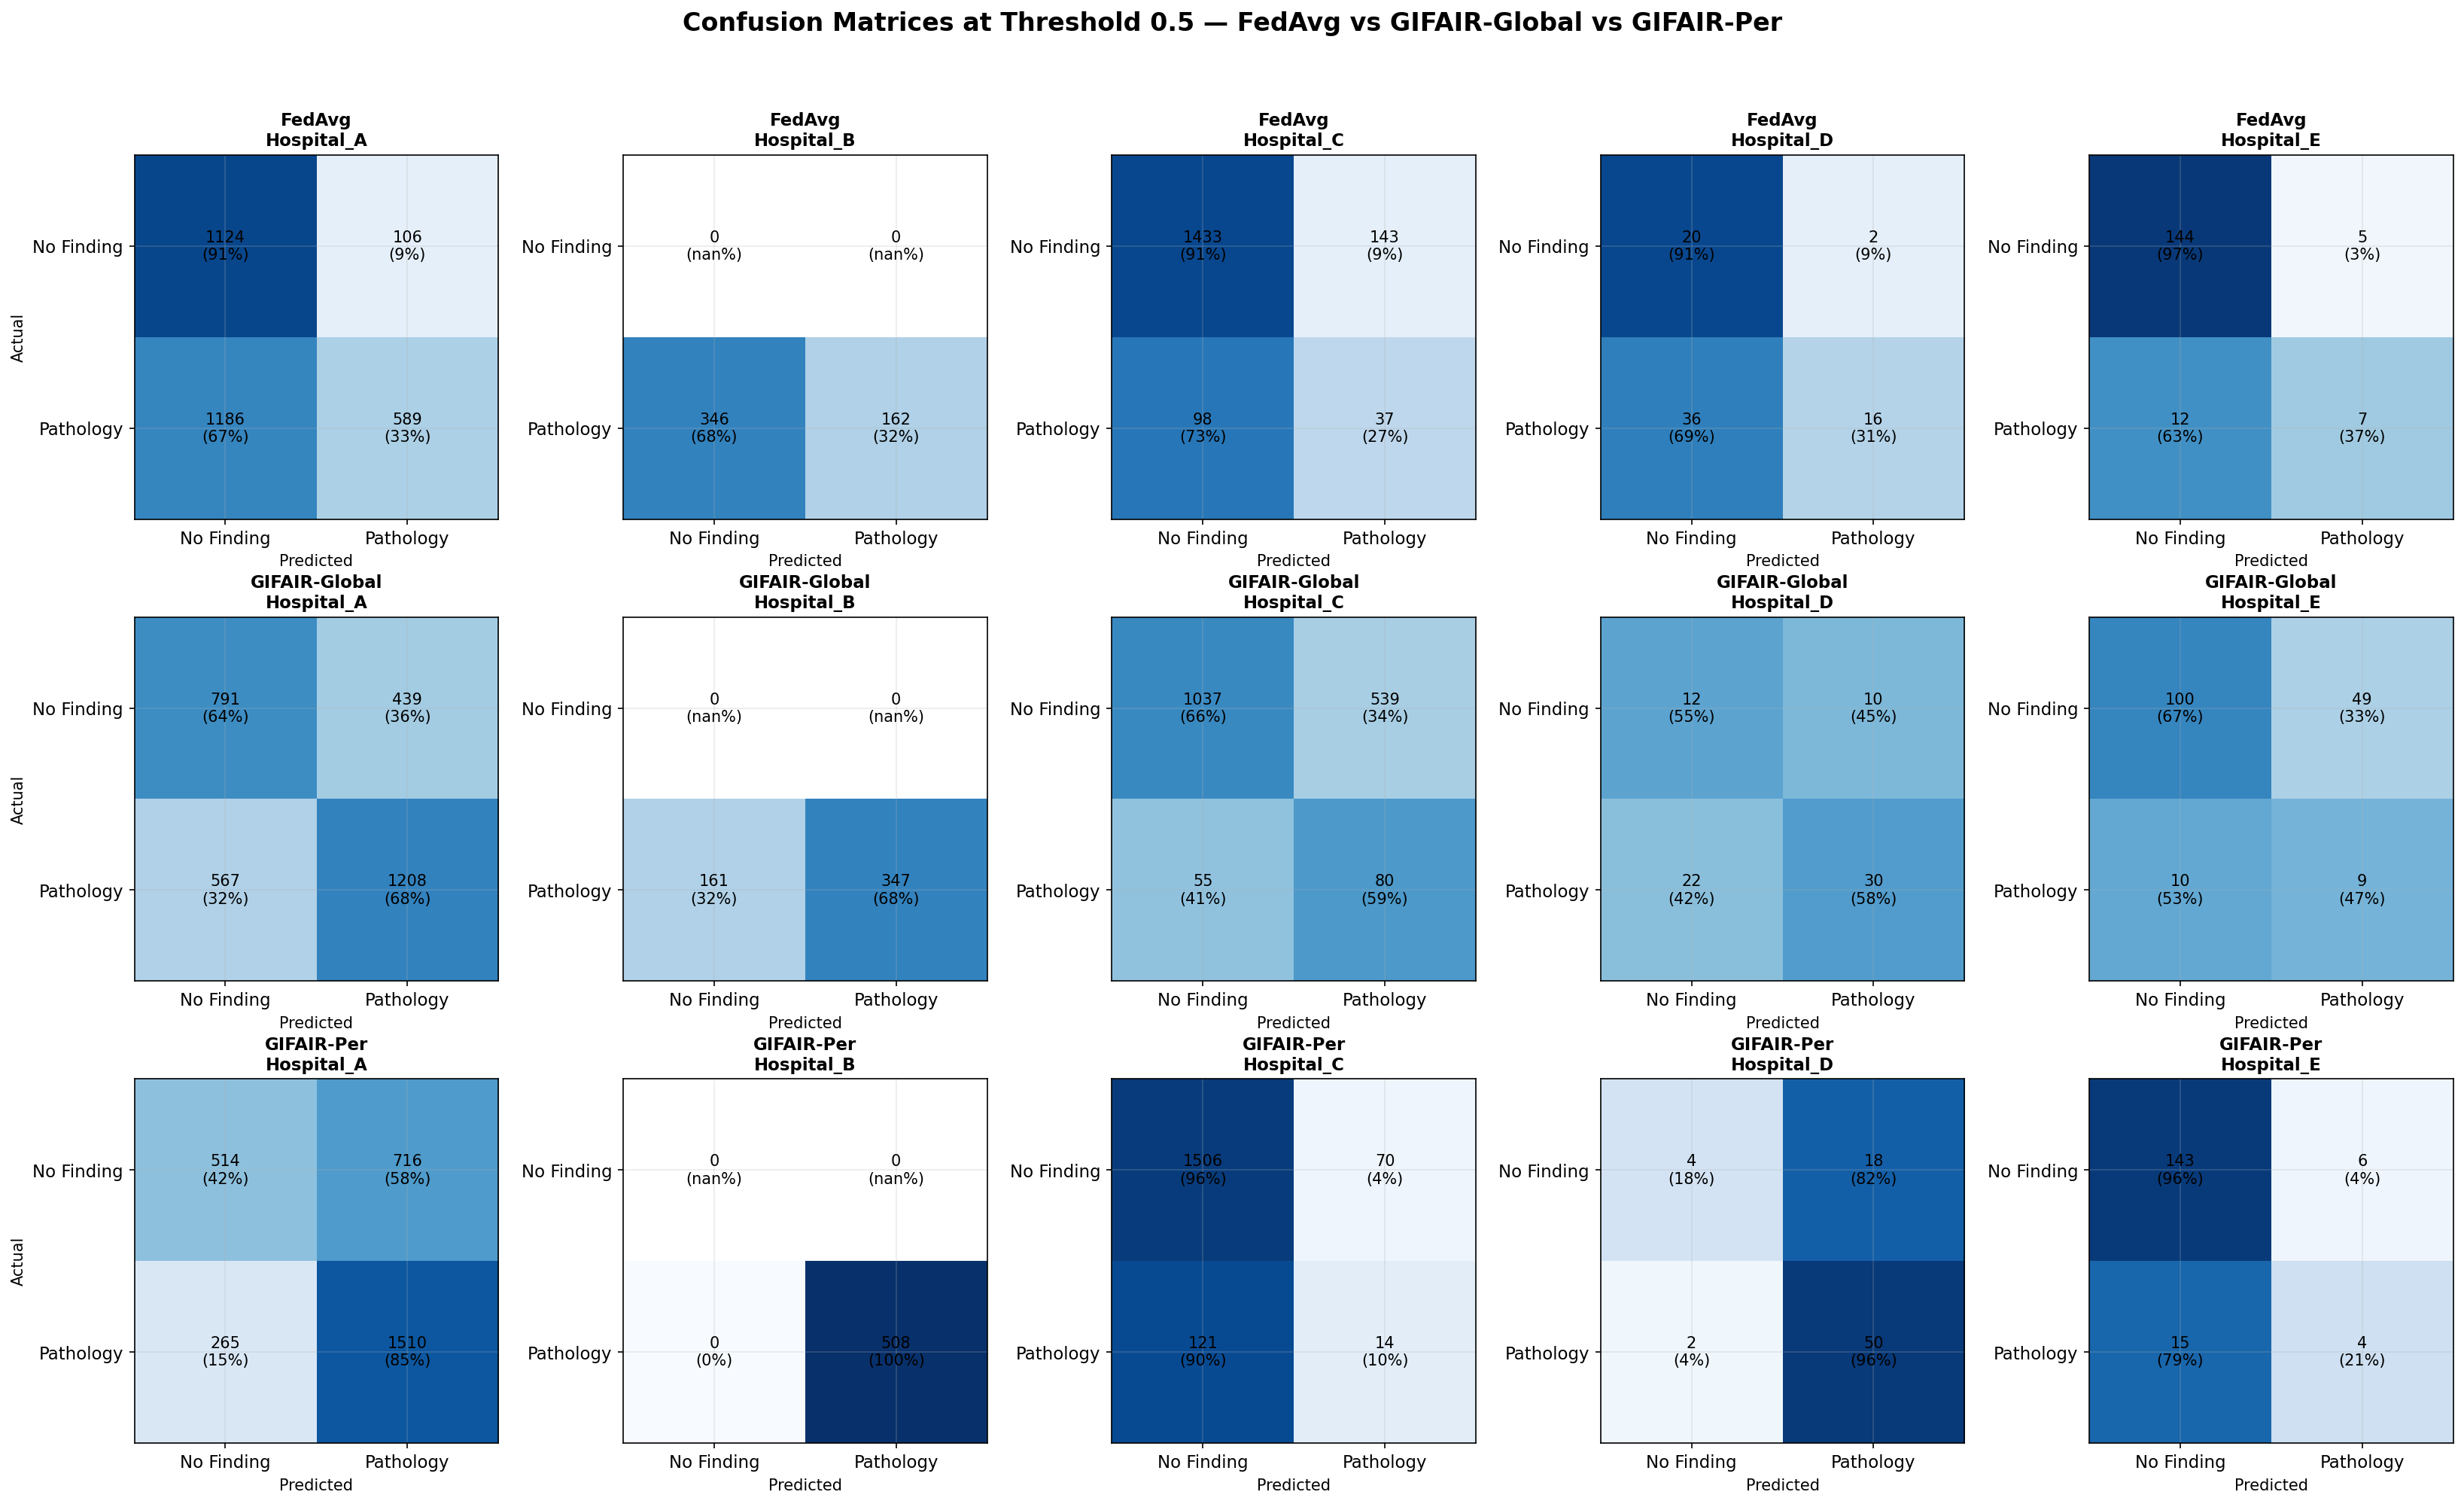

✓ Confusion matrices saved


In [ ]:
from sklearn.metrics import confusion_matrix

CM_METHODS = [m for m in METHODS if is_discriminative[m]]  # now auto-includes GIFAIR-Per
fig, axes = plt.subplots(len(CM_METHODS), 5, figsize=(22, 4.5*len(CM_METHODS)))

for row, method in enumerate(CM_METHODS):
    for col, hospital in enumerate(HOSPITAL_NAMES):
        probs, labels = all_data[method][hospital]
        preds = (probs > 0.5).astype(int)
        cm = confusion_matrix(labels, preds, labels=[0, 1])
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        ax = axes[row, col]
        ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f"{cm[i,j]}\n({cm_norm[i,j]*100:.0f}%)",
                        ha='center', va='center', fontsize=10)
        ax.set_xticks([0, 1]); ax.set_xticklabels(['No Finding', 'Pathology'])
        ax.set_yticks([0, 1]); ax.set_yticklabels(['No Finding', 'Pathology'])
        ax.set_title(f'{method}\n{hospital}', fontsize=11)
        if col == 0:
            ax.set_ylabel('Actual')
        ax.set_xlabel('Predicted')

fig.suptitle(f'Confusion Matrices at Threshold 0.5 — {" vs ".join(CM_METHODS)}', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(f'{SAVE_DIR}/confusion_matrices_fedavg_gifairglobal.png', dpi=200, bbox_inches='tight')
plt.show()
print("✓ Confusion matrices saved")

## Level 3 — Per-Sex Within Each Hospital (Demographic Fairness)
Male vs. Female AUC and FNR, per hospital, per method — plus the sex FNR gap,
one of the two demographic fairness dimensions this dissertation compares
against inter-client fairness.

In [ ]:
sex_rows = []

for method in METHODS:
    for name in HOSPITAL_NAMES:
        if name not in all_data[method]:
            continue
        probs, labels = all_data[method][name]
        data = test_clients[name]

        for sex in ['M', 'F']:
            mask = data['Patient Sex'].values == sex
            if mask.sum() > 10:
                m = compute_metrics(labels[mask], probs[mask])
                m['Method']   = method
                m['Hospital'] = name
                m['Sex']      = sex
                sex_rows.append(m)

df_sex = pd.DataFrame(sex_rows)
print("=== Level 3 — Per-Sex Performance ===\n")
print(df_sex[['Method', 'Hospital', 'Sex', 'n', 'roc_auc', 'fnr_at_0.5']].to_string(index=False))

# Sex FNR gap per method per hospital: |FNR_M - FNR_F|
print("\n=== Sex FNR Gap (|FNR_Male - FNR_Female|) at threshold 0.5 ===")
sex_gap_rows = []
for method in METHODS:
    for name in HOSPITAL_NAMES:
        sub = df_sex[(df_sex['Method'] == method) & (df_sex['Hospital'] == name)]
        if len(sub) == 2:
            fnr_m = sub[sub['Sex'] == 'M']['fnr_at_0.5'].values[0]
            fnr_f = sub[sub['Sex'] == 'F']['fnr_at_0.5'].values[0]
            if not (np.isnan(fnr_m) or np.isnan(fnr_f)):
                gap = abs(fnr_m - fnr_f)
                sex_gap_rows.append({'Method': method, 'Hospital': name, 'sex_fnr_gap': gap})

df_sex_gap = pd.DataFrame(sex_gap_rows)
mean_sex_gap = df_sex_gap.groupby('Method')['sex_fnr_gap'].mean()
print(mean_sex_gap.sort_values().to_string())

=== Level 3 — Per-Sex Performance ===

       Method   Hospital Sex    n  roc_auc  fnr_at_0.5
       FedAvg Hospital_A   M 1737   0.7687      0.6543
       FedAvg Hospital_A   F 1268   0.7366      0.6872
       FedAvg Hospital_B   M  273      NaN      0.6593
       FedAvg Hospital_B   F  235      NaN      0.7064
       FedAvg Hospital_C   M  982   0.7815      0.7000
       FedAvg Hospital_C   F  729   0.6979      0.7538
       FedAvg Hospital_D   M   43   0.8061      0.6970
       FedAvg Hospital_D   F   31   0.5789      0.6842
       FedAvg Hospital_E   M  100   0.8067      0.6000
       FedAvg Hospital_E   F   68   0.7533      0.6667
     q-FedAvg Hospital_A   M 1737   0.4642      0.2220
     q-FedAvg Hospital_A   F 1268   0.4512      0.2139
     q-FedAvg Hospital_B   M  273      NaN      0.2198
     q-FedAvg Hospital_B   F  235      NaN      0.2085
     q-FedAvg Hospital_C   M  982   0.4970      0.1571
     q-FedAvg Hospital_C   F  729   0.3858      0.2923
     q-FedAvg Hospital_D  

## Level 4 — Per-Age-Group Within Each Hospital (Demographic Fairness)
Same structure as Level 3, across the five age bands already defined in the
frozen splits (0-20, 20-40, 40-60, 60-80, 80+).

In [ ]:
age_rows = []
AGE_GROUPS = ['0-20', '20-40', '40-60', '60-80', '80+']

for method in METHODS:
    for name in HOSPITAL_NAMES:
        if name not in all_data[method]:
            continue
        probs, labels = all_data[method][name]
        data = test_clients[name]

        for grp in AGE_GROUPS:
            mask = data['Age Group'].values == grp
            if mask.sum() > 10:
                m = compute_metrics(labels[mask], probs[mask])
                m['Method']    = method
                m['Hospital']  = name
                m['AgeGroup']  = grp
                age_rows.append(m)

df_age = pd.DataFrame(age_rows)
print("=== Level 4 — Per-Age-Group Performance ===\n")
print(df_age[['Method', 'Hospital', 'AgeGroup', 'n', 'roc_auc', 'fnr_at_0.5']].to_string(index=False))

# Age FNR gap per method per hospital: max(FNR) - min(FNR) across age groups present
print("\n=== Age FNR Gap (max - min across age groups) at threshold 0.5 ===")
age_gap_rows = []
for method in METHODS:
    for name in HOSPITAL_NAMES:
        sub = df_age[(df_age['Method'] == method) & (df_age['Hospital'] == name)]
        fnrs = sub['fnr_at_0.5'].dropna().values
        if len(fnrs) >= 2:
            age_gap_rows.append({'Method': method, 'Hospital': name,
                                  'age_fnr_gap': float(fnrs.max() - fnrs.min())})

df_age_gap = pd.DataFrame(age_gap_rows)
mean_age_gap = df_age_gap.groupby('Method')['age_fnr_gap'].mean()
print(mean_age_gap.sort_values().to_string())

=== Level 4 — Per-Age-Group Performance ===

       Method   Hospital AgeGroup    n  roc_auc  fnr_at_0.5
       FedAvg Hospital_A     0-20  282   0.7410      0.6389
       FedAvg Hospital_A    20-40  744   0.8064      0.5310
       FedAvg Hospital_A    40-60 1313   0.7254      0.7467
       FedAvg Hospital_A    60-80  630   0.7392      0.6633
       FedAvg Hospital_A      80+   36   0.7389      0.8621
       FedAvg Hospital_B     0-20   27      NaN      0.7407
       FedAvg Hospital_B    20-40  118      NaN      0.5678
       FedAvg Hospital_B    40-60  223      NaN      0.6861
       FedAvg Hospital_B    60-80  131      NaN      0.7710
       FedAvg Hospital_C     0-20  117   0.8268      0.3750
       FedAvg Hospital_C    20-40  536   0.7518      0.6286
       FedAvg Hospital_C    40-60  710   0.7083      0.7869
       FedAvg Hospital_C    60-80  339   0.7395      0.8333
       FedAvg Hospital_D    20-40   17   0.6515      0.7273
       FedAvg Hospital_D    40-60   32   0.5938      0.

## Level 4.5 — Equal Opportunity Difference (EOD)

**Definition and citation:** Equal Opportunity Difference is defined in
Hardt, Price & Srebro (2016), *"Equality of Opportunity in Supervised
Learning"* (NeurIPS). Equal opportunity requires equal **true positive
rates** (TPR) across subgroups; EOD is the gap between them:
`EOD = |TPR_group1 - TPR_group2|`. Since TPR = 1 − FNR, this is computed
directly from the FNR values already calculated in Levels 3 and 4 — no new
inference needed, just a different way of expressing the same underlying
gap that fairness papers commonly report.

**Note for the results/discussion chapter — small subgroup sizes:**
Hospital_D's test set is only 74 images in total (the smallest of the five
hospitals). Once split further by sex or age group, several subgroups fall
below or close to the n=10 threshold used here, meaning their AUC/FNR/EOD
values are estimated from very few images and should be reported with that
caveat rather than treated as equally reliable as Hospital_A's (3,005 test
images). This applies to Hospital_D and, to a lesser extent, Hospital_E
(168 test images) throughout Levels 3, 4, and the intersectional analysis
below.

In [ ]:
def tpr_from_fnr(fnr):
    return 1.0 - fnr if not np.isnan(fnr) else np.nan

# EOD by sex — reuses df_sex computed in Level 3
eod_sex_rows = []
for method in METHODS:
    for name in HOSPITAL_NAMES:
        sub = df_sex[(df_sex['Method'] == method) & (df_sex['Hospital'] == name)]
        if len(sub) == 2:
            tpr_m = tpr_from_fnr(sub[sub['Sex'] == 'M']['fnr_at_0.5'].values[0])
            tpr_f = tpr_from_fnr(sub[sub['Sex'] == 'F']['fnr_at_0.5'].values[0])
            if not (np.isnan(tpr_m) or np.isnan(tpr_f)):
                eod_sex_rows.append({'Method': method, 'Hospital': name,
                                      'eod_sex': abs(tpr_m - tpr_f)})

df_eod_sex = pd.DataFrame(eod_sex_rows)
mean_eod_sex = df_eod_sex.groupby('Method')['eod_sex'].mean()

# EOD by age — reuses df_age computed in Level 4
eod_age_rows = []
for method in METHODS:
    for name in HOSPITAL_NAMES:
        sub = df_age[(df_age['Method'] == method) & (df_age['Hospital'] == name)]
        tprs = [tpr_from_fnr(f) for f in sub['fnr_at_0.5'].values]
        tprs = [t for t in tprs if not np.isnan(t)]
        if len(tprs) >= 2:
            eod_age_rows.append({'Method': method, 'Hospital': name,
                                  'eod_age': max(tprs) - min(tprs)})

df_eod_age = pd.DataFrame(eod_age_rows)
mean_eod_age = df_eod_age.groupby('Method')['eod_age'].mean()

print("=== Equal Opportunity Difference — Sex (Hardt et al. 2016) ===")
print(mean_eod_sex.sort_values().to_string())
print("\n=== Equal Opportunity Difference — Age Group (Hardt et al. 2016) ===")
print(mean_eod_age.sort_values().to_string())

=== Equal Opportunity Difference — Sex (Hardt et al. 2016) ===
Method
Ada-IFFL         0.00012
GIFAIR-Per       0.02526
FedAvg           0.04266
GIFAIR-Global    0.07546
q-FedAvg         0.12114

=== Equal Opportunity Difference — Age Group (Hardt et al. 2016) ===
Method
Ada-IFFL         0.00306
GIFAIR-Per       0.13332
q-FedAvg         0.15236
GIFAIR-Global    0.15526
FedAvg           0.40018


## Level 4.6 — Intersectional Subgroup Analysis (Sex × Age Group)

**Citation:** the concept of intersectionality originates in Crenshaw
(1989); its application to evaluating ML classifiers on combined subgroups
(rather than one demographic attribute at a time) is established by
Buolamwini & Gebru (2018), *"Gender Shades: Intersectional Accuracy
Disparities in Commercial Gender Classification"*. The same logic applies
here: a method could show a small sex gap and a small age gap separately,
while still performing very differently on, for example, older female
patients specifically — a disparity that per-attribute analysis alone
would miss.

Same n>10 threshold applies, and the small-subgroup caveat above applies
even more strongly here, since intersectional cells are smaller by
definition (e.g. "Hospital_D, Female, 60-80" may contain very few images).

In [ ]:
intersect_rows = []

for method in METHODS:
    for name in HOSPITAL_NAMES:
        probs, labels = all_data[method][name]
        data = test_clients[name]

        for sex in ['M', 'F']:
            for grp in AGE_GROUPS:
                mask = (data['Patient Sex'].values == sex) & (data['Age Group'].values == grp)
                if mask.sum() > 10:
                    m = compute_metrics(labels[mask], probs[mask])
                    m['Method']    = method
                    m['Hospital']  = name
                    m['Sex']       = sex
                    m['AgeGroup']  = grp
                    intersect_rows.append(m)

df_intersect = pd.DataFrame(intersect_rows)
print("=== Level 4.6 — Intersectional (Sex × Age) Performance ===\n")
print(df_intersect[['Method', 'Hospital', 'Sex', 'AgeGroup', 'n',
                     'roc_auc', 'fnr_at_0.5']].to_string(index=False))

# Intersectional FNR gap per method per hospital: max - min across all sex x age cells
print("\n=== Intersectional FNR Gap (max - min across Sex x Age cells) ===")
intersect_gap_rows = []
for method in METHODS:
    for name in HOSPITAL_NAMES:
        sub = df_intersect[(df_intersect['Method'] == method) & (df_intersect['Hospital'] == name)]
        fnrs = sub['fnr_at_0.5'].dropna().values
        if len(fnrs) >= 2:
            intersect_gap_rows.append({'Method': method, 'Hospital': name,
                                        'intersectional_fnr_gap': float(fnrs.max() - fnrs.min())})

df_intersect_gap = pd.DataFrame(intersect_gap_rows)
mean_intersect_gap = df_intersect_gap.groupby('Method')['intersectional_fnr_gap'].mean()
print(mean_intersect_gap.sort_values().to_string())

df_intersect.to_csv(f'{SAVE_DIR}/intersectional_subgroups_frozen_split.csv', index=False)
print("\n✓ Intersectional subgroup table saved → intersectional_subgroups_frozen_split.csv")

=== Level 4.6 — Intersectional (Sex × Age) Performance ===

       Method   Hospital Sex AgeGroup   n  roc_auc  fnr_at_0.5
       FedAvg Hospital_A   M     0-20 206   0.7379      0.6714
       FedAvg Hospital_A   M    20-40 387   0.8273      0.5176
       FedAvg Hospital_A   M    40-60 692   0.7419      0.7270
       FedAvg Hospital_A   M    60-80 427   0.7323      0.6331
       FedAvg Hospital_A   M      80+  25   0.7857      0.7778
       FedAvg Hospital_A   F     0-20  76   0.7708      0.5250
       FedAvg Hospital_A   F    20-40 357   0.7787      0.5430
       FedAvg Hospital_A   F    40-60 621   0.7083      0.7680
       FedAvg Hospital_A   F    60-80 203   0.7396      0.7368
       FedAvg Hospital_A   F      80+  11      NaN      1.0000
       FedAvg Hospital_B   M     0-20  13      NaN      0.6923
       FedAvg Hospital_B   M    20-40  57      NaN      0.5263
       FedAvg Hospital_B   M    40-60 113      NaN      0.6726
       FedAvg Hospital_B   M    60-80  81      NaN      0.

In [ ]:
df_hospital_out = df_hospital[['Method', 'Hospital', 'n', 'prevalence', 'roc_auc',
                                'avg_precision', 'fnr_at_0.3', 'fnr_at_0.5',
                                'fnr_at_0.7', 'accuracy']]
df_hospital_out.to_csv(f'{SAVE_DIR}/summary_all_methods_frozen_split.csv', index=False)
print("✓ Per-hospital summary saved → summary_all_methods_frozen_split.csv")

df_global.to_csv(f'{SAVE_DIR}/summary_global_all_methods_frozen_split.csv')
print("✓ Global summary saved → summary_global_all_methods_frozen_split.csv")

✓ Per-hospital summary saved → summary_all_methods_frozen_split.csv
✓ Global summary saved → summary_global_all_methods_frozen_split.csv


## Level 5b — ROC Curves (per hospital, all methods overlaid)

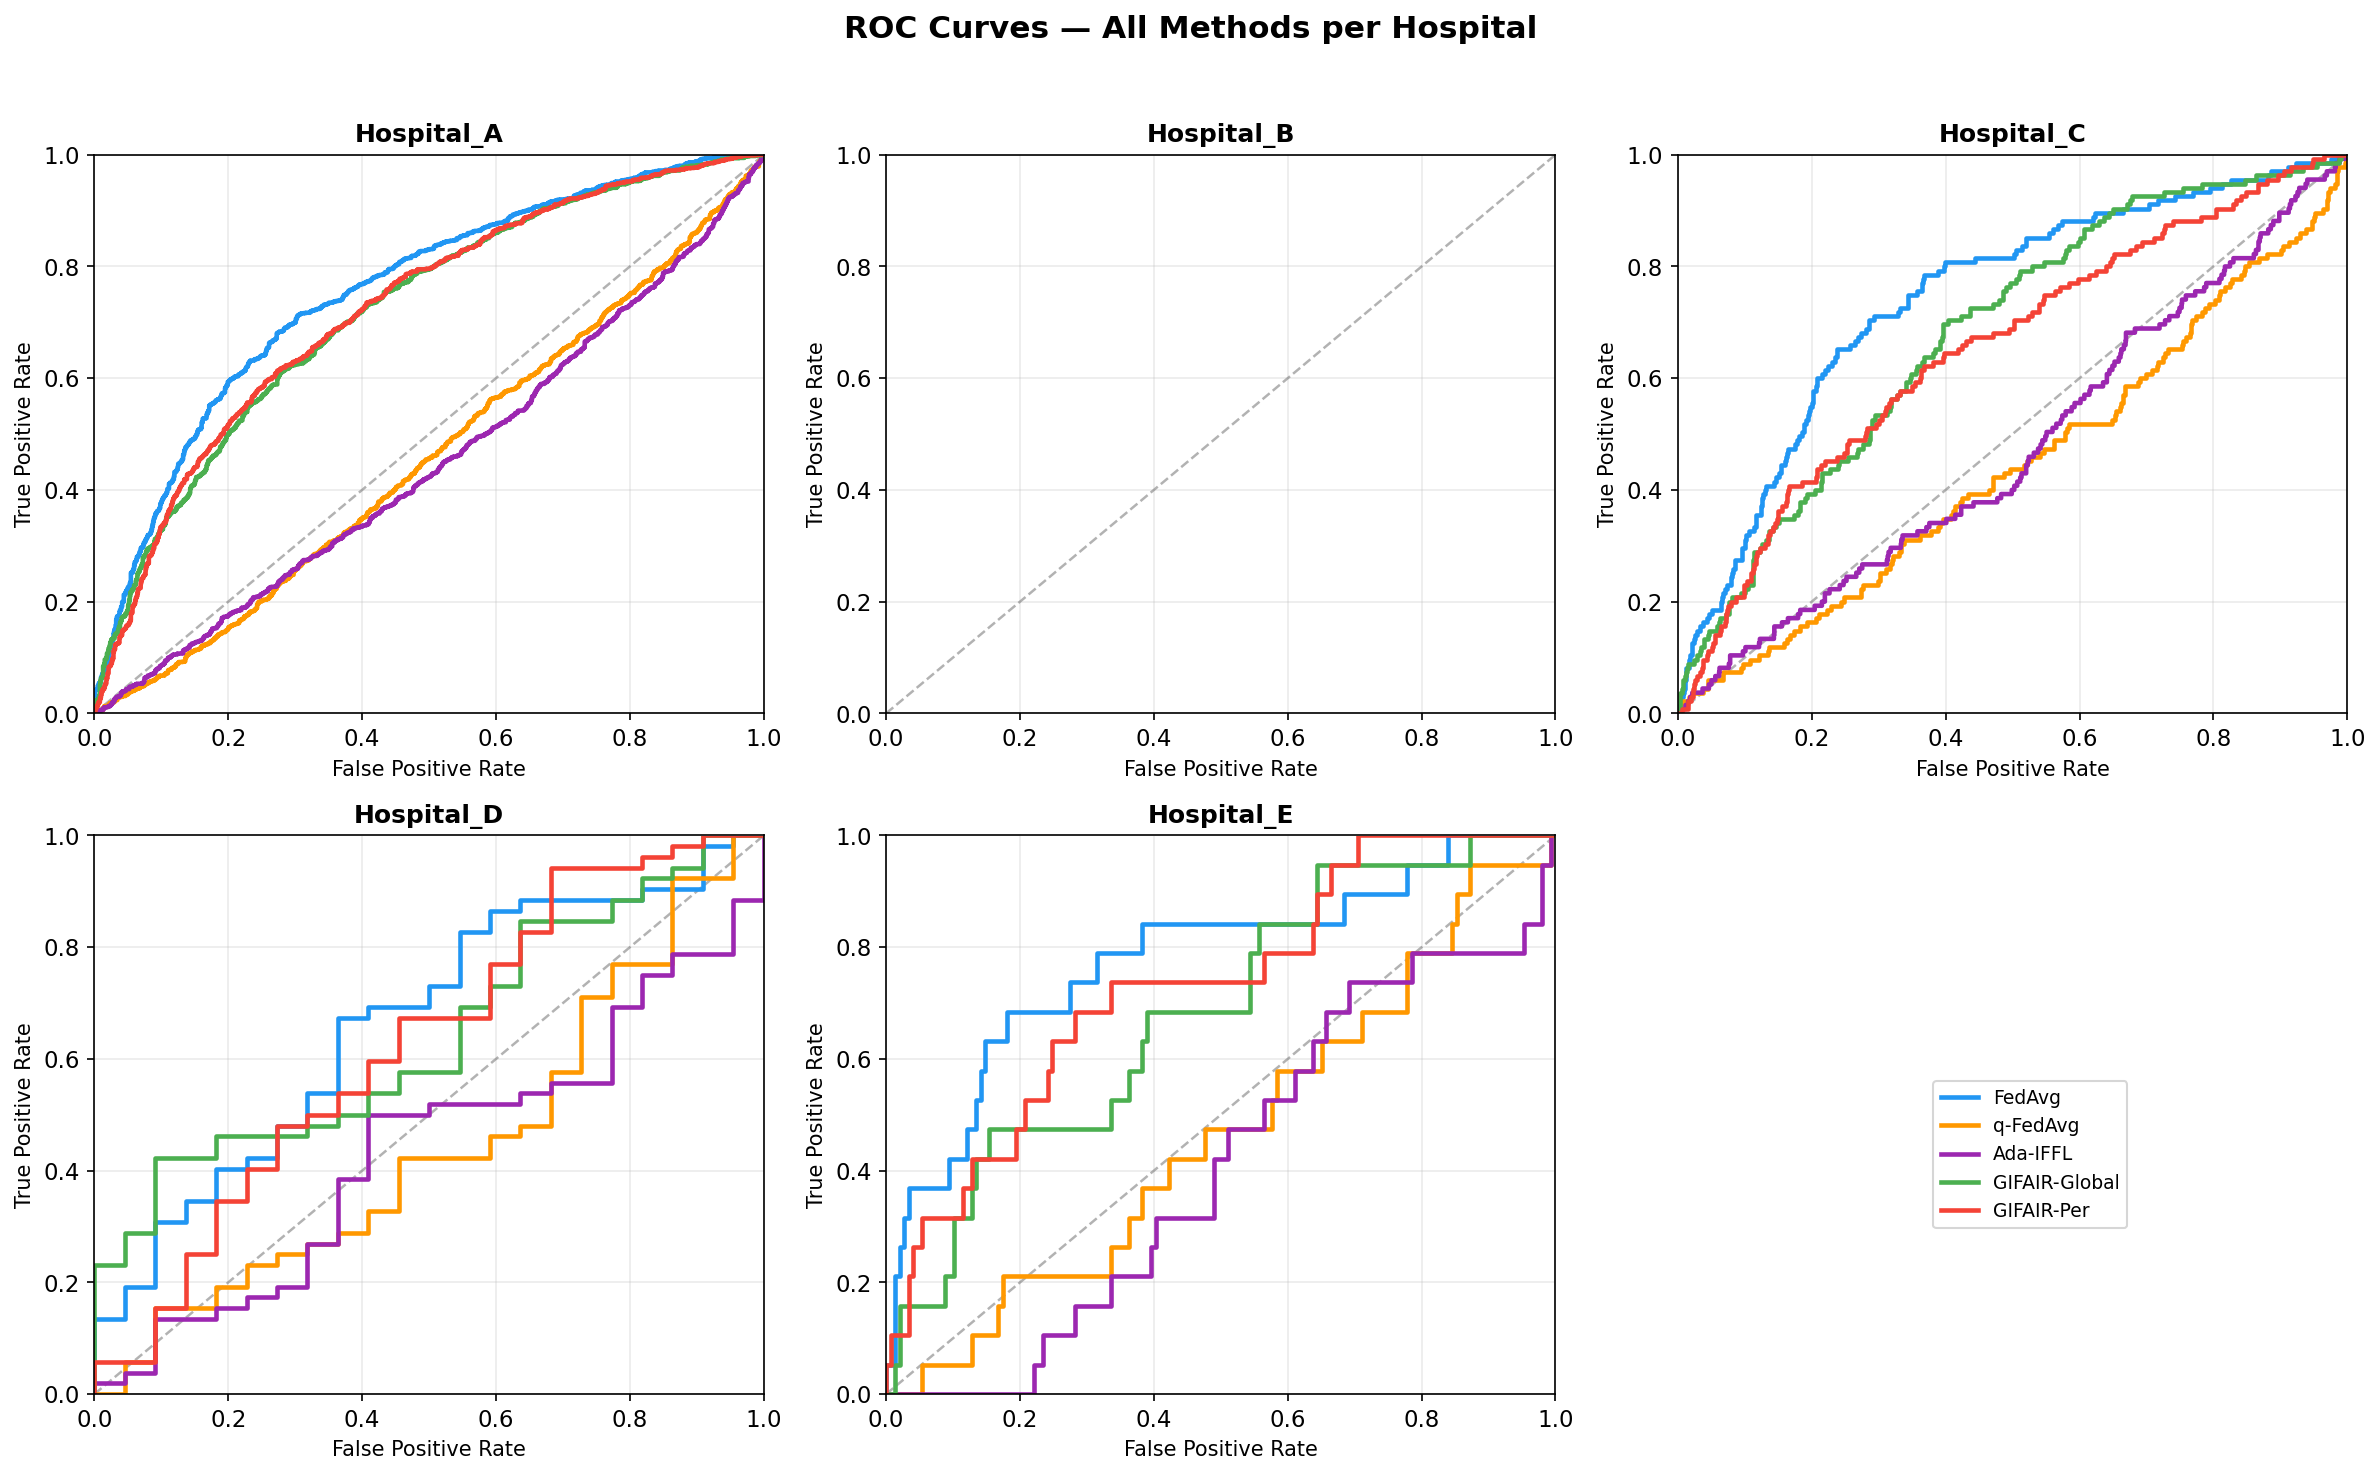

✓ ROC curves saved


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
legend_handles = {}

for idx, hospital in enumerate(HOSPITAL_NAMES):
    ax = axes[idx]
    ax.plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1.2, alpha=0.6)

    for method in METHODS:
        probs, labels = all_data[method][hospital]
        if labels.sum() == 0 or labels.sum() == len(labels):
            continue
        fpr, tpr, _ = roc_curve(labels, probs)
        auc_score = roc_auc_score(labels, probs)
        line, = ax.plot(fpr, tpr, color=COLOURS[method])
        legend_handles[f'{method}'] = line

    ax.set_title(f'{hospital}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1])

axes[-1].axis('off')
fig.legend(legend_handles.values(), legend_handles.keys(),
           loc='center', bbox_to_anchor=(0.85, 0.22), ncol=1, frameon=True)
fig.suptitle('ROC Curves — All Methods per Hospital', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f'{SAVE_DIR}/roc_curves_frozen_split.png', bbox_inches='tight', dpi=200)
plt.show()
print("✓ ROC curves saved")

## Level 5c — Precision-Recall Curves

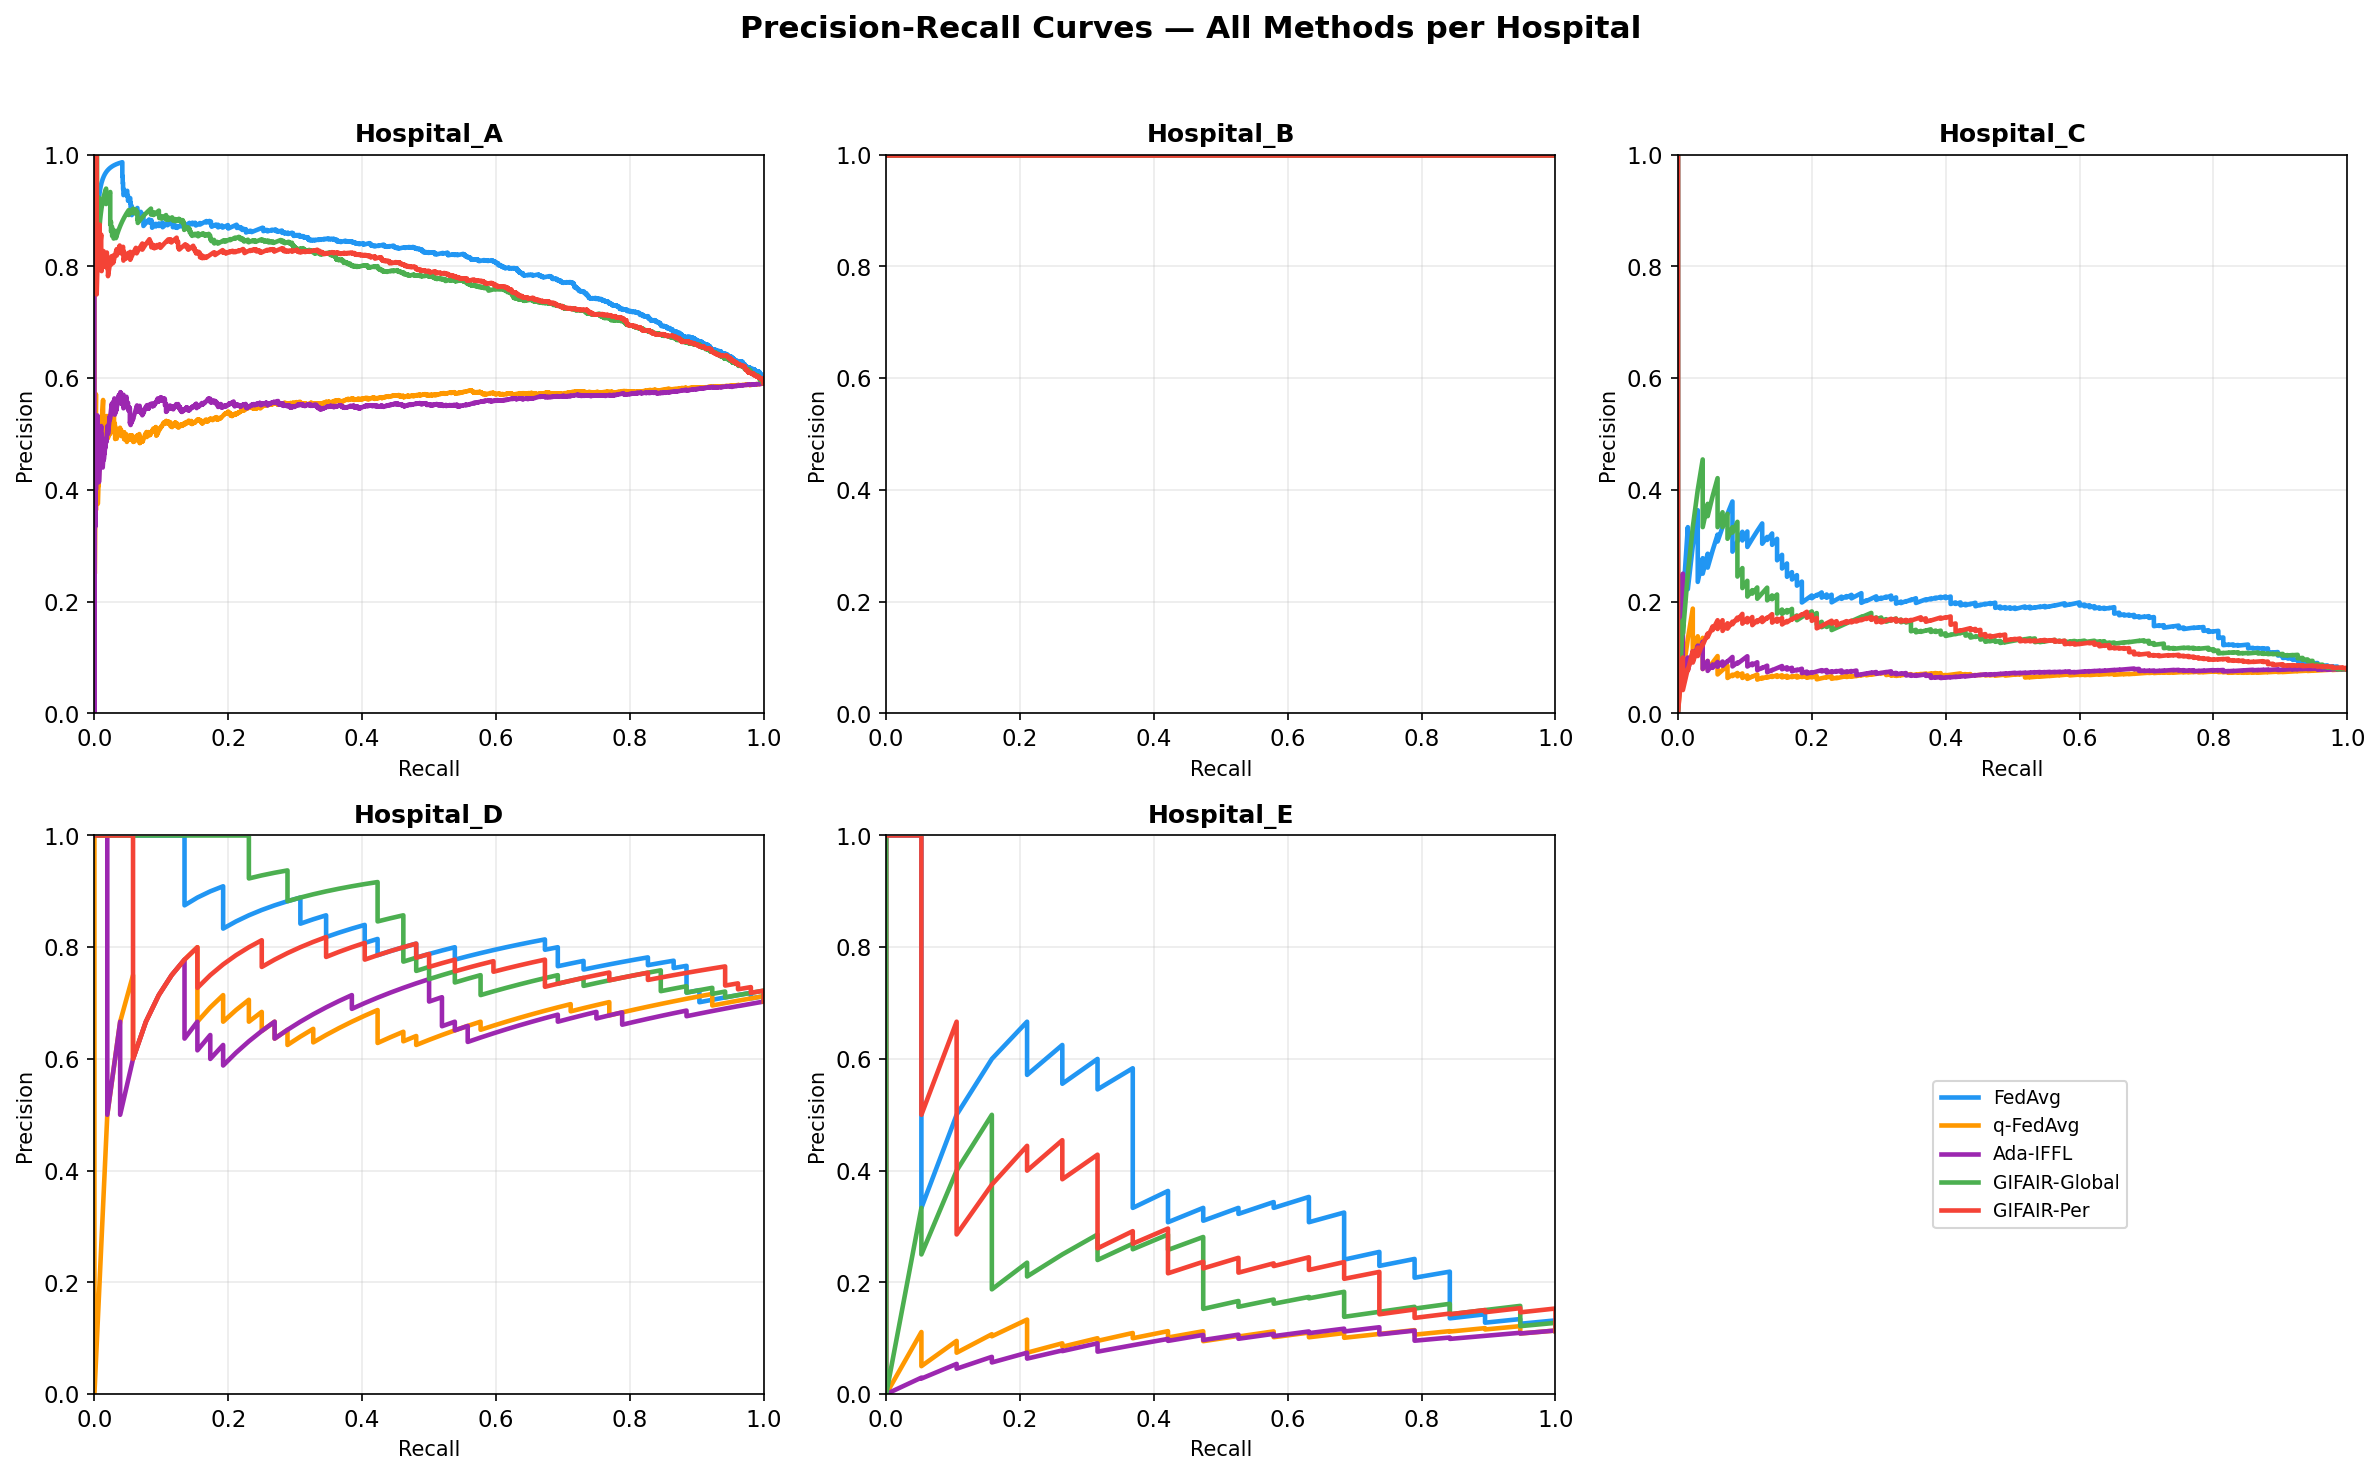

✓ PR curves saved


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
legend_handles = {}

for idx, hospital in enumerate(HOSPITAL_NAMES):
    ax = axes[idx]
    for method in METHODS:
        probs, labels = all_data[method][hospital]
        if labels.sum() == 0:
            continue
        precision, recall, _ = precision_recall_curve(labels, probs)
        line, = ax.plot(recall, precision, color=COLOURS[method])
        legend_handles[f'{method}'] = line

    ax.set_title(f'{hospital}')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1])

axes[-1].axis('off')
fig.legend(legend_handles.values(), legend_handles.keys(),
           loc='center', bbox_to_anchor=(0.85, 0.22), ncol=1, frameon=True)
fig.suptitle('Precision-Recall Curves — All Methods per Hospital', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f'{SAVE_DIR}/pr_curves_frozen_split.png', bbox_inches='tight', dpi=200)
plt.show()
print("✓ PR curves saved")

## Level 5d — Accuracy and FNR Across Decision Thresholds (0.1 to 0.7)
Two figures, same x-axis range you specified: threshold from 0.1 to 0.7 on
the x-axis, one metric on the y-axis per figure (accuracy, then FNR), one
subplot per hospital, all five methods overlaid as lines. Using a fine step
(0.02) makes the real trend render as a smooth curve rather than a jagged
line — no smoothing or alteration of the underlying numbers, just enough
threshold points to see the shape clearly.

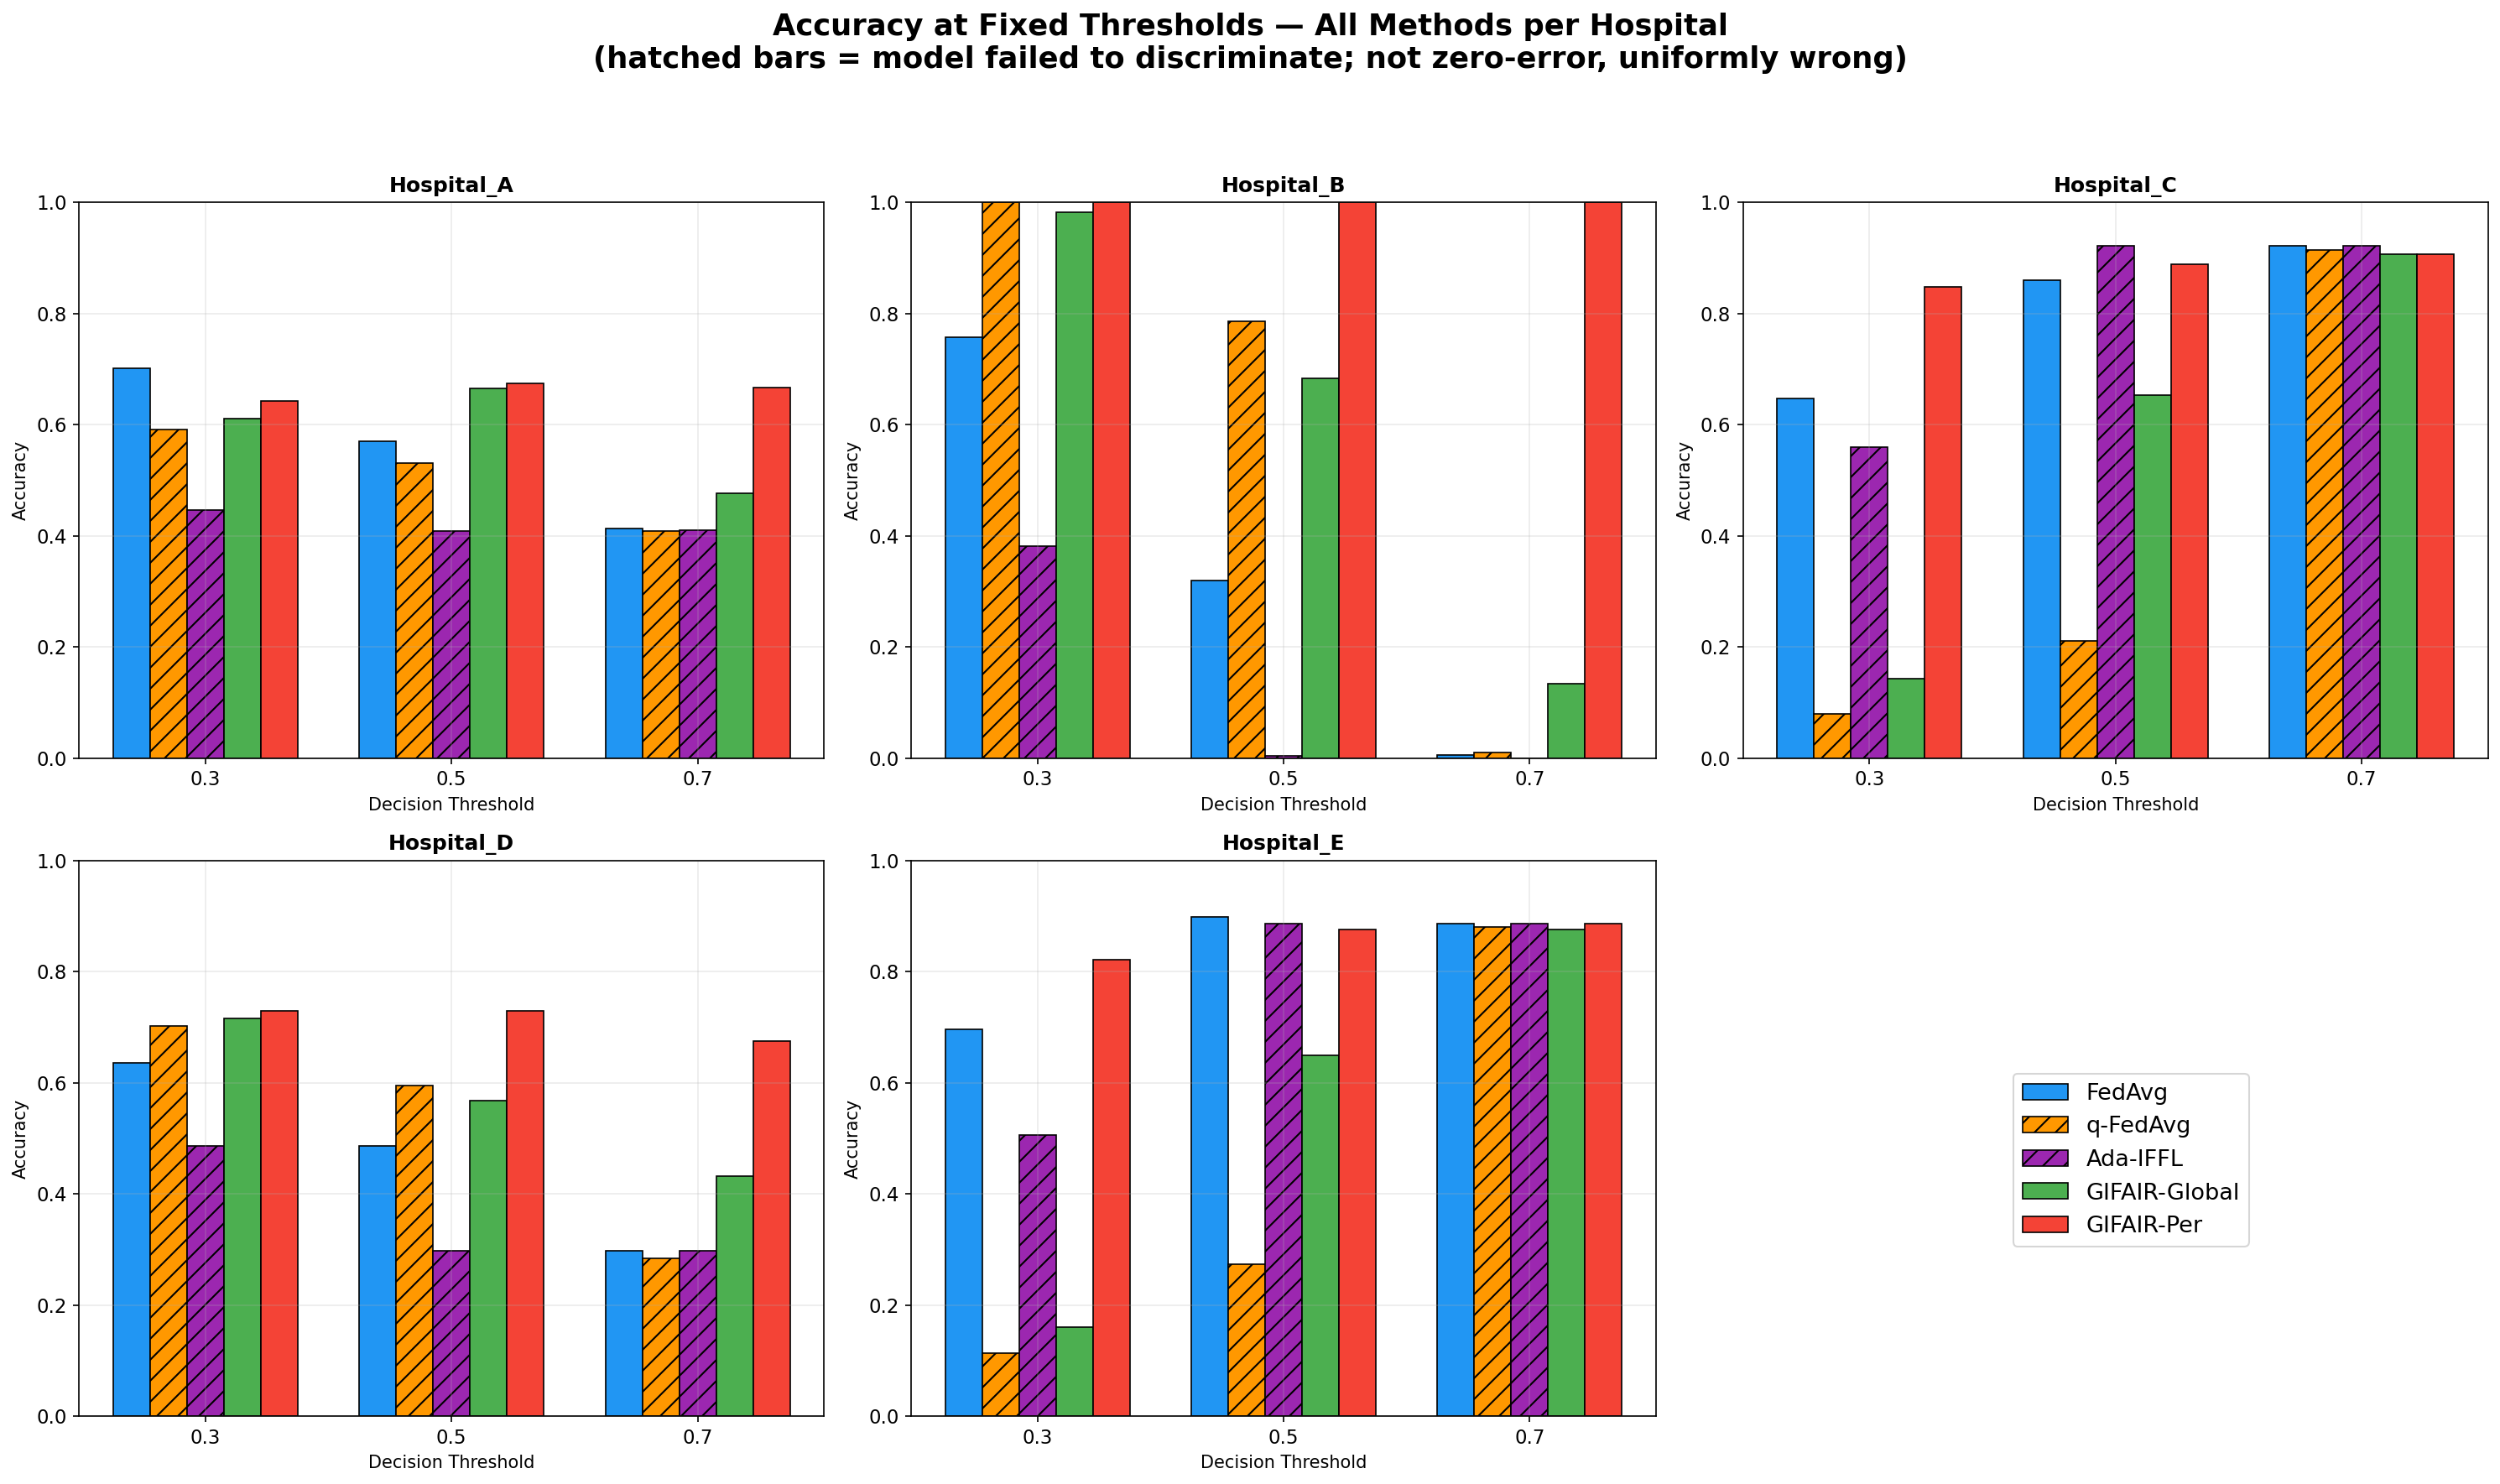

✓ Accuracy bar chart saved


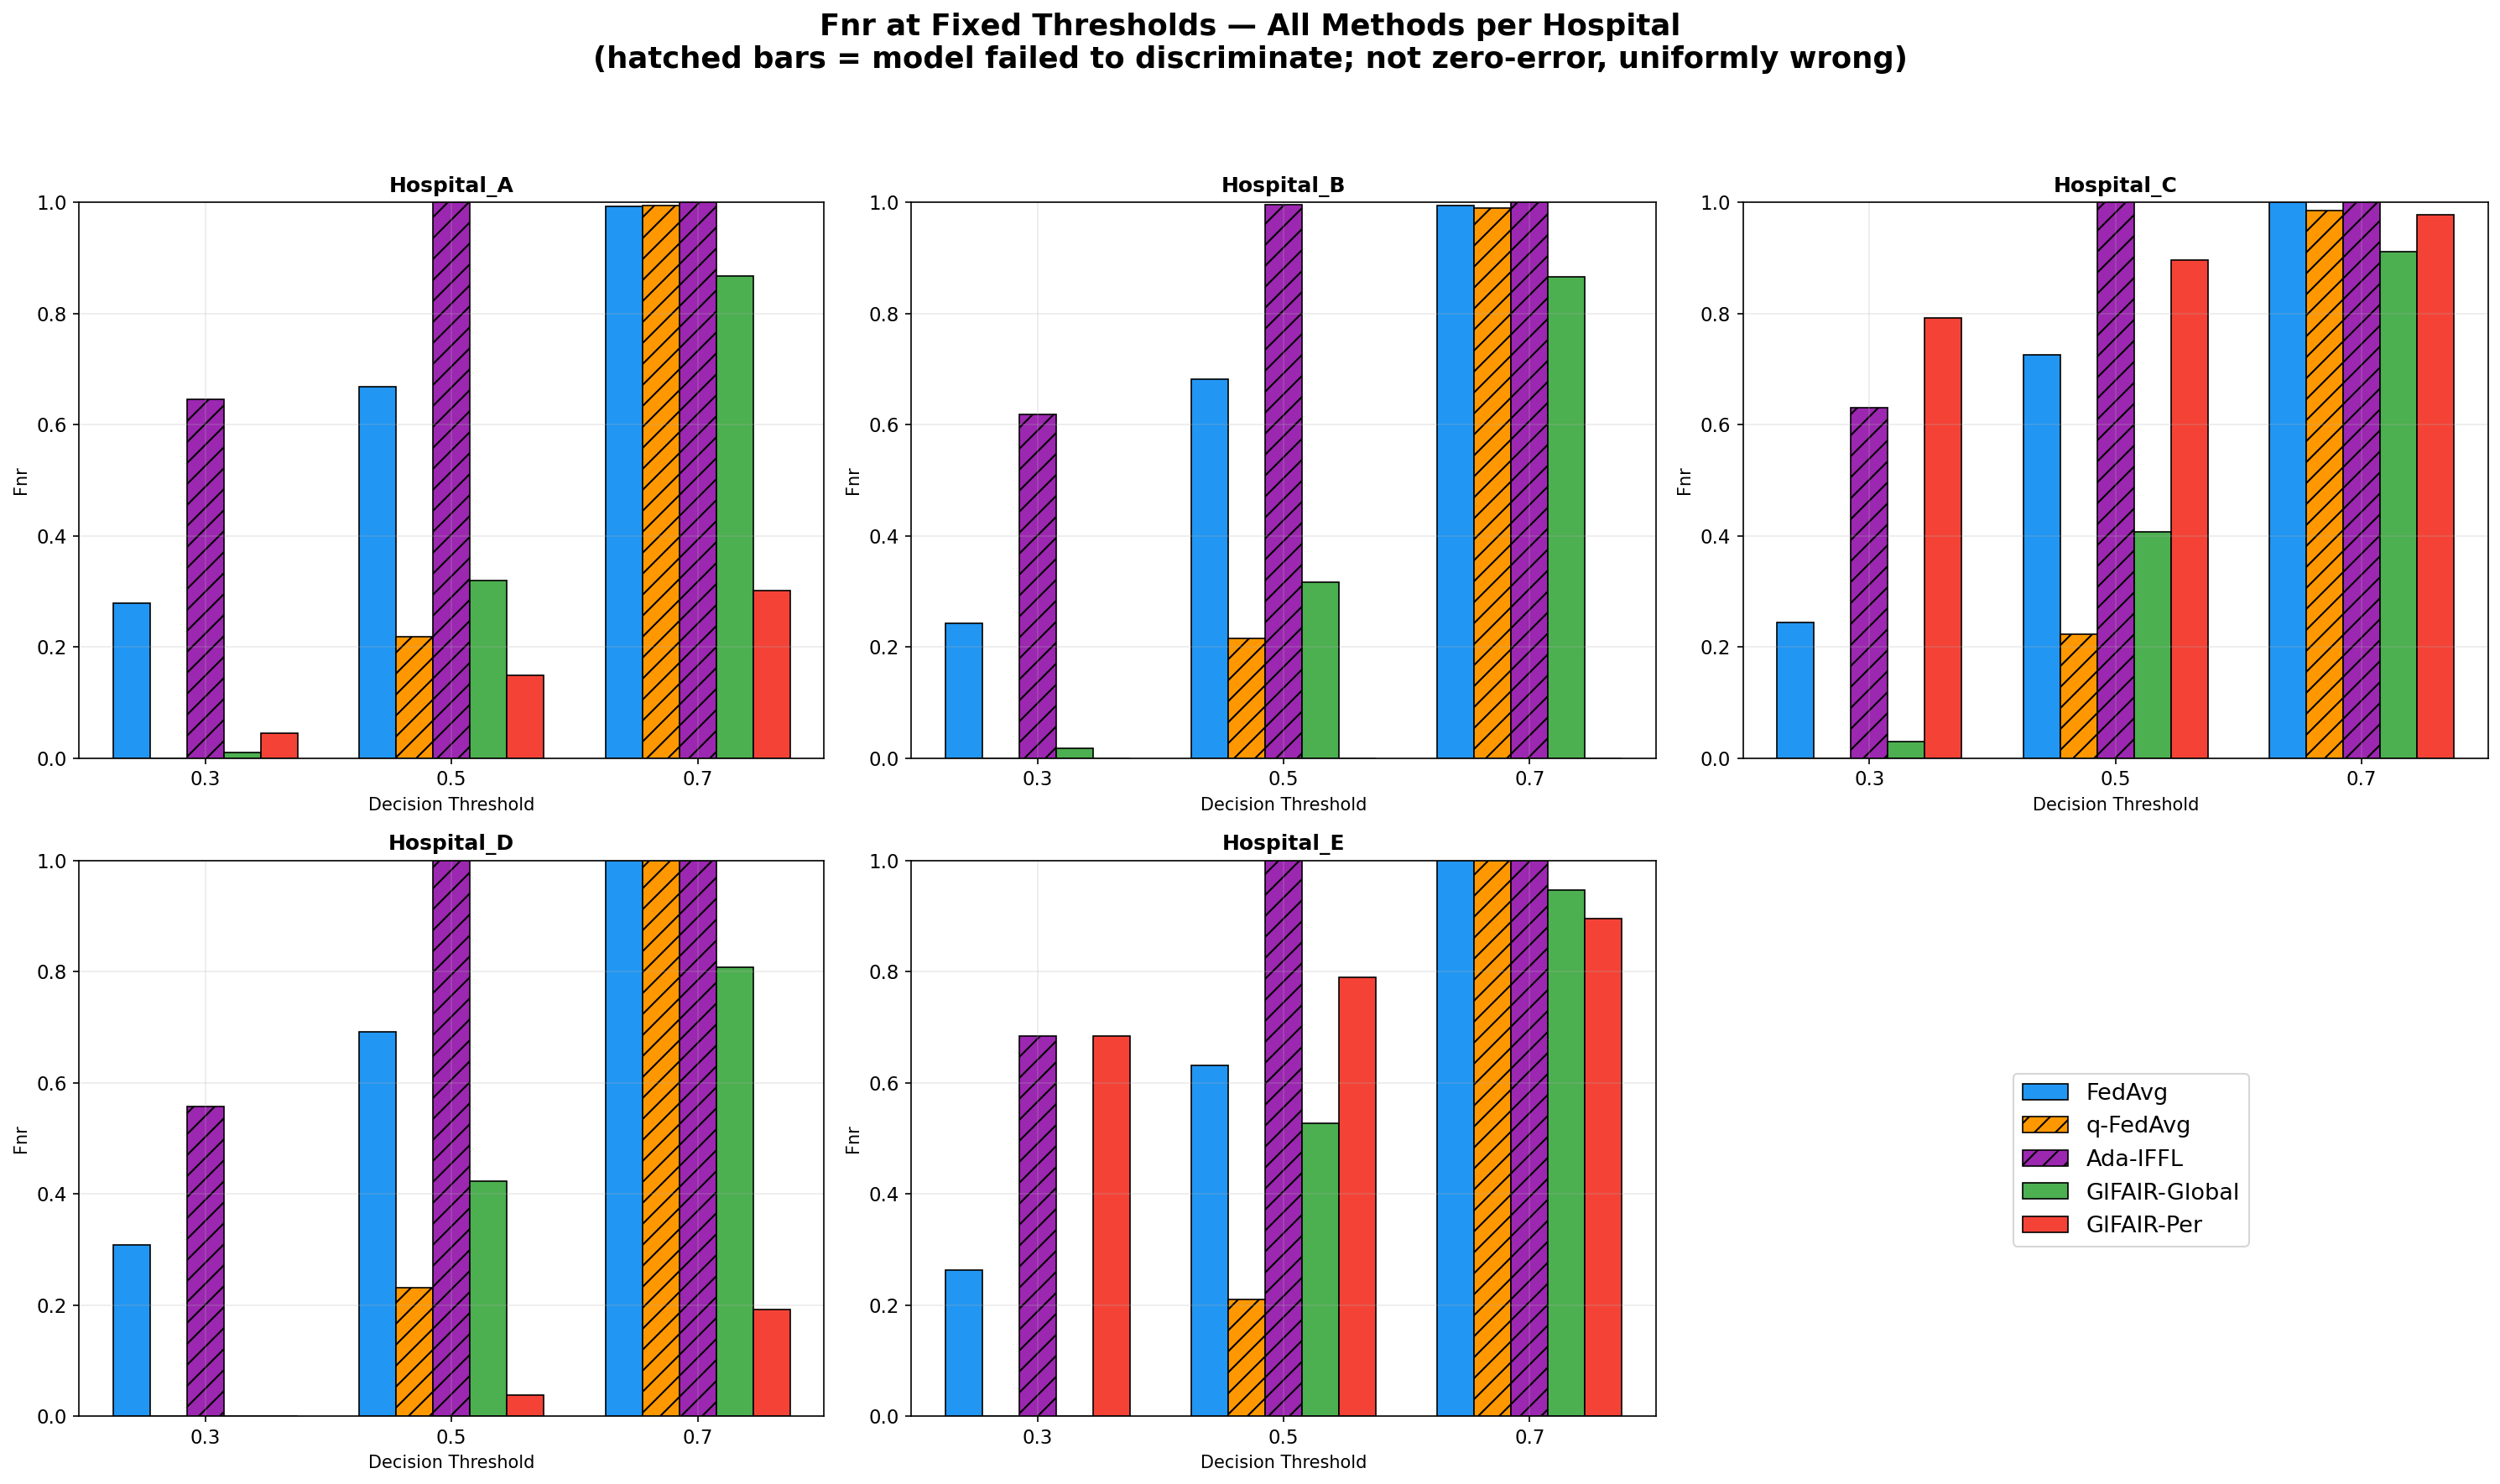

✓ FNR bar chart saved


In [ ]:
FIXED_T = [0.3, 0.5, 0.7]

def bars_at_thresholds(metric):
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()
    x = np.arange(len(FIXED_T))
    width = 0.15

    for idx, hospital in enumerate(HOSPITAL_NAMES):
        ax = axes[idx]
        for i, method in enumerate(METHODS):
            probs, labels = all_data[method][hospital]
            values = []
            for t in FIXED_T:
                preds = (probs > t).astype(int)
                if metric == 'accuracy':
                    values.append(float((preds == labels).mean()))
                else:
                    fn = int(((preds == 0) & (labels == 1)).sum())
                    tp = int(((preds == 1) & (labels == 1)).sum())
                    values.append(fn / (fn + tp) if (fn + tp) > 0 else np.nan)
            hatch = '' if is_discriminative[method] else '//'
            ax.bar(x + i*width, values, width, label=method,
                   color=COLOURS[method], hatch=hatch, edgecolor='black', linewidth=0.8)

        ax.set_xticks(x + width*2)
        ax.set_xticklabels([f'{t}' for t in FIXED_T])
        ax.set_title(hospital)
        ax.set_xlabel('Decision Threshold')
        ax.set_ylabel(metric.capitalize())
        ax.set_ylim([0, 1])

    axes[-1].axis('off')
    handles, labels_ = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc='center', bbox_to_anchor=(0.85, 0.22), fontsize=13)
    fig.suptitle(f'{metric.capitalize()} at Fixed Thresholds — All Methods per Hospital\n'
             '(hatched bars = model failed to discriminate; not zero-error, uniformly wrong)',
             fontsize=17, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.savefig(f'{SAVE_DIR}/{metric}_bars_frozen_split.png', dpi=200, bbox_inches='tight')
    plt.show()

bars_at_thresholds('accuracy')
print("✓ Accuracy bar chart saved")
bars_at_thresholds('fnr')
print("✓ FNR bar chart saved")

## Level 5e — Final Ranking: Which Aggregation Strategy Performs Best

No method is treated as a default. Each of the five is scored on the same
criteria:
- **Inter-client fairness**: lower AUC variance across the five hospitals is better
- **Demographic fairness**: lower mean FNR gap (sex + age, averaged) is better
- **Equal Opportunity Difference** (Hardt et al. 2016): lower is better, sex and age
- **Intersectional fairness** (Buolamwini & Gebru 2018): lower intersectional FNR gap is better

The point of this table is to let the numbers say which method wins on which
criterion — not to declare one method the reference point that others are
judged against.

In [ ]:
## Level 5e — Final Ranking: Which Aggregation Strategy Performs Best

ranking_rows = []
for method in METHODS:
    row = {'Method': method}
    row['is_discriminative'] = is_discriminative[method]
    row['global_roc_auc'] = df_global.loc[method, 'roc_auc'] if method in df_global.index else float('nan')
    row['inter_client_auc_variance'] = inter_client_variance.get(method, float('nan'))
    row['mean_sex_fnr_gap'] = mean_sex_gap.get(method, float('nan'))
    row['mean_age_fnr_gap'] = mean_age_gap.get(method, float('nan'))
    row['mean_demographic_fnr_gap'] = np.nanmean([row['mean_sex_fnr_gap'], row['mean_age_fnr_gap']])
    row['eod_sex'] = mean_eod_sex.get(method, float('nan'))
    row['eod_age'] = mean_eod_age.get(method, float('nan'))
    row['intersectional_fnr_gap'] = mean_intersect_gap.get(method, float('nan'))
    #row['sex_auc_gap'] = abs(sex_auc.loc[method]['M'] - sex_auc.loc[method]['F']) if method in sex_auc.index.get_level_values(0) else float('nan')
    row['accuracy'] = df_global.loc[method, 'accuracy'] if method in df_global.index else float('nan')
    ranking_rows.append(row)

df_ranking = pd.DataFrame(ranking_rows).set_index('Method')
df_ranking = df_ranking[['is_discriminative', 'global_roc_auc', 'inter_client_auc_variance',
                          'mean_sex_fnr_gap', 'mean_age_fnr_gap', 'mean_demographic_fnr_gap',
                          'eod_sex', 'eod_age', 'intersectional_fnr_gap','accuracy']]#'sex_auc_gap'

print("=== Final Comparison — All Five Methods, Same Criteria ===\n")
print(df_ranking.to_string())

methods_list = list(METHODS.keys())
valid = df_ranking[df_ranking['is_discriminative']]
excluded = df_ranking[~df_ranking['is_discriminative']]

if len(excluded) > 0:
    print(f"\n⚠ Excluded from 'best' (did not learn a working classifier): {', '.join(excluded.index)}")

best_inter_client = valid['inter_client_auc_variance'].idxmin()
best_demographic  = valid['mean_demographic_fnr_gap'].idxmin()
best_intersectional = valid['intersectional_fnr_gap'].idxmin()
best_eod_sex = valid['eod_sex'].idxmin()
best_eod_age = valid['eod_age'].idxmin()


print(f"\nBest inter-client fairness  : {best_inter_client}")
print(f"Best demographic fairness   : {best_demographic}")
print(f"Best intersectional fairness: {best_intersectional}")
print(f"Best EOD (sex)              : {best_eod_sex}")
print(f"Best EOD (age)              : {best_eod_age}")

df_ranking.to_csv(f'{SAVE_DIR}/final_ranking_frozen_split.csv')
print("\n✓ Final ranking saved")

=== Final Comparison — All Five Methods, Same Criteria ===

               is_discriminative  global_roc_auc  inter_client_auc_variance  mean_sex_fnr_gap  mean_age_fnr_gap  mean_demographic_fnr_gap  eod_sex  eod_age  intersectional_fnr_gap  accuracy
Method                                                                                                                                                                                       
FedAvg                      True          0.7556                   0.001802           0.04266           0.40018                   0.22142  0.04266  0.40018                 0.54330     64.62
q-FedAvg                   False          0.4574                   0.000082           0.12114           0.15236                   0.13675  0.12114  0.15236                 0.30664     44.68
Ada-IFFL                   False          0.4538                   0.000540           0.00012           0.00306                   0.00159  0.00012  0.00306                 0.00400 

In [ ]:
print("\n=== SUMMARY ===\n")
n_converged = len(valid)
lines = [f"{'Method':<15}{'Works?':<10}{'AUC':<8}{'Fairness gap':<14}Takeaway", "-"*100]
for method in methods_list:
    auc = df_ranking.loc[method, 'global_roc_auc']
    gap = df_ranking.loc[method, 'mean_demographic_fnr_gap']
    works = 'Yes' if is_discriminative[method] else 'No'
    if not is_discriminative[method]:
        pr = df_global.loc[method, 'predicted_positive_rate']
        takeaway = (f'Predicted "healthy" almost always ({pr:.1f}% positive) — did not learn'
                    if pr < 10 else
                    f'Predicted "pathology" almost always ({pr:.1f}% positive) — did not learn'
                    if pr > 90 else 'Ranking ability at/below random chance — did not train successfully')
    elif method == best_demographic and method == best_inter_client and method == best_intersectional:
        takeaway = f'Best overall among the {n_converged} methods that converged in this study'
    elif method == best_demographic and method == best_intersectional:
        takeaway = f'Leads on demographic and intersectional fairness among the {n_converged} methods that converged'
    elif method == best_demographic:
        takeaway = f'Most consistent across sex/age groups among the {n_converged} methods that converged'
    elif method == best_inter_client:
        takeaway = f'Most consistent across hospitals among the {n_converged} methods that converged'
    elif method == best_intersectional:
        takeaway = f'Leads on intersectional subgroup fairness among the {n_converged} methods that converged'
    else:
        takeaway = f'One of {n_converged} methods that converged to a working classifier; highest AUC in this study, though not the lowest fairness gap here'
    lines.append(f"{method:<15}{works:<10}{auc:<8.3f}{gap:<14.4f}{takeaway}")

summary = '\n'.join(lines)
print(summary)
with open(f'{SAVE_DIR}/plain_language_summary.txt', 'w') as f:
    f.write(summary)
print("\n✓ Saved → plain_language_summary.txt")


=== SUMMARY ===

Method         Works?    AUC     Fairness gap  Takeaway
----------------------------------------------------------------------------------------------------
FedAvg         Yes       0.756   0.2214        One of 3 methods that converged to a working classifier; highest AUC in this study, though not the lowest fairness gap here
q-FedAvg       No        0.457   0.1367        Ranking ability at/below random chance — did not train successfully
Ada-IFFL       No        0.454   0.0016        Predicted "healthy" almost always (0.1% positive) — did not learn
GIFAIR-Global  Yes       0.724   0.1154        Most consistent across hospitals among the 3 methods that converged
GIFAIR-Per     Yes       0.869   0.0793        Leads on demographic and intersectional fairness among the 3 methods that converged

✓ Saved → plain_language_summary.txt


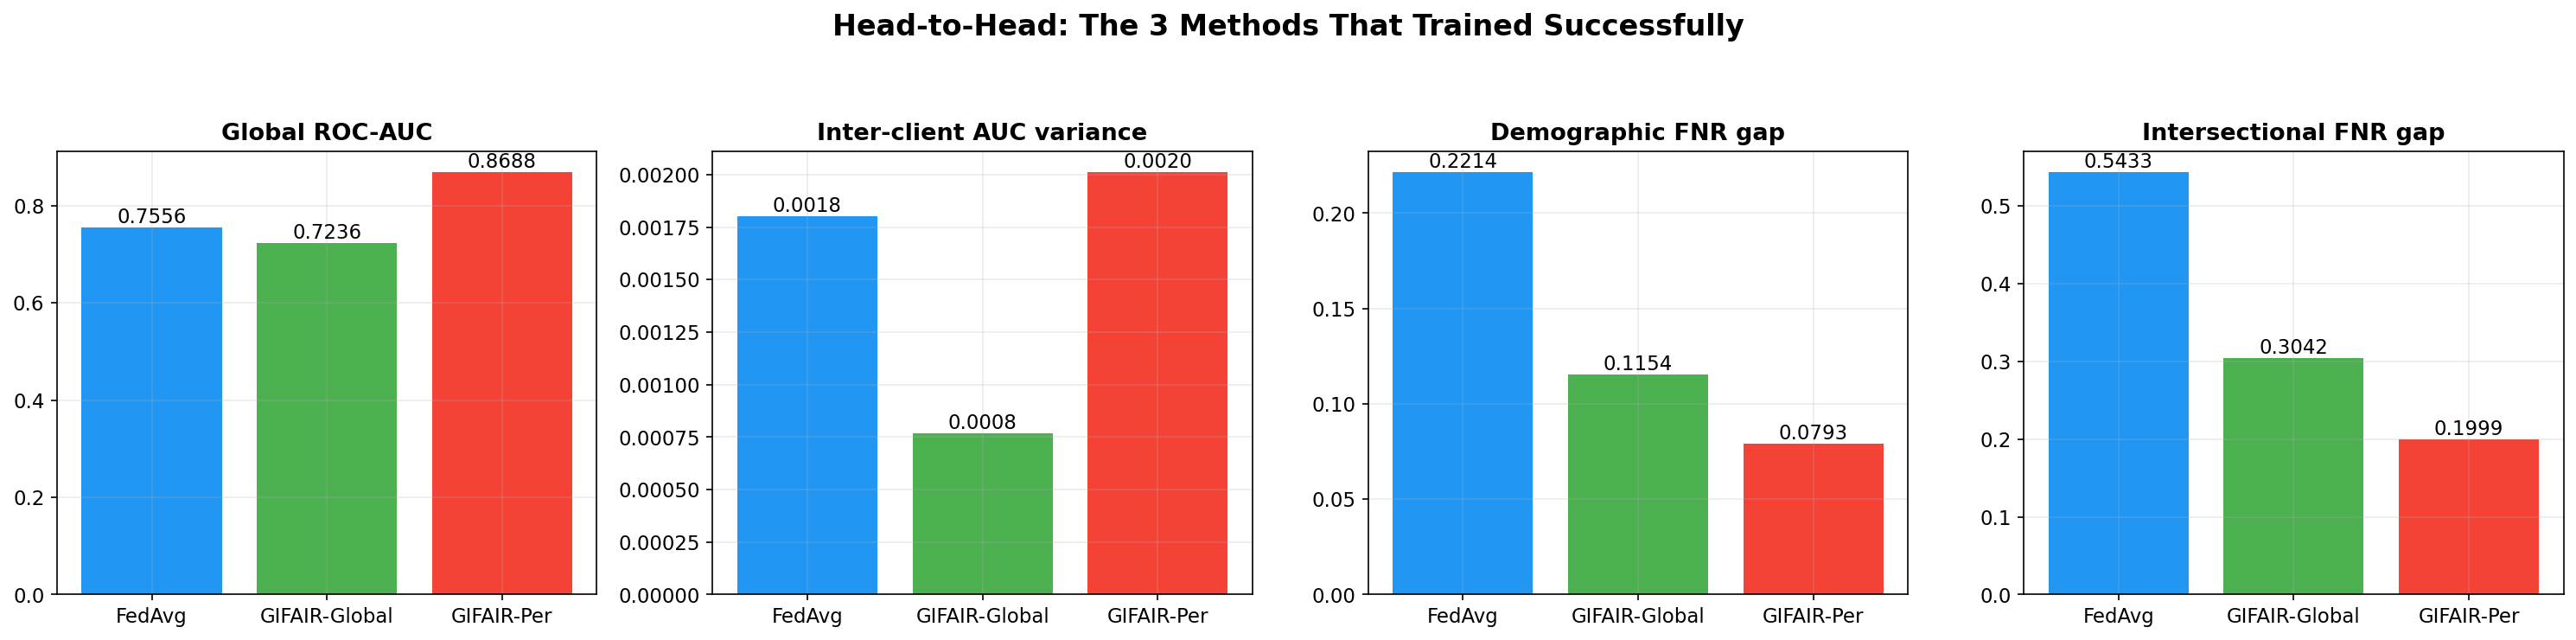

✓ Head-to-head comparison saved


In [ ]:
compare_methods = [m for m in METHODS if is_discriminative[m]]
metrics_to_compare = {
    'Global ROC-AUC': 'global_roc_auc',
    'Inter-client AUC variance': 'inter_client_auc_variance',
    'Demographic FNR gap': 'mean_demographic_fnr_gap',
    'Intersectional FNR gap': 'intersectional_fnr_gap',
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (label, col) in zip(axes, metrics_to_compare.items()):
    values = [df_ranking.loc[m, col] for m in compare_methods]
    bars = ax.bar(compare_methods, values, color=[COLOURS[m] for m in compare_methods])
    ax.set_title(label, fontsize=13)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f'{v:.4f}',
                ha='center', va='bottom', fontsize=11)

fig.suptitle(f'Head-to-Head: The {len(compare_methods)} Methods That Trained Successfully', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.92])
plt.savefig(f'{SAVE_DIR}/head_to_head_fedavg_gifairglobal.png', dpi=200, bbox_inches='tight')
plt.show()
print("✓ Head-to-head comparison saved")

In [ ]:
print("=== HEADLINE FINDING ===")
converged = [m for m in METHODS if is_discriminative[m]]
failed    = [m for m in METHODS if not is_discriminative[m]]
print(f"Methods that trained successfully: {', '.join(converged)}")
print(f"Methods that failed to converge under these conditions: {', '.join(failed)}")
print()
for m in converged:
    print(f"{m:<15}: AUC={df_ranking.loc[m,'global_roc_auc']:.3f}, "
          f"demographic gap={df_ranking.loc[m,'mean_demographic_fnr_gap']:.3f}, "
          f"intersectional gap={df_ranking.loc[m,'intersectional_fnr_gap']:.3f}, "
          f"EOD sex={df_ranking.loc[m,'eod_sex']:.3f}, EOD age={df_ranking.loc[m,'eod_age']:.3f}")

=== HEADLINE FINDING ===
Methods that trained successfully: FedAvg, GIFAIR-Global, GIFAIR-Per
Methods that failed to converge under these conditions: q-FedAvg, Ada-IFFL

FedAvg         : AUC=0.756, demographic gap=0.221, intersectional gap=0.543, EOD sex=0.043, EOD age=0.400
GIFAIR-Global  : AUC=0.724, demographic gap=0.115, intersectional gap=0.304, EOD sex=0.075, EOD age=0.155
GIFAIR-Per     : AUC=0.869, demographic gap=0.079, intersectional gap=0.200, EOD sex=0.025, EOD age=0.133


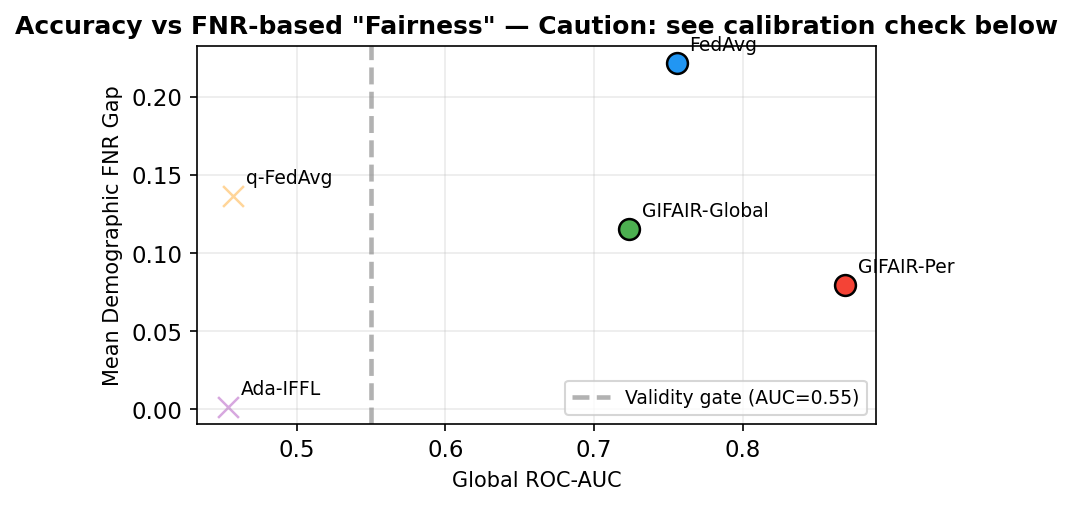

In [ ]:
# Cell 1 — Trade-off scatter
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv(f"{EVAL_DIR}/final_ranking_frozen_split.csv")
df["is_discriminative"] = df["global_roc_auc"] > 0.55

color_map = {'FedAvg':'#2196F3','q-FedAvg':'#FF9800','Ada-IFFL':'#9C27B0',
             'GIFAIR-Global':'#4CAF50','GIFAIR-Per':'#F44336'}

fig, ax = plt.subplots(figsize=(6, 3.5))
for _, row in df.iterrows():
    marker = "o" if row["is_discriminative"] else "x"
    alpha = 1.0 if row["is_discriminative"] else 0.4
    ax.scatter(row["global_roc_auc"], row["mean_demographic_fnr_gap"], s=100,
               marker=marker, alpha=alpha, color=color_map[row["Method"]],
               edgecolors="black", linewidths=1.2)
    ax.annotate(row["Method"], (row["global_roc_auc"], row["mean_demographic_fnr_gap"]),
                xytext=(6, 6), textcoords="offset points", fontsize=9)
ax.axvline(0.55, color="grey", linestyle="--", alpha=0.6, label="Validity gate (AUC=0.55)")
ax.set_xlabel("Global ROC-AUC"); ax.set_ylabel("Mean Demographic FNR Gap")
ax.set_title("Accuracy vs FNR-based \"Fairness\" — Caution: see calibration check below")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{EVAL_DIR}/trade_off_scatter.png", dpi=300)
plt.show()


In [ ]:
# Cell 2 — Load intersectional data + global summary once, reused everywhere below
df_int = pd.read_csv(f"{EVAL_DIR}/intersectional_subgroups_frozen_split.csv")
df_global = pd.read_csv(f"{EVAL_DIR}/summary_global_all_methods_frozen_split.csv", index_col="Method")

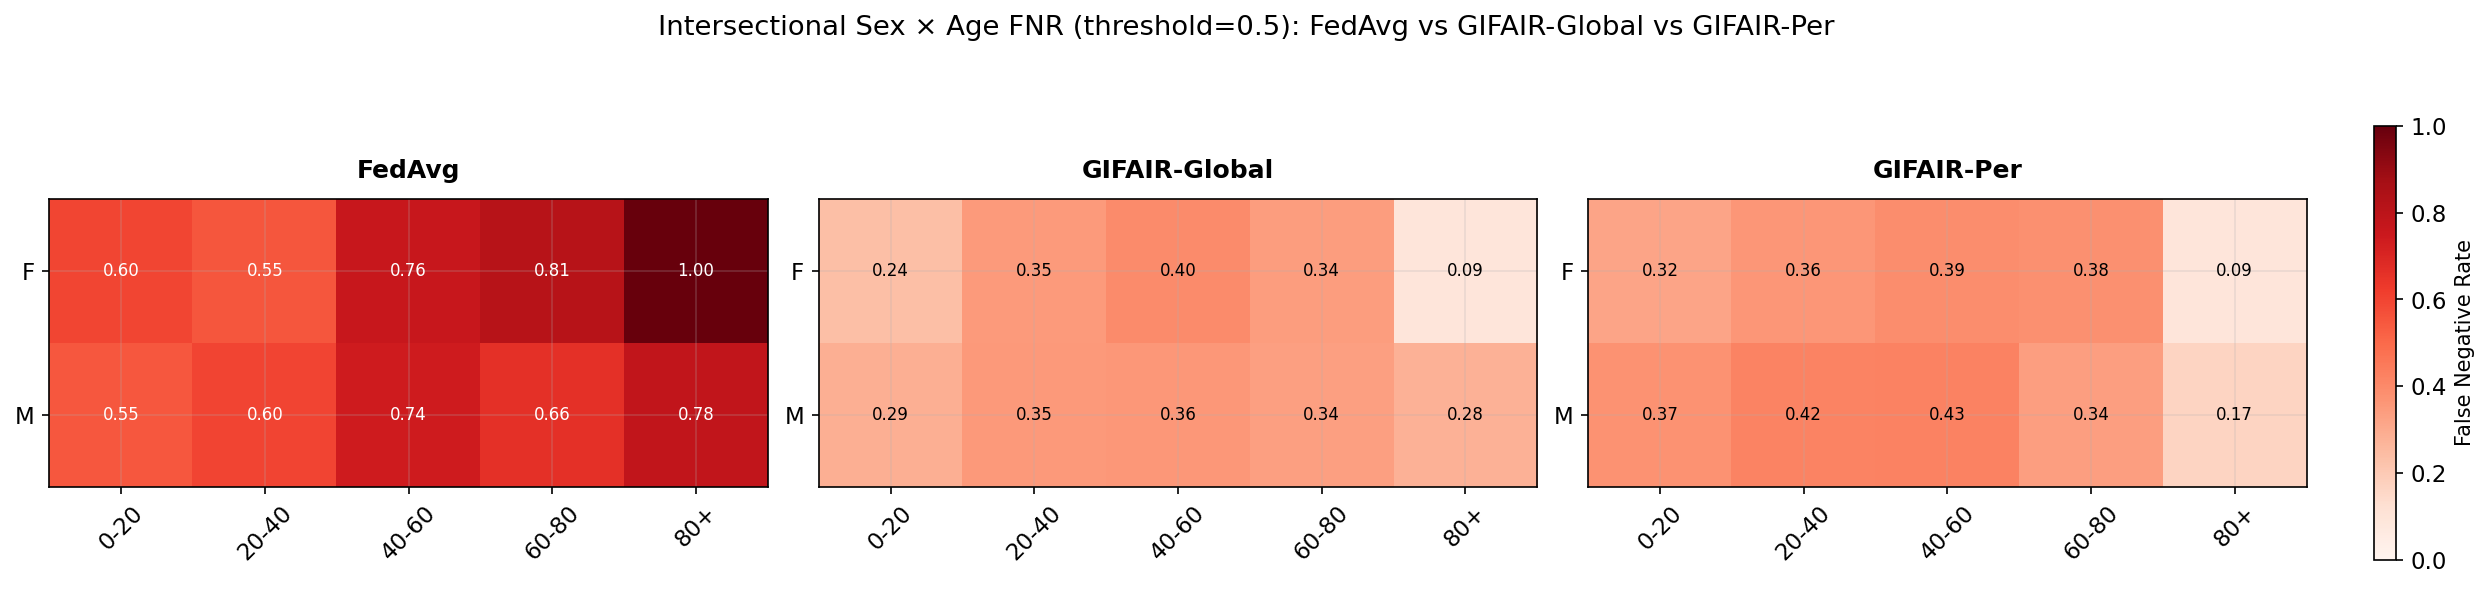

In [ ]:
# Cell 3 — FNR heatmap, all discriminative methods
methods = [m for m in METHODS if is_discriminative[m]]
FNR_COL = "fnr_at_0.5"
age_order = ["0-20","20-40","40-60","60-80","80+"]
sex_order = ["F","M"]

def weighted_metric(df, method, sex, age, col):
    rows = df[(df["Method"]==method)&(df["Sex"]==sex)&(df["AgeGroup"]==age)]
    if rows.empty or rows["n"].sum()==0: return np.nan
    return np.average(rows[col], weights=rows["n"])

fig, axes = plt.subplots(1, len(methods), figsize=(5.5*len(methods), 4.2), constrained_layout=True)
vmax = df_int[FNR_COL].max()
for ax, method in zip(axes, methods):
    grid = np.array([[weighted_metric(df_int, method, s, a, FNR_COL) for a in age_order] for s in sex_order])
    im = ax.imshow(grid, cmap="Reds", vmin=0, vmax=vmax)
    ax.set_xticks(range(5)); ax.set_xticklabels(age_order, rotation=45)
    ax.set_yticks(range(2)); ax.set_yticklabels(sex_order)
    ax.set_title(method, pad=10)
    for i in range(2):
        for j in range(5):
            v = grid[i,j]
            ax.text(j, i, "n/a" if np.isnan(v) else f"{v:.2f}", ha="center", va="center",
                     fontsize=8, color="grey" if np.isnan(v) else ("white" if v>vmax/2 else "black"))
fig.suptitle(f"Intersectional Sex \u00d7 Age FNR (threshold=0.5): {' vs '.join(methods)}")
fig.colorbar(im, ax=axes, shrink=0.75, pad=0.03, label="False Negative Rate")
plt.savefig(f"{EVAL_DIR}/intersectional_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

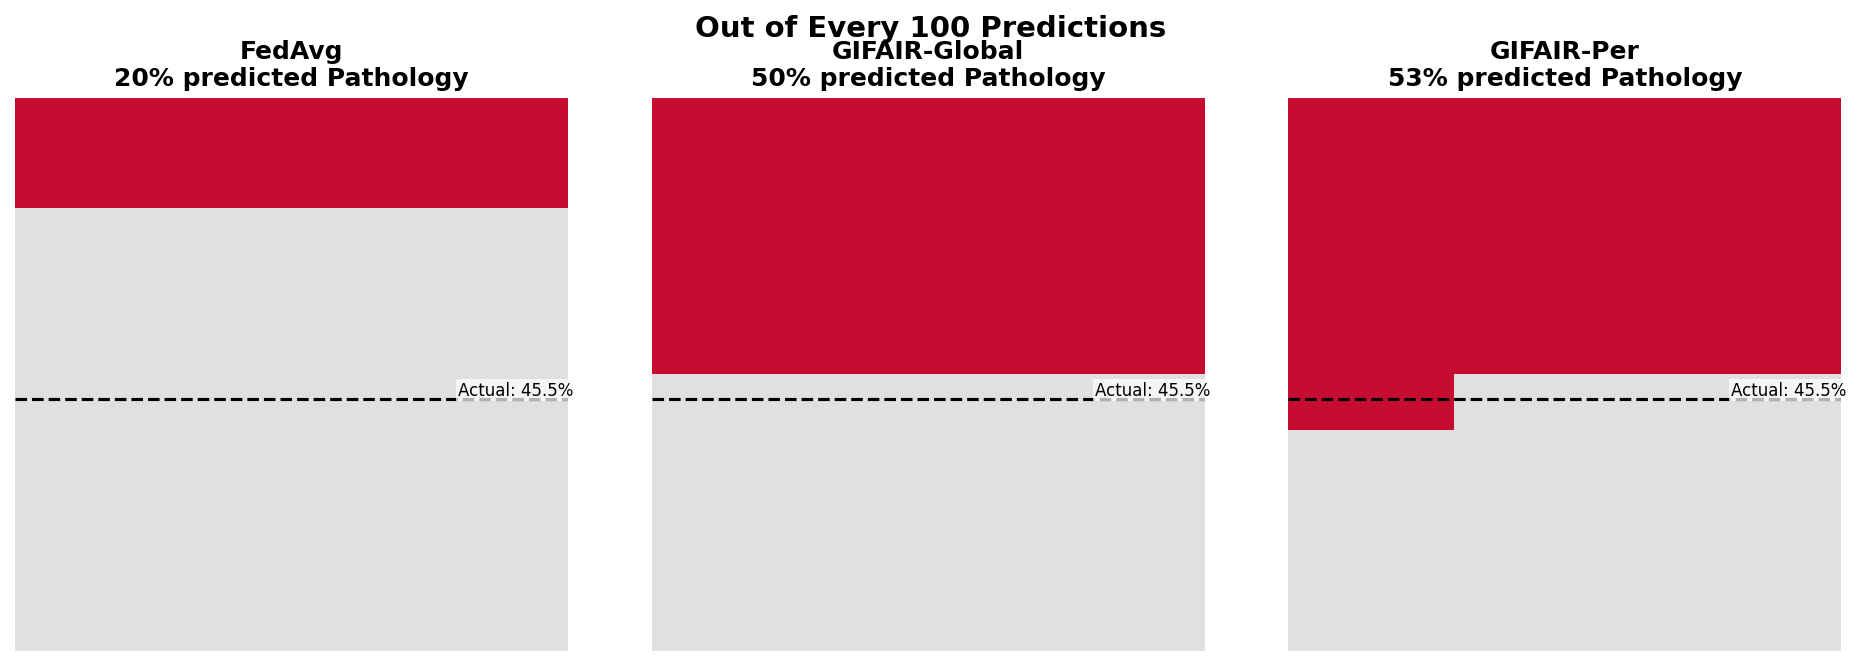

In [ ]:
methods_to_plot = [m for m in METHODS if is_discriminative[m]]
fig, axes = plt.subplots(1, len(methods_to_plot), figsize=(4.3*len(methods_to_plot), 4.5))
if len(methods_to_plot) == 1:
    axes = [axes]

actual_prevalence = df_global['prevalence'].iloc[0] / 100  # same for all methods, e.g. 0.4554

for ax, method in zip(axes, methods_to_plot):
    rate = df_global.loc[method, "predicted_positive_rate"] / 100
    n_filled = int(round(rate * 100))
    grid = np.zeros(100)
    grid[:n_filled] = 1
    grid = grid.reshape(10, 10)
    ax.imshow(grid, cmap=plt.cm.colors.ListedColormap(["#E0E0E0", "#C60C30"]), vmin=0, vmax=1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{method}\n{rate*100:.0f}% predicted Pathology", fontsize=12)

    # Reference line at the true prevalence, so over/under-prediction is visible
    prevalence_row = 10 - (actual_prevalence * 10)
    ax.axhline(prevalence_row - 0.5, color="black", linestyle="--", linewidth=1.5)
    ax.text(9.6, prevalence_row - 0.5, f"Actual: {actual_prevalence*100:.1f}%",
            fontsize=8, ha="right", va="bottom", color="black",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1))

    for spine in ax.spines.values(): spine.set_visible(False)

fig.suptitle("Out of Every 100 Predictions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{EVAL_DIR}/predicted_positive_pictogram_3methods.png", dpi=300, bbox_inches="tight")
plt.show()

                 fpr
Method              
Ada-IFFL       0.000
FedAvg         0.078
GIFAIR-Global  0.376
GIFAIR-Per     0.350
q-FedAvg       0.828


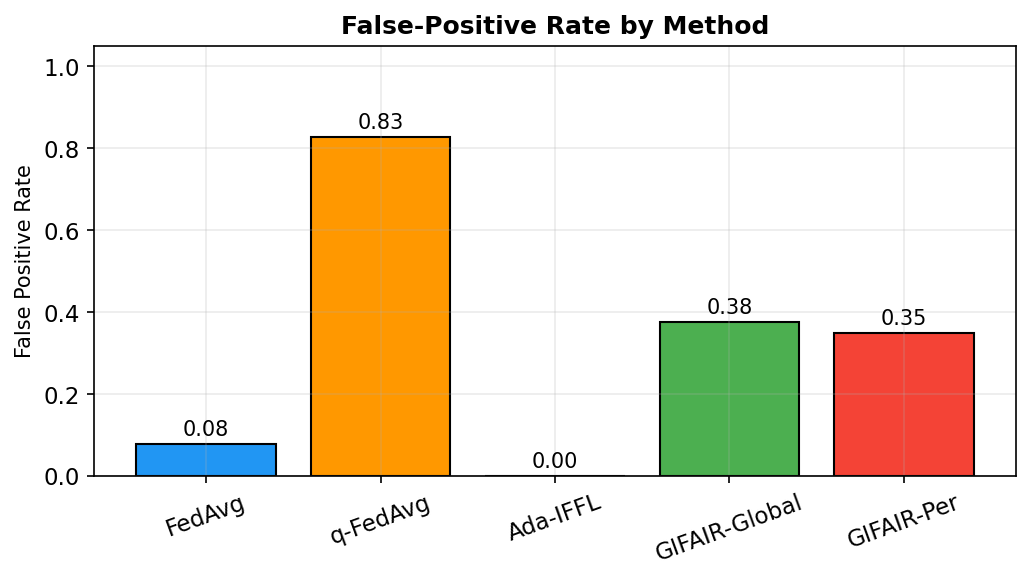

In [ ]:
# Cell 4 — THE KEY CHECK: derive FPR, show the calibration problem plainly
df_int["actual_pos"] = df_int["n"] * df_int["prevalence"] / 100
df_int["actual_neg"] = df_int["n"] - df_int["actual_pos"]
df_int["pred_pos"]   = df_int["n"] * df_int["predicted_positive_rate"] / 100
df_int["fn"]         = df_int["actual_pos"] * df_int["fnr_at_0.5"]
df_int["tp"]         = df_int["actual_pos"] - df_int["fn"]
df_int["fp"]         = df_int["pred_pos"] - df_int["tp"]
df_int["fpr"]        = np.where(df_int["actual_neg"]>0, df_int["fp"]/df_int["actual_neg"], np.nan)

fpr_summary = df_int.groupby("Method")[["fpr"]].mean().round(3)
print(fpr_summary)

fig, ax = plt.subplots(figsize=(7, 4))
fpr_by_method = df_int.groupby("Method")["fpr"].mean().reindex(list(METHODS.keys()))
colors = [COLOURS[m] for m in fpr_by_method.index]
bars = ax.bar(fpr_by_method.index, fpr_by_method.values, color=colors, edgecolor="black")
for bar, v in zip(bars, fpr_by_method.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.02, f"{v:.2f}", ha="center", fontsize=10)
ax.set_ylabel("False Positive Rate"); ax.set_ylim(0, 1.05)
ax.set_title("False-Positive Rate by Method")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f"{EVAL_DIR}/fpr_by_method.png", dpi=300, bbox_inches="tight")
plt.show()

Method         Sex
FedAvg         F      0.7177
               M      0.7681
GIFAIR-Global  F      0.6667
               M      0.7261
GIFAIR-Per     F      0.6672
               M      0.7180
dtype: float64
FedAvg: sex AUC gap = 0.0504
GIFAIR-Global: sex AUC gap = 0.0594
GIFAIR-Per: sex AUC gap = 0.0508


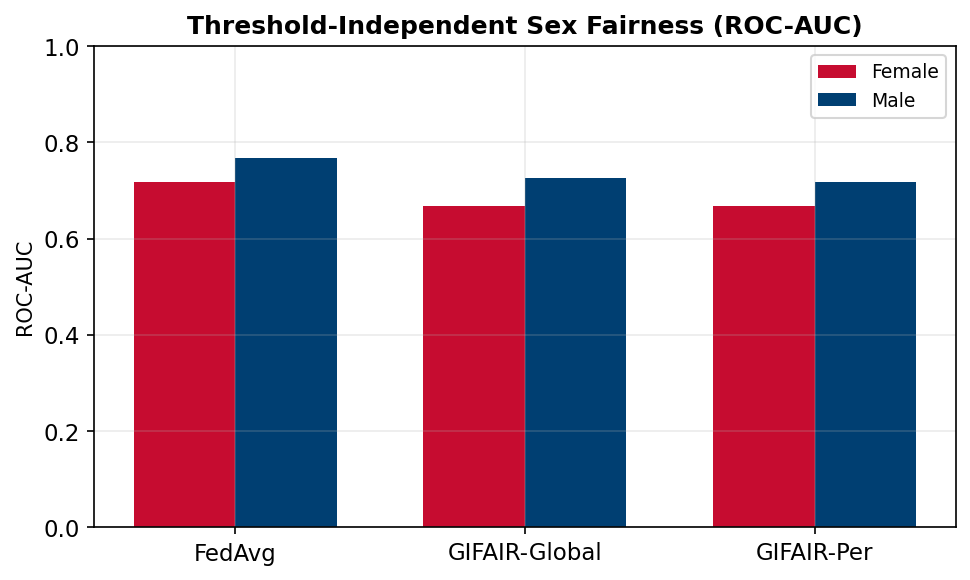

In [ ]:
# Cell 5 — Sex-level AUC comparison, all discriminative methods
sex_auc = (df_int.groupby(["Method","Sex"])
           .apply(lambda g: np.average(g["roc_auc"].dropna(),
                                        weights=g.loc[g["roc_auc"].notna(),"n"])
                  if g["roc_auc"].notna().any() else np.nan, include_groups=False)
           .round(4))

valid_methods = [m for m in METHODS if is_discriminative[m]]
sex_auc_valid = sex_auc.loc[valid_methods]
print(sex_auc_valid)
for m in valid_methods:
    gap = abs(sex_auc_valid[m]["M"] - sex_auc_valid[m]["F"])
    print(f"{m}: sex AUC gap = {gap:.4f}")

fig, ax = plt.subplots(figsize=(2.2*len(valid_methods), 4))
x = np.arange(len(valid_methods)); width = 0.35
f_vals = [sex_auc_valid[m]["F"] for m in valid_methods]
m_vals = [sex_auc_valid[m]["M"] for m in valid_methods]
ax.bar(x - width/2, f_vals, width, label="Female", color="#C60C30")
ax.bar(x + width/2, m_vals, width, label="Male", color="#003F72")
ax.set_xticks(x); ax.set_xticklabels(valid_methods)
ax.set_ylabel("ROC-AUC"); ax.set_ylim(0, 1)
ax.set_title("Threshold-Independent Sex Fairness (ROC-AUC)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{EVAL_DIR}/sex_auc_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

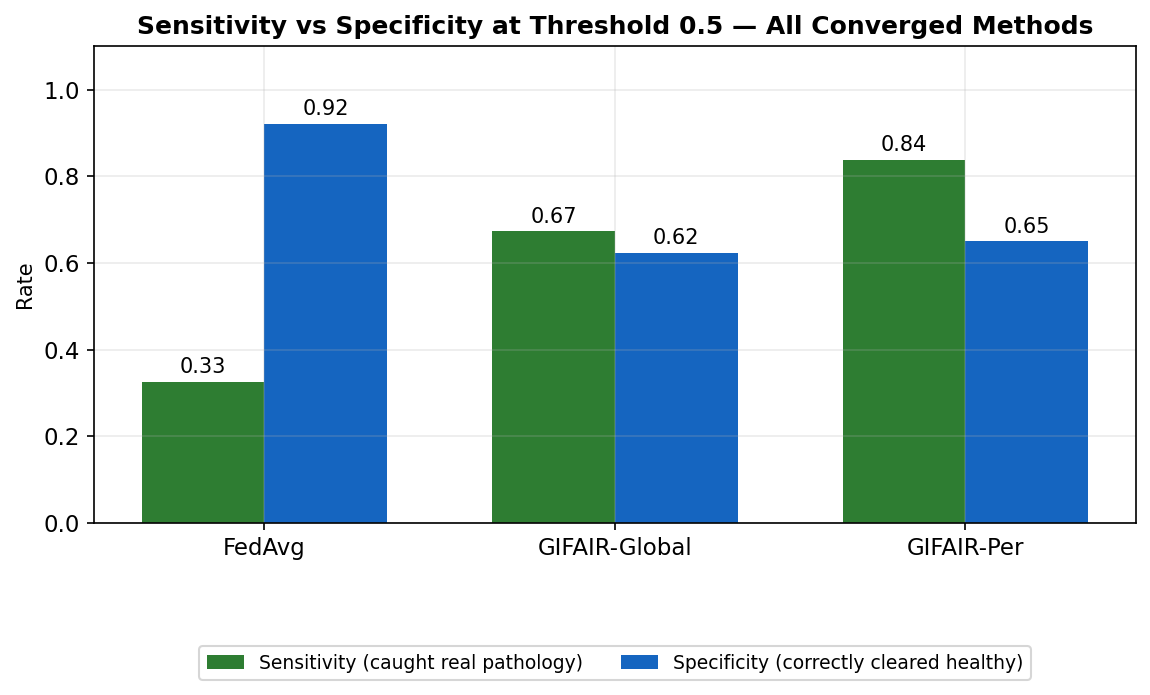

In [ ]:
# Global TPR (sensitivity) and TNR (specificity) by method — the direct picture
valid_methods_all = [m for m in METHODS if is_discriminative[m]]

fig, ax = plt.subplots(figsize=(2.6*len(valid_methods_all), 5))
x = np.arange(len(valid_methods_all))
width = 0.35

tpr_vals = [1 - df_global.loc[m, 'fnr_at_0.5'] for m in valid_methods_all]  # sensitivity
tnr_vals = []
for m in valid_methods_all:
    fpr_m = df_int[df_int["Method"] == m]["fpr"].mean()  # reuse fpr already derived in Cell 4
    tnr_vals.append(1 - fpr_m)

bars1 = ax.bar(x - width/2, tpr_vals, width, label="Sensitivity (caught real pathology)", color="#2E7D32")
bars2 = ax.bar(x + width/2, tnr_vals, width, label="Specificity (correctly cleared healthy)", color="#1565C0")

for bar, v in zip(bars1, tpr_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.02, f"{v:.2f}", ha="center", fontsize=10)
for bar, v in zip(bars2, tnr_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.02, f"{v:.2f}", ha="center", fontsize=10)

ax.set_xticks(x); ax.set_xticklabels(valid_methods_all)
ax.set_ylabel("Rate"); ax.set_ylim(0, 1.1)
ax.set_title("Sensitivity vs Specificity at Threshold 0.5 — All Converged Methods")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.35), ncol=2)
plt.tight_layout()
plt.savefig(f"{EVAL_DIR}/sensitivity_specificity_by_method.png", dpi=300, bbox_inches="tight")
plt.show()

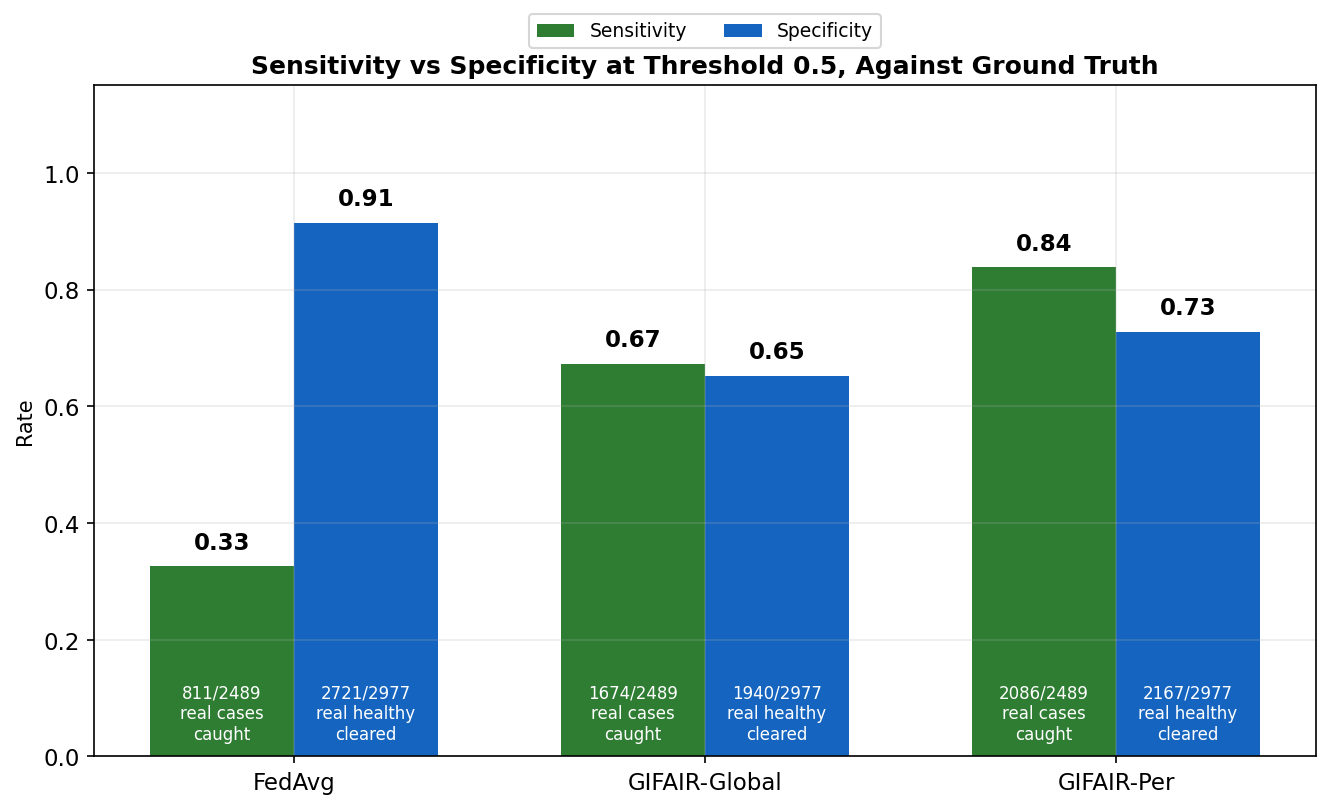

=== Ground truth vs. model output, per method ===
FedAvg: 2489 truly sick → caught 811, missed 1678 | 2977 truly healthy → cleared 2721, false-alarmed 256
GIFAIR-Global: 2489 truly sick → caught 1674, missed 815 | 2977 truly healthy → cleared 1940, false-alarmed 1037
GIFAIR-Per: 2489 truly sick → caught 2086, missed 403 | 2977 truly healthy → cleared 2167, false-alarmed 810


In [ ]:
# Global TPR (sensitivity) and TNR (specificity) by method — WITH ground-truth counts shown
valid_methods_all = [m for m in METHODS if is_discriminative[m]]
fig, ax = plt.subplots(figsize=(3.0*len(valid_methods_all), 5.5))
x = np.arange(len(valid_methods_all))
width = 0.35

tpr_vals, tnr_vals = [], []
tp_counts, fn_counts, tn_counts, fp_counts = [], [], [], []
actual_pos_counts, actual_neg_counts = [], []

for m in valid_methods_all:
    n = df_global.loc[m, 'n']
    prevalence = df_global.loc[m, 'prevalence'] / 100
    pred_rate = df_global.loc[m, 'predicted_positive_rate'] / 100
    fnr = df_global.loc[m, 'fnr_at_0.5']

    actual_pos = round(n * prevalence)
    actual_neg = n - actual_pos
    fn = round(actual_pos * fnr)
    tp = actual_pos - fn
    pred_pos = round(n * pred_rate)
    fp = pred_pos - tp
    tn = actual_neg - fp

    tpr_vals.append(tp / actual_pos)
    tnr_vals.append(tn / actual_neg)
    tp_counts.append(tp); fn_counts.append(fn)
    tn_counts.append(tn); fp_counts.append(fp)
    actual_pos_counts.append(actual_pos); actual_neg_counts.append(actual_neg)

bars1 = ax.bar(x - width/2, tpr_vals, width, label="Sensitivity", color="#2E7D32")
bars2 = ax.bar(x + width/2, tnr_vals, width, label="Specificity", color="#1565C0")

# Rate labels on top
for bar, v in zip(bars1, tpr_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.03, f"{v:.2f}", ha="center", fontsize=11, fontweight="bold")
for bar, v in zip(bars2, tnr_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.03, f"{v:.2f}", ha="center", fontsize=11, fontweight="bold")

# Ground-truth counts inside each bar — this is the actual comparison being requested
for i, m in enumerate(valid_methods_all):
    ax.text(x[i]-width/2, 0.03, f"{tp_counts[i]}/{actual_pos_counts[i]}\nreal cases\ncaught",
            ha="center", fontsize=8, color="white")
    ax.text(x[i]+width/2, 0.03, f"{tn_counts[i]}/{actual_neg_counts[i]}\nreal healthy\ncleared",
            ha="center", fontsize=8, color="white")

ax.set_xticks(x); ax.set_xticklabels(valid_methods_all)
ax.set_ylabel("Rate"); ax.set_ylim(0, 1.15)
ax.set_title("Sensitivity vs Specificity at Threshold 0.5, Against Ground Truth")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.12), ncol=2)
plt.tight_layout()
plt.savefig(f"{EVAL_DIR}/sensitivity_specificity_by_method.png", dpi=300, bbox_inches="tight")
plt.show()

print("=== Ground truth vs. model output, per method ===")
for i, m in enumerate(valid_methods_all):
    print(f"{m}: {actual_pos_counts[i]} truly sick → caught {tp_counts[i]}, missed {fn_counts[i]} | "
          f"{actual_neg_counts[i]} truly healthy → cleared {tn_counts[i]}, false-alarmed {fp_counts[i]}")

In [ ]:
for name in HOSPITAL_NAMES:
    train_ids = set(pd.read_csv(f'{SPLIT_DIR}/{name}_train.csv')['image_path'])
    test_ids = set(test_clients[name]['image_path'])
    overlap = train_ids & test_ids
    print(f"{name}: {len(overlap)} overlapping images between train and test")

Hospital_A: 0 overlapping images between train and test
Hospital_B: 0 overlapping images between train and test
Hospital_C: 0 overlapping images between train and test
Hospital_D: 0 overlapping images between train and test
Hospital_E: 0 overlapping images between train and test


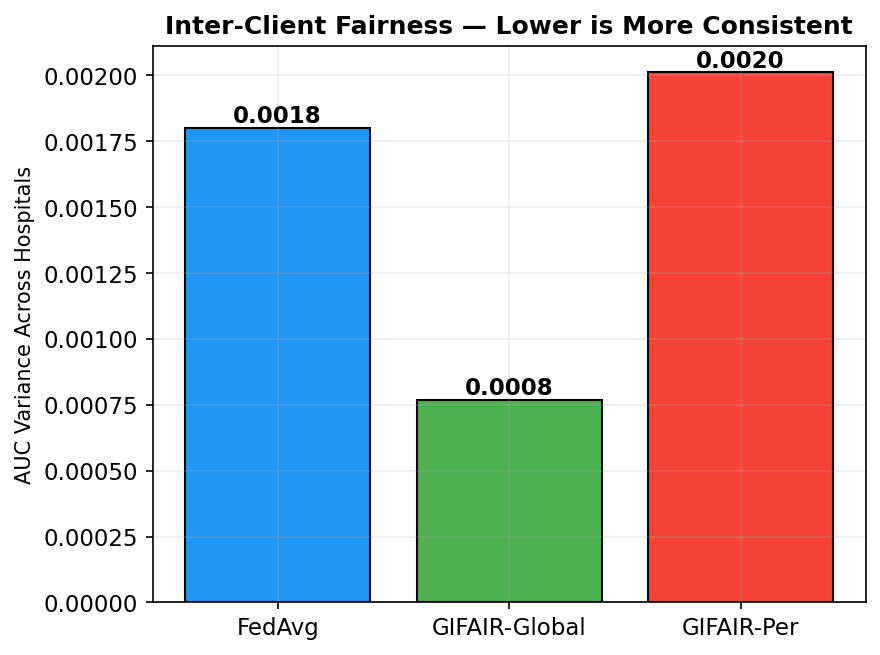

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))
methods_ic = [m for m in METHODS if is_discriminative[m]]
values = [df_ranking.loc[m, 'inter_client_auc_variance'] for m in methods_ic]
bars = ax.bar(methods_ic, values, color=[COLOURS[m] for m in methods_ic], edgecolor="black")
for bar, v in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, v, f"{v:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("AUC Variance Across Hospitals")
ax.set_title("Inter-Client Fairness — Lower is More Consistent")
plt.tight_layout()
plt.savefig(f"{EVAL_DIR}/inter_client_variance_standalone.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
pd.read_csv(f'{EVAL_DIR}/final_ranking_frozen_split.csv').columns.tolist()

['Method',
 'is_discriminative',
 'global_roc_auc',
 'inter_client_auc_variance',
 'mean_sex_fnr_gap',
 'mean_age_fnr_gap',
 'mean_demographic_fnr_gap',
 'eod_sex',
 'eod_age',
 'intersectional_fnr_gap',
 'accuracy']

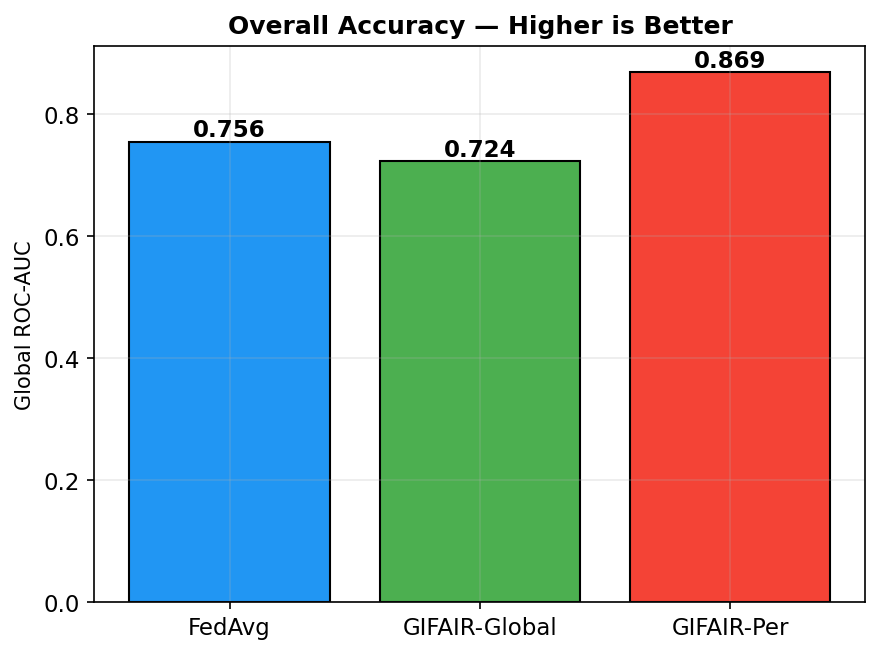

In [ ]:
#standalone Global AUC chart (Section A)
fig, ax = plt.subplots(figsize=(6, 4.5))
methods3 = [m for m in METHODS if is_discriminative[m]]
vals = [df_ranking.loc[m, 'global_roc_auc'] for m in methods3]
bars = ax.bar(methods3, vals, color=[COLOURS[m] for m in methods3], edgecolor="black")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Global ROC-AUC"); ax.set_title("Overall Accuracy — Higher is Better")
plt.tight_layout()
plt.savefig(f"{EVAL_DIR}/global_auc_standalone.png", dpi=300, bbox_inches="tight")
plt.show()

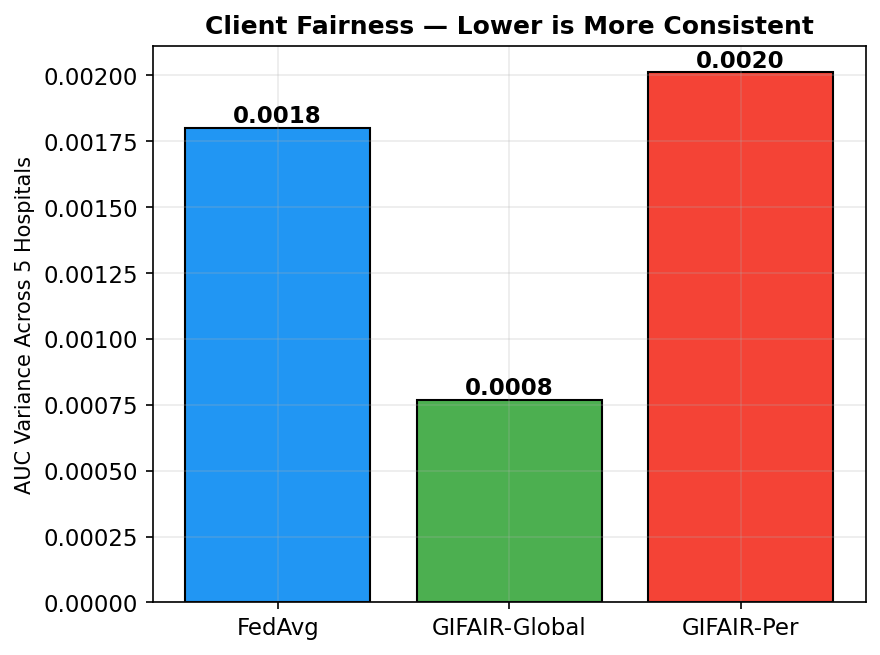

In [ ]:
#standalone Client Fairness chart (Section B):
fig, ax = plt.subplots(figsize=(6, 4.5))
vals = [df_ranking.loc[m, 'inter_client_auc_variance'] for m in methods3]
bars = ax.bar(methods3, vals, color=[COLOURS[m] for m in methods3], edgecolor="black")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, v, f"{v:.4f}", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("AUC Variance Across 5 Hospitals"); ax.set_title("Client Fairness — Lower is More Consistent")
plt.tight_layout()
plt.savefig(f"{EVAL_DIR}/client_fairness_standalone.png", dpi=300, bbox_inches="tight")
plt.show()

{'FedAvg': 0.0642, 'GIFAIR-Global': 0.161, 'GIFAIR-Per': 0.1237}


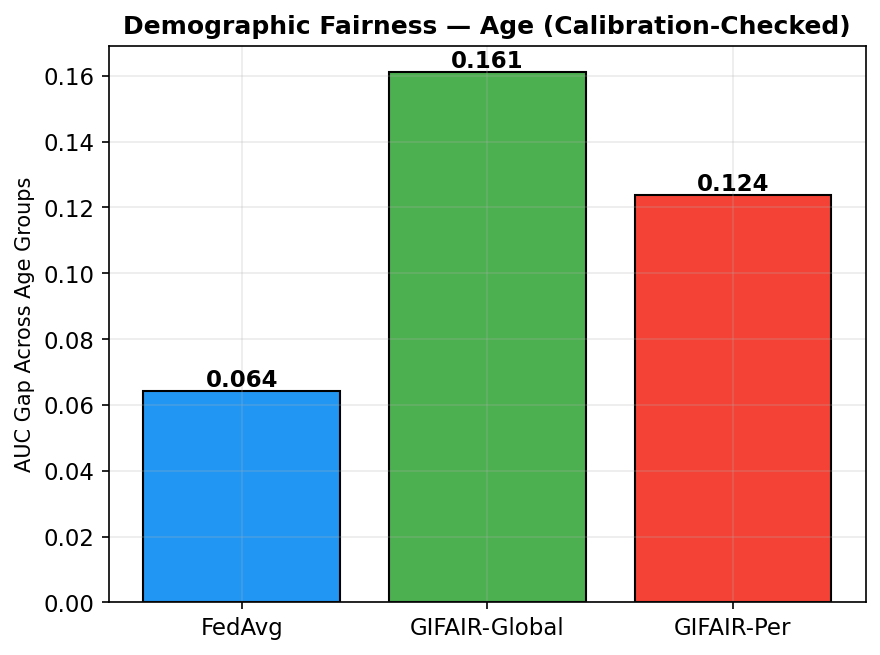

In [ ]:
# Age AUC chart (Section D)
age_auc = (df_age.groupby(["Method","AgeGroup"])
           .apply(lambda g: np.average(g["roc_auc"].dropna(),
                                        weights=g.loc[g["roc_auc"].notna(),"n"])
                  if g["roc_auc"].notna().any() else np.nan, include_groups=False)
           .round(4))

age_auc_gap = {}
for m in methods3:
    vals = age_auc.loc[m].dropna()
    age_auc_gap[m] = round(vals.max() - vals.min(), 4) if len(vals) >= 2 else float('nan')

print(age_auc_gap)

fig, ax = plt.subplots(figsize=(6, 4.5))
vals = [age_auc_gap[m] for m in methods3]
bars = ax.bar(methods3, vals, color=[COLOURS[m] for m in methods3], edgecolor="black")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("AUC Gap Across Age Groups"); ax.set_title("Demographic Fairness — Age (Calibration-Checked)")
plt.tight_layout()
plt.savefig(f"{EVAL_DIR}/age_fairness_standalone.png", dpi=300, bbox_inches="tight")
plt.show()

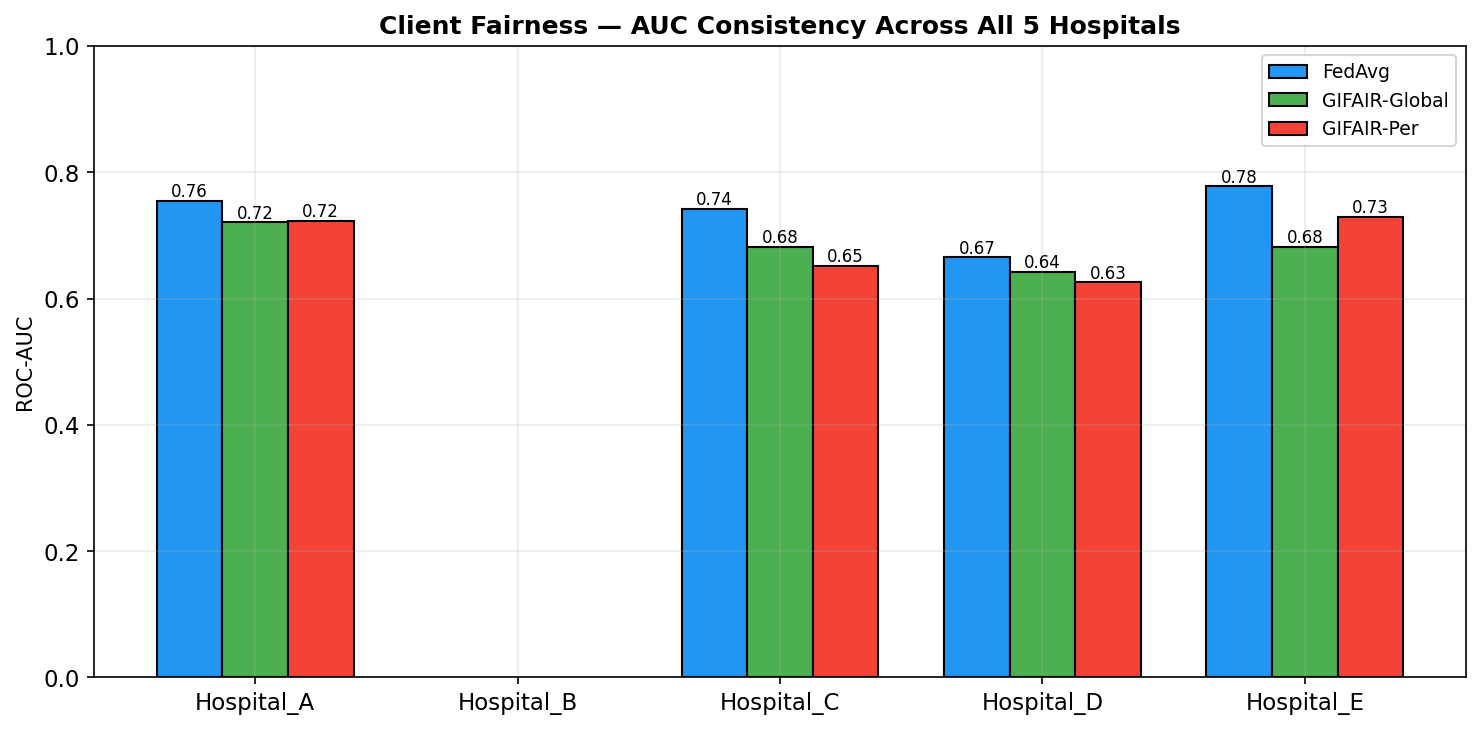

In [ ]:
#"photographic" version — AUC per hospital, per method, grouped:
fig, ax = plt.subplots(figsize=(10, 5))
methods3 = [m for m in METHODS if is_discriminative[m]]
x = np.arange(len(HOSPITAL_NAMES))
width = 0.25

for i, m in enumerate(methods3):
    vals = [df_hospital[(df_hospital['Method']==m)&(df_hospital['Hospital']==h)]['roc_auc'].values[0]
            if len(df_hospital[(df_hospital['Method']==m)&(df_hospital['Hospital']==h)]) else np.nan
            for h in HOSPITAL_NAMES]
    bars = ax.bar(x + i*width, vals, width, label=m, color=COLOURS[m], edgecolor="black")
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x()+bar.get_width()/2, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width); ax.set_xticklabels(HOSPITAL_NAMES)
ax.set_ylabel("ROC-AUC"); ax.set_ylim(0, 1.0)
ax.set_title("Client Fairness — AUC Consistency Across All 5 Hospitals")
ax.legend()
plt.tight_layout()
plt.savefig(f"{EVAL_DIR}/client_fairness_per_hospital.png", dpi=300, bbox_inches="tight")
plt.show()

{'FedAvg': 0.0642, 'GIFAIR-Global': 0.161, 'GIFAIR-Per': 0.1237}


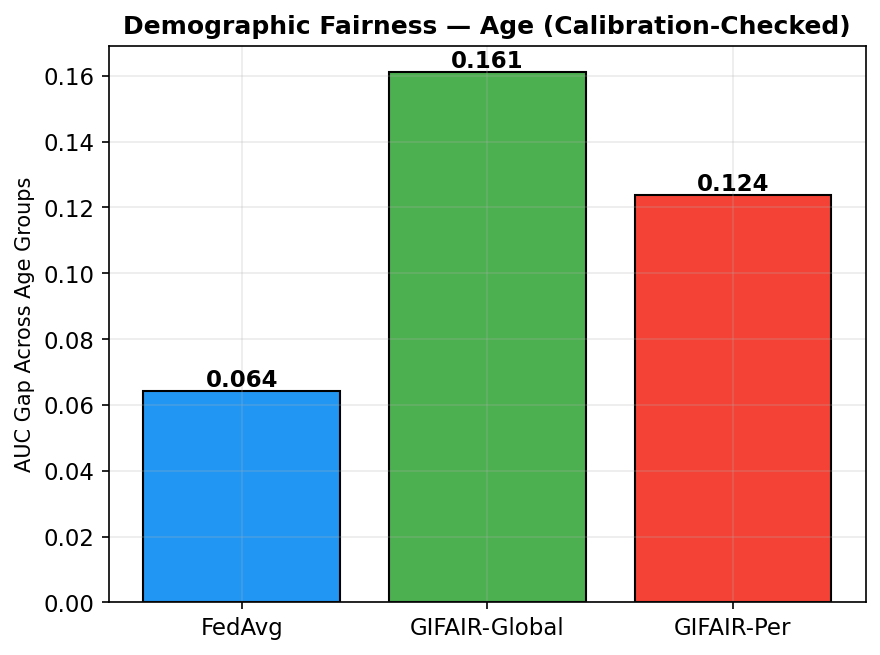

In [ ]:
#Age-level
age_auc = (df_age.groupby(["Method","AgeGroup"])
           .apply(lambda g: np.average(g["roc_auc"].dropna(),
                                        weights=g.loc[g["roc_auc"].notna(),"n"])
                  if g["roc_auc"].notna().any() else np.nan, include_groups=False)
           .round(4))

age_auc_gap = {m: round(age_auc.loc[m].dropna().max() - age_auc.loc[m].dropna().min(), 4)
               for m in methods3 if len(age_auc.loc[m].dropna()) >= 2}
print(age_auc_gap)

fig, ax = plt.subplots(figsize=(6, 4.5))
vals = [age_auc_gap[m] for m in methods3]
bars = ax.bar(methods3, vals, color=[COLOURS[m] for m in methods3], edgecolor="black")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("AUC Gap Across Age Groups")
ax.set_title("Demographic Fairness — Age (Calibration-Checked)")
plt.tight_layout()
plt.savefig(f"{EVAL_DIR}/age_fairness_standalone.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#Intersectional
int_auc = (df_intersect.groupby(["Method","Sex","AgeGroup"])["roc_auc"].mean().round(4))
for m in methods3:
    sub = int_auc.loc[m].dropna()
    print(f"{m}: {len(sub)} usable cells, gap = {(sub.max()-sub.min()):.3f}" if len(sub)>=2 else f"{m}: insufficient cells")

FedAvg: 9 usable cells, gap = 0.138
GIFAIR-Global: 9 usable cells, gap = 0.250
GIFAIR-Per: 9 usable cells, gap = 0.175


=== Intersectional AUC — usable cells per method ===
FedAvg: 9 cells, gap = 0.138
GIFAIR-Global: 9 cells, gap = 0.250
GIFAIR-Per: 9 cells, gap = 0.175


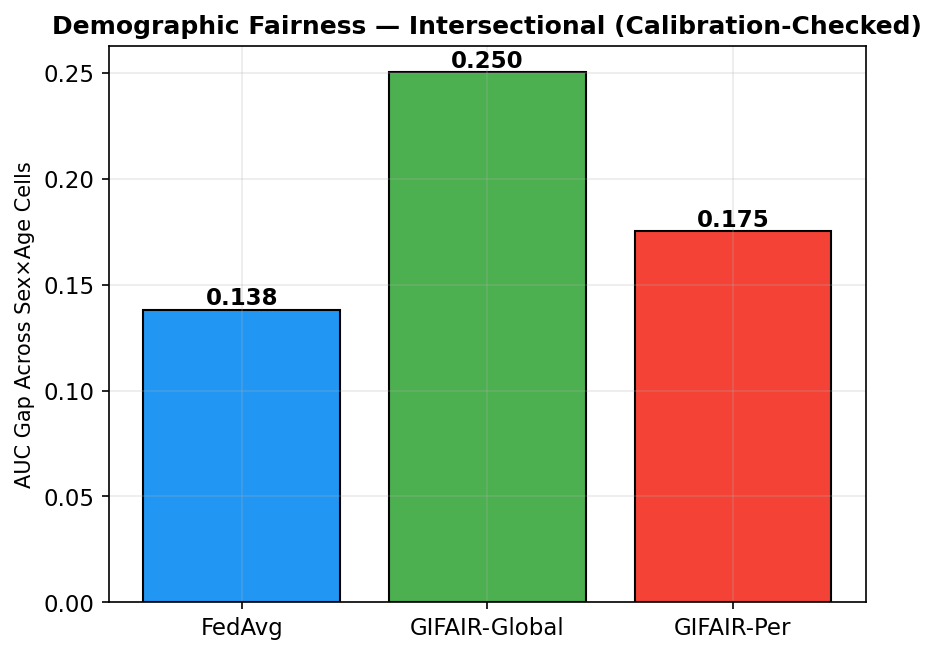

In [ ]:
int_auc = (df_intersect.groupby(["Method","Sex","AgeGroup"])["roc_auc"].mean().round(4))

print("=== Intersectional AUC — usable cells per method ===")
int_auc_gap = {}
for m in [mm for mm in METHODS if is_discriminative[mm]]:
    sub = int_auc.loc[m].dropna()
    if len(sub) >= 2:
        int_auc_gap[m] = round(sub.max() - sub.min(), 4)
        print(f"{m}: {len(sub)} cells, gap = {int_auc_gap[m]:.3f}")
    else:
        print(f"{m}: only {len(sub)} usable cell(s) — insufficient for a gap")

if len(int_auc_gap) >= 2:
    fig, ax = plt.subplots(figsize=(6, 4.5))
    methods3 = list(int_auc_gap.keys())
    vals = list(int_auc_gap.values())
    bars = ax.bar(methods3, vals, color=[COLOURS[m] for m in methods3], edgecolor="black")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom", fontweight="bold")
    ax.set_ylabel("AUC Gap Across Sex×Age Cells")
    ax.set_title("Demographic Fairness — Intersectional (Calibration-Checked)")
    plt.tight_layout()
    plt.savefig(f"{EVAL_DIR}/intersectional_fairness_standalone.png", dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:
# Check which AgeGroup×Method cells actually have enough data to trust
print(df_age.groupby(['Method','AgeGroup'])['n'].sum().unstack())

# And specifically: how many patients back each AUC value going into the age gap calc
for m in [mm for mm in METHODS if is_discriminative[mm]]:
    sub = df_age[df_age['Method']==m][['AgeGroup','n','roc_auc']].dropna()
    print(f"\n{m}:")
    print(sub.to_string(index=False))

AgeGroup       0-20  20-40  40-60  60-80  80+
Method                                       
Ada-IFFL        438   1455   2368   1146   36
FedAvg          438   1455   2368   1146   36
GIFAIR-Global   438   1455   2368   1146   36
GIFAIR-Per      438   1455   2368   1146   36
q-FedAvg        438   1455   2368   1146   36

FedAvg:
AgeGroup    n  roc_auc
    0-20  282   0.7410
   20-40  744   0.8064
   40-60 1313   0.7254
   60-80  630   0.7392
     80+   36   0.7389
    0-20  117   0.8268
   20-40  536   0.7518
   40-60  710   0.7083
   60-80  339   0.7395
   20-40   17   0.6515
   40-60   32   0.5938
   60-80   21   0.8000
   20-40   40   0.8284
   40-60   90   0.7537
   60-80   25   0.9565

GIFAIR-Global:
AgeGroup    n  roc_auc
    0-20  282   0.7492
   20-40  744   0.7838
   40-60 1313   0.6962
   60-80  630   0.6612
     80+   36   0.6059
    0-20  117   0.8096
   20-40  536   0.6962
   40-60  710   0.6523
   60-80  339   0.6560
   20-40   17   0.6970
   40-60   32   0.5885
   60-80 

In [ ]:
for m in ['FedAvg', 'GIFAIR-Global', 'GIFAIR-Per']:
    sub = df_age[(df_age['Method']==m) & (df_age['AgeGroup']!='80+')]
    aucs = sub['roc_auc'].dropna()
    print(f"{m}: gap excluding 80+ = {aucs.max()-aucs.min():.4f} (vs full gap including it)")

FedAvg: gap excluding 80+ = 0.3627 (vs full gap including it)
GIFAIR-Global: gap excluding 80+ = 0.2211 (vs full gap including it)
GIFAIR-Per: gap excluding 80+ = 0.4721 (vs full gap including it)


In [ ]:
for m in ['FedAvg', 'GIFAIR-Global', 'GIFAIR-Per']:
    sub = df_age[(df_age['Method']==m) & (df_age['AgeGroup']!='80+')].dropna(subset=['roc_auc'])
    pooled = sub.groupby('AgeGroup').apply(
        lambda g: np.average(g['roc_auc'], weights=g['n'])
    )
    gap_excl = pooled.max() - pooled.min()
    print(f"{m}: gap excluding 80+ = {gap_excl:.4f}")

FedAvg: gap excluding 80+ = 0.0642
GIFAIR-Global: gap excluding 80+ = 0.1046
GIFAIR-Per: gap excluding 80+ = 0.1048


In [ ]:
for m in ['FedAvg', 'GIFAIR-Global', 'GIFAIR-Per']:
    aucs_all = df_hospital[df_hospital['Method']==m]['roc_auc'].dropna()
    aucs_excl_d = df_hospital[(df_hospital['Method']==m) & (df_hospital['Hospital']!='Hospital_D')]['roc_auc'].dropna()
    print(f"{m}: variance ALL hospitals = {aucs_all.var():.6f} | excluding Hospital_D = {aucs_excl_d.var():.6f}")

FedAvg: variance ALL hospitals = 0.002403 | excluding Hospital_D = 0.000326
GIFAIR-Global: variance ALL hospitals = 0.001025 | excluding Hospital_D = 0.000503
GIFAIR-Per: variance ALL hospitals = 0.002681 | excluding Hospital_D = 0.001865


In [ ]:
print("Rows in df_hospital per method:")
print(df_hospital.groupby('Method').size())

print("\nCompare to df_ranking (the one your poster is built on):")
print(df_ranking[['inter_client_auc_variance']])

print("\nRaw AUCs currently in df_hospital for each method:")
for m in ['FedAvg', 'GIFAIR-Global', 'GIFAIR-Per']:
    print(m, df_hospital[df_hospital['Method']==m]['roc_auc'].dropna().values)

Rows in df_hospital per method:
Method
Ada-IFFL         5
FedAvg           5
GIFAIR-Global    5
GIFAIR-Per       5
q-FedAvg         5
dtype: int64

Compare to df_ranking (the one your poster is built on):
               inter_client_auc_variance
Method                                  
FedAvg                          0.001802
q-FedAvg                        0.000082
Ada-IFFL                        0.000540
GIFAIR-Global                   0.000768
GIFAIR-Per                      0.002011

Raw AUCs currently in df_hospital for each method:
FedAvg [0.7553 0.7426 0.6652 0.7782]
GIFAIR-Global [0.7209 0.6817 0.6425 0.6824]
GIFAIR-Per [0.7234 0.652  0.6259 0.7298]


In [ ]:
print("df_hospital row counts per method:")
print(df_hospital.groupby('Method').size())

print("\nRaw AUCs in df_hospital right now:")
for m in ['FedAvg', 'GIFAIR-Global', 'GIFAIR-Per']:
    vals = df_hospital[df_hospital['Method']==m]['roc_auc'].dropna().values
    print(f"{m}: {vals}")

df_hospital row counts per method:
Method
Ada-IFFL         5
FedAvg           5
GIFAIR-Global    5
GIFAIR-Per       5
q-FedAvg         5
dtype: int64

Raw AUCs in df_hospital right now:
FedAvg: [0.7553 0.7426 0.6652 0.7782]
GIFAIR-Global: [0.7209 0.6817 0.6425 0.6824]
GIFAIR-Per: [0.7234 0.652  0.6259 0.7298]


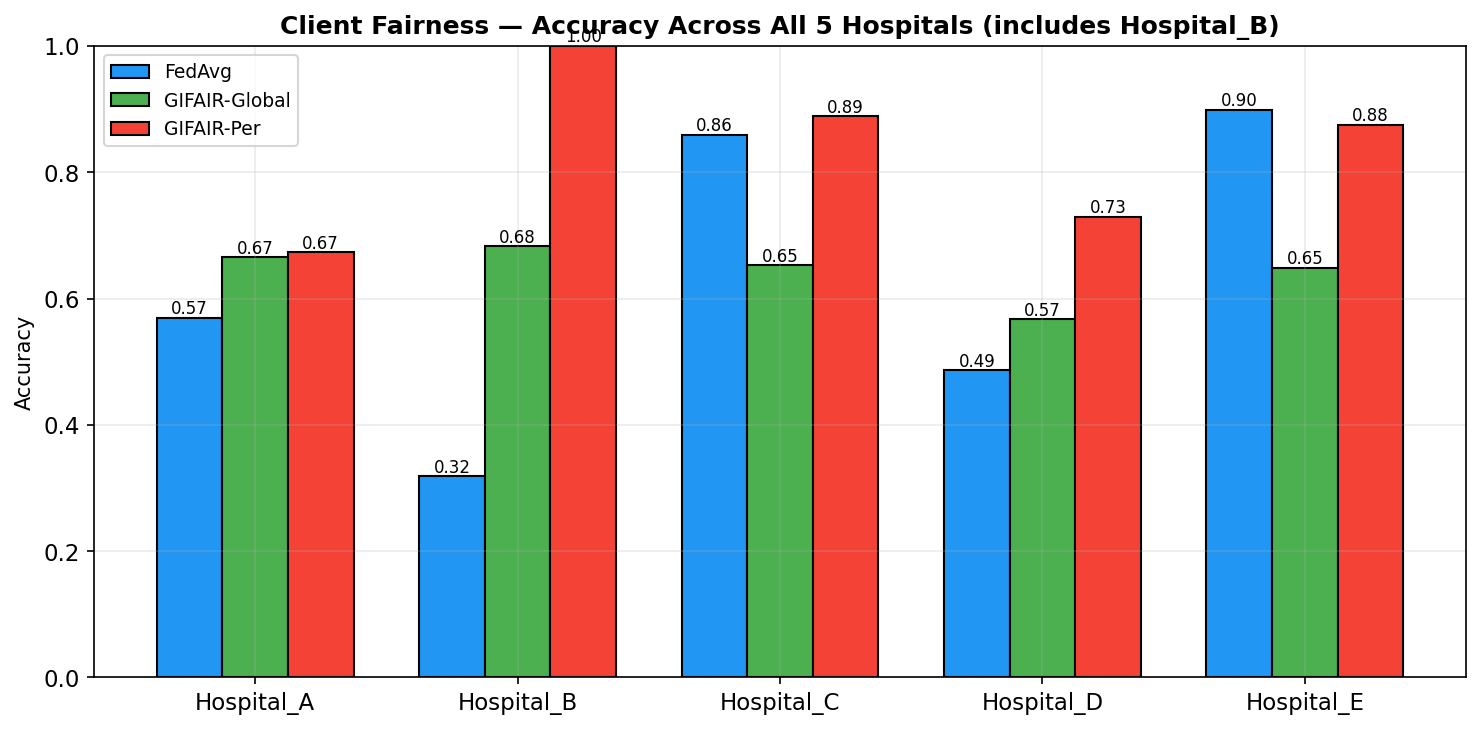

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
methods3 = [m for m in METHODS if is_discriminative[m]]
x = np.arange(len(HOSPITAL_NAMES))
width = 0.25

for i, m in enumerate(methods3):
    vals = [df_hospital[(df_hospital['Method']==m)&(df_hospital['Hospital']==h)]['accuracy'].values[0]/100
            if len(df_hospital[(df_hospital['Method']==m)&(df_hospital['Hospital']==h)]) else np.nan
            for h in HOSPITAL_NAMES]
    bars = ax.bar(x + i*width, vals, width, label=m, color=COLOURS[m], edgecolor="black")
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x()+bar.get_width()/2, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width); ax.set_xticklabels(HOSPITAL_NAMES)
ax.set_ylabel("Accuracy"); ax.set_ylim(0, 1.0)
ax.set_title("Client Fairness — Accuracy Across All 5 Hospitals (includes Hospital_B)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{EVAL_DIR}/client_fairness_accuracy_all_hospitals.png", dpi=300, bbox_inches="tight")
plt.show()

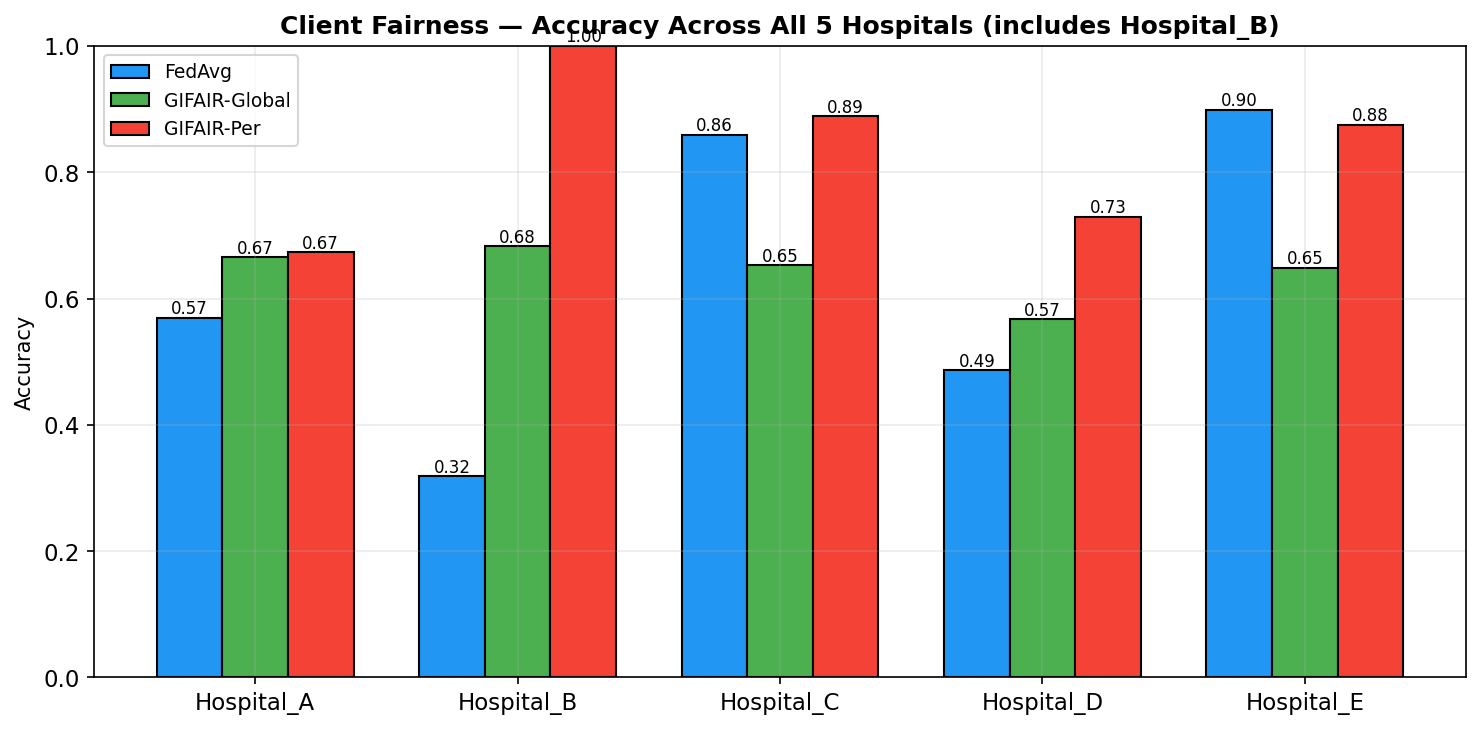

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
methods3 = [m for m in METHODS if is_discriminative[m]]
x = np.arange(len(HOSPITAL_NAMES))
width = 0.25

for i, m in enumerate(methods3):
    vals = [df_hospital[(df_hospital['Method']==m)&(df_hospital['Hospital']==h)]['accuracy'].values[0]/100
            if len(df_hospital[(df_hospital['Method']==m)&(df_hospital['Hospital']==h)]) else np.nan
            for h in HOSPITAL_NAMES]
    bars = ax.bar(x + i*width, vals, width, label=m, color=COLOURS[m], edgecolor="black")
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x()+bar.get_width()/2, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width); ax.set_xticklabels(HOSPITAL_NAMES)
ax.set_ylabel("Accuracy"); ax.set_ylim(0, 1.0)
ax.set_title("Client Fairness — Accuracy Across All 5 Hospitals (includes Hospital_B)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{EVAL_DIR}/client_fairness_accuracy_all_hospitals.png", dpi=300, bbox_inches="tight")
plt.show()

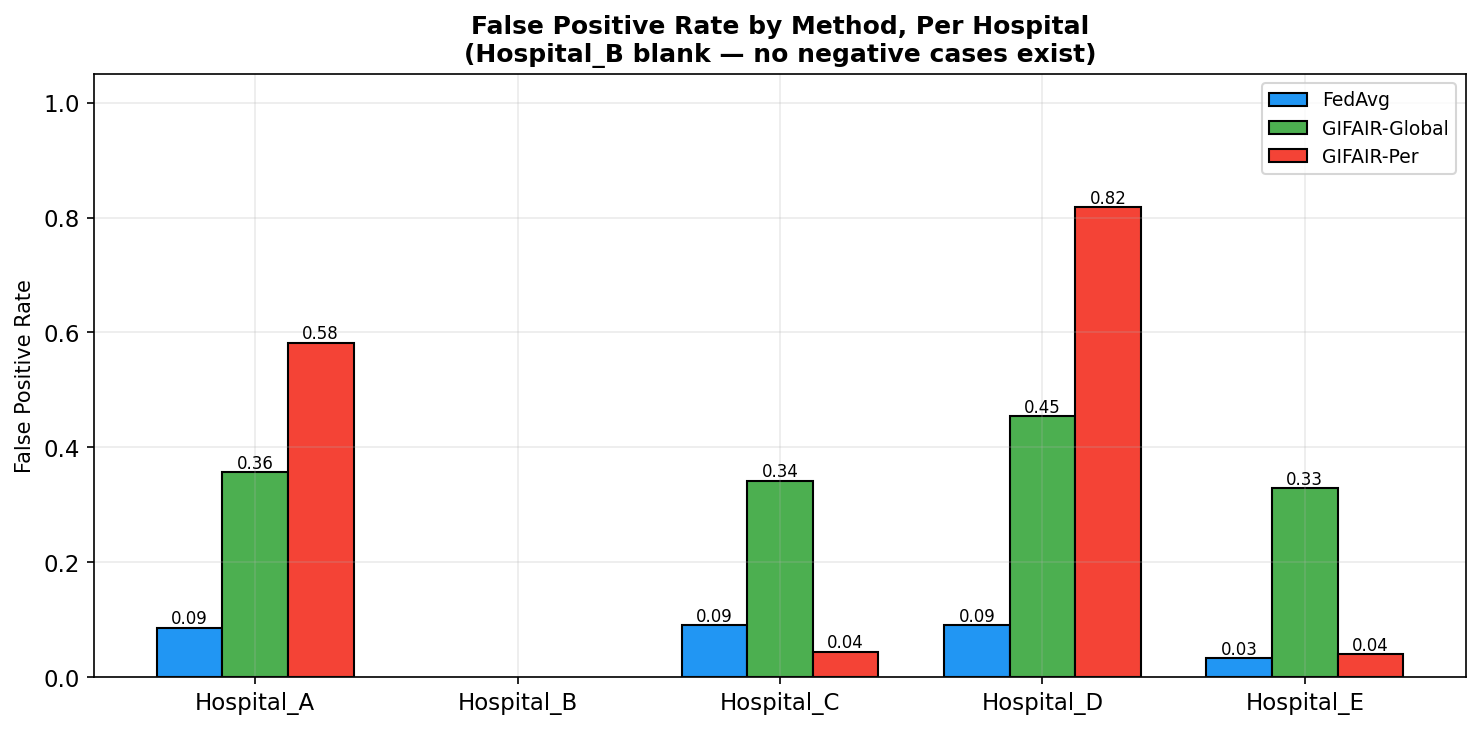

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
methods3 = [m for m in METHODS if is_discriminative[m]]
x = np.arange(len(HOSPITAL_NAMES))
width = 0.25

for i, m in enumerate(methods3):
    vals = []
    for h in HOSPITAL_NAMES:
        row = df_hospital[(df_hospital['Method']==m) & (df_hospital['Hospital']==h)]
        if len(row) == 0:
            vals.append(np.nan)
            continue
        n = row['n'].values[0]
        prevalence = row['prevalence'].values[0] / 100
        fnr = row['fnr_at_0.5'].values[0]
        pred_rate = row['predicted_positive_rate'].values[0] / 100 if 'predicted_positive_rate' in row.columns else np.nan

        actual_neg = n * (1 - prevalence)
        if actual_neg == 0:
            vals.append(np.nan)  # Hospital_B — FPR undefined, no negatives exist
            continue
        actual_pos = n - actual_neg
        fn = actual_pos * fnr
        tp = actual_pos - fn
        pred_pos = n * pred_rate
        fp = pred_pos - tp
        vals.append(fp / actual_neg)

    bars = ax.bar(x + i*width, vals, width, label=m, color=COLOURS[m], edgecolor="black")
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x()+bar.get_width()/2, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width); ax.set_xticklabels(HOSPITAL_NAMES)
ax.set_ylabel("False Positive Rate"); ax.set_ylim(0, 1.05)
ax.set_title("False Positive Rate by Method, Per Hospital\n(Hospital_B blank — no negative cases exist)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{EVAL_DIR}/fpr_per_hospital.png", dpi=300, bbox_inches="tight")
plt.show()

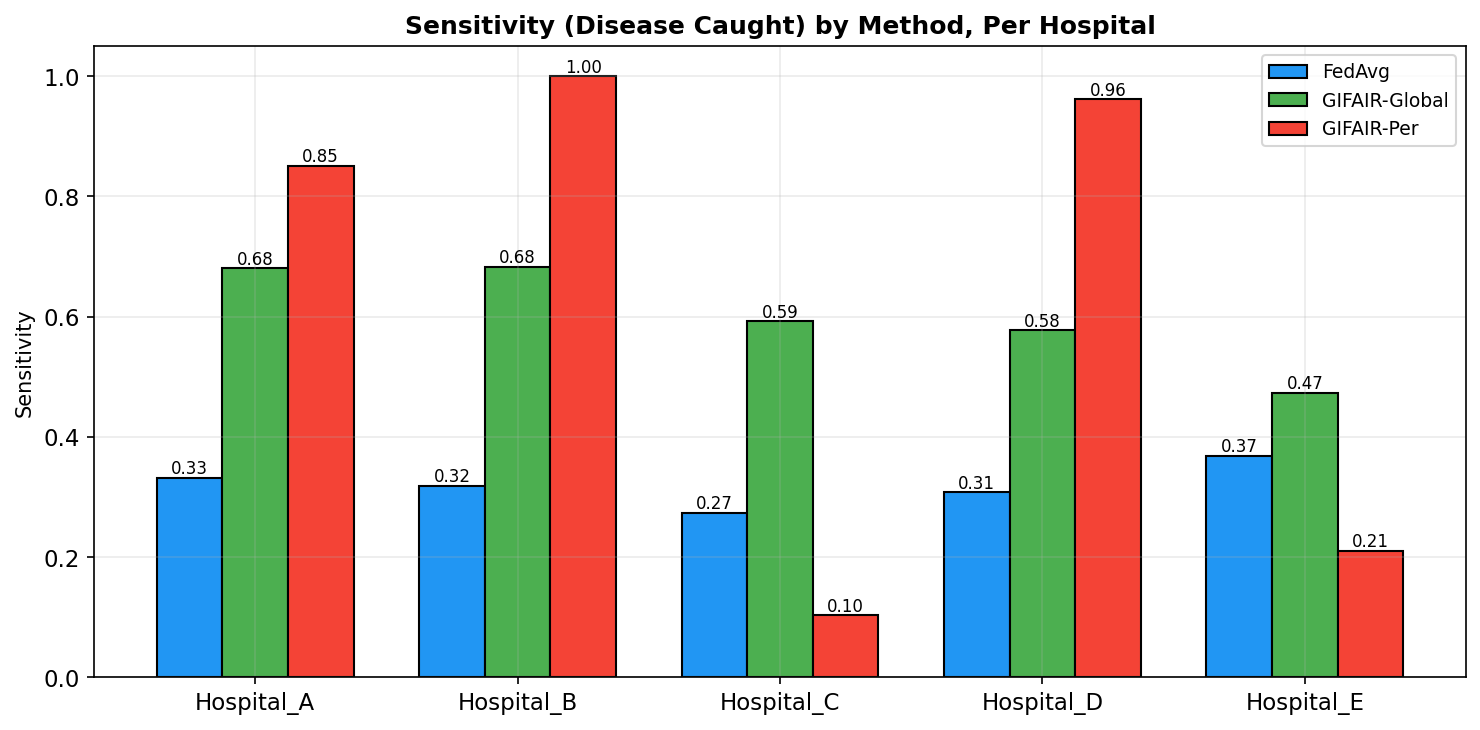

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
methods3 = [m for m in METHODS if is_discriminative[m]]
x = np.arange(len(HOSPITAL_NAMES))
width = 0.25

for i, m in enumerate(methods3):
    vals = []
    for h in HOSPITAL_NAMES:
        row = df_hospital[(df_hospital['Method']==m) & (df_hospital['Hospital']==h)]
        if len(row) == 0:
            vals.append(np.nan); continue
        fnr = row['fnr_at_0.5'].values[0]
        vals.append(1 - fnr if not np.isnan(fnr) else np.nan)  # sensitivity = 1 - FNR
    bars = ax.bar(x + i*width, vals, width, label=m, color=COLOURS[m], edgecolor="black")
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x()+bar.get_width()/2, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width); ax.set_xticklabels(HOSPITAL_NAMES)
ax.set_ylabel("Sensitivity"); ax.set_ylim(0, 1.05)
ax.set_title("Sensitivity (Disease Caught) by Method, Per Hospital")
ax.legend()
plt.tight_layout()
plt.savefig(f"{EVAL_DIR}/sensitivity_per_hospital.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
int_auc = (df_intersect.groupby(["Method","Sex","AgeGroup"])["roc_auc"].mean().round(4))

int_auc_gap = {}
for m in [mm for mm in METHODS if is_discriminative[mm]]:
    sub = int_auc.loc[m].dropna()
    if len(sub) >= 2:
        int_auc_gap[m] = round(sub.max() - sub.min(), 4)
        print(f"{m}: {len(sub)} cells, gap = {int_auc_gap[m]:.3f}")
    else:
        print(f"{m}: only {len(sub)} usable cell(s) — insufficient")

FedAvg: 9 cells, gap = 0.138
GIFAIR-Global: 9 cells, gap = 0.250
GIFAIR-Per: 9 cells, gap = 0.175


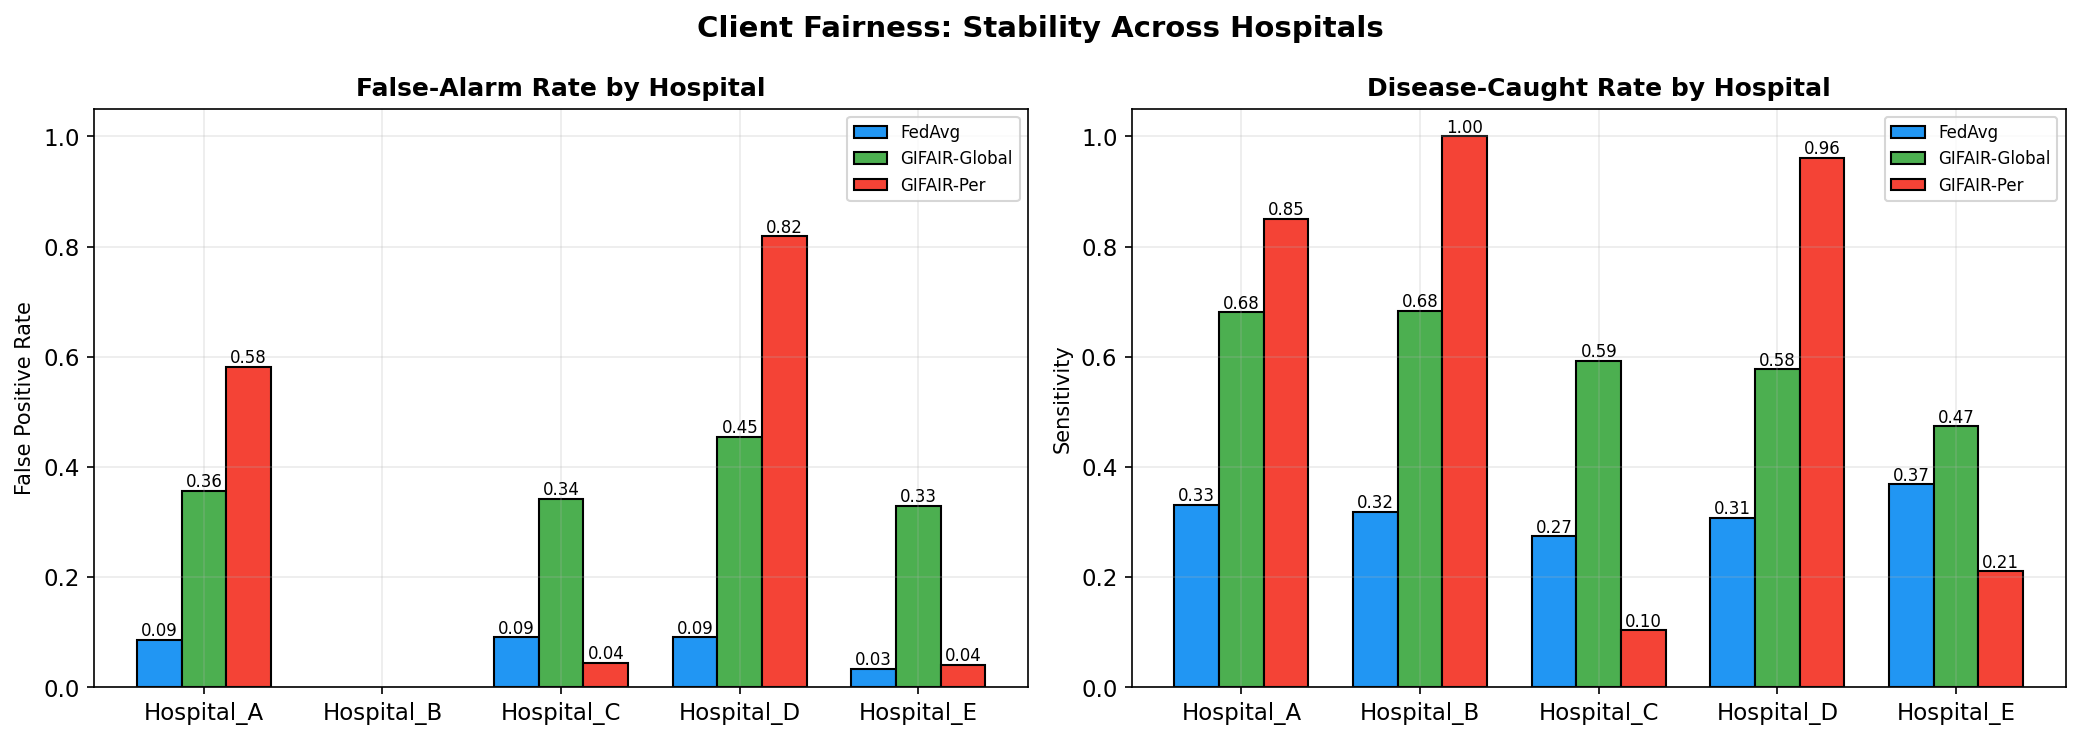

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
methods3 = [m for m in METHODS if is_discriminative[m]]
x = np.arange(len(HOSPITAL_NAMES))
width = 0.25

# Panel 1: FPR per hospital
for i, m in enumerate(methods3):
    vals = []
    for h in HOSPITAL_NAMES:
        row = df_hospital[(df_hospital['Method']==m) & (df_hospital['Hospital']==h)]
        if len(row) == 0:
            vals.append(np.nan); continue
        n = row['n'].values[0]
        prevalence = row['prevalence'].values[0] / 100
        fnr = row['fnr_at_0.5'].values[0]
        pred_rate = row['predicted_positive_rate'].values[0] / 100
        actual_neg = n * (1 - prevalence)
        if actual_neg == 0:
            vals.append(np.nan); continue
        actual_pos = n - actual_neg
        fn = actual_pos * fnr
        tp = actual_pos - fn
        pred_pos = n * pred_rate
        fp = pred_pos - tp
        vals.append(fp / actual_neg)
    bars = axes[0].bar(x + i*width, vals, width, label=m, color=COLOURS[m], edgecolor="black")
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            axes[0].text(bar.get_x()+bar.get_width()/2, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

axes[0].set_xticks(x + width); axes[0].set_xticklabels(HOSPITAL_NAMES)
axes[0].set_ylabel("False Positive Rate"); axes[0].set_ylim(0, 1.05)
axes[0].set_title("False-Alarm Rate by Hospital")
axes[0].legend(fontsize=8)

# Panel 2: Sensitivity per hospital
for i, m in enumerate(methods3):
    vals = []
    for h in HOSPITAL_NAMES:
        row = df_hospital[(df_hospital['Method']==m) & (df_hospital['Hospital']==h)]
        if len(row) == 0:
            vals.append(np.nan); continue
        fnr = row['fnr_at_0.5'].values[0]
        vals.append(1 - fnr if not np.isnan(fnr) else np.nan)
    bars = axes[1].bar(x + i*width, vals, width, label=m, color=COLOURS[m], edgecolor="black")
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            axes[1].text(bar.get_x()+bar.get_width()/2, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

axes[1].set_xticks(x + width); axes[1].set_xticklabels(HOSPITAL_NAMES)
axes[1].set_ylabel("Sensitivity"); axes[1].set_ylim(0, 1.05)
axes[1].set_title("Disease-Caught Rate by Hospital")
axes[1].legend(fontsize=8)

fig.suptitle("Client Fairness: Stability Across Hospitals", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{EVAL_DIR}/client_fairness_combined.png", dpi=300, bbox_inches="tight")
plt.show()

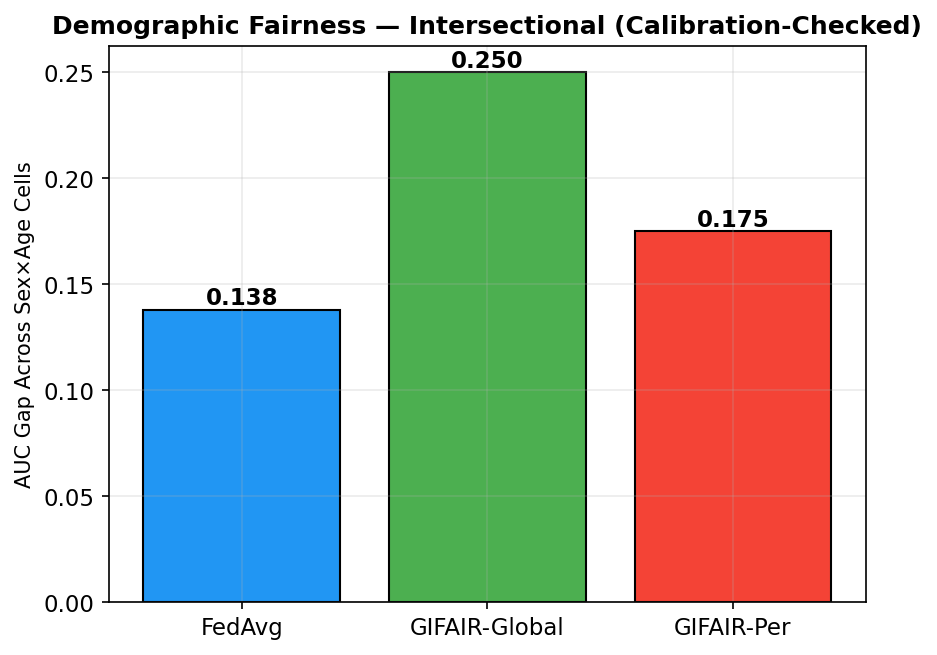

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))
methods3 = [m for m in METHODS if is_discriminative[m]]
vals = [0.138, 0.250, 0.175]  # FedAvg, GIFAIR-Global, GIFAIR-Per — from your printed output
bars = ax.bar(methods3, vals, color=[COLOURS[m] for m in methods3], edgecolor="black")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("AUC Gap Across Sex×Age Cells")
ax.set_title("Demographic Fairness — Intersectional (Calibration-Checked)")
plt.tight_layout()
plt.savefig(f"{EVAL_DIR}/intersectional_fairness_standalone.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.metrics import roc_curve

matched_gap = {}
for m in [mm for mm in METHODS if is_discriminative[mm]]:
    # Pool all hospitals for this method
    all_probs = np.concatenate([all_data[m][h][0] for h in HOSPITAL_NAMES])
    all_labels = np.concatenate([all_data[m][h][1] for h in HOSPITAL_NAMES])

    # Need per-sex probs/labels — rebuild from test_clients
    sex_probs = {'M': [], 'F': []}
    sex_labels = {'M': [], 'F': []}
    for h in HOSPITAL_NAMES:
        probs, labels = all_data[m][h]
        data = test_clients[h]
        for sex in ['M', 'F']:
            mask = data['Patient Sex'].values == sex
            sex_probs[sex].extend(probs[mask])
            sex_labels[sex].extend(labels[mask])

    target_fpr = 0.20  # common reference point across all methods
    tprs_at_target = {}
    for sex in ['M', 'F']:
        y = np.array(sex_labels[sex]); p = np.array(sex_probs[sex])
        if y.sum() == 0 or y.sum() == len(y):
            tprs_at_target[sex] = np.nan
            continue
        fpr, tpr, thresh = roc_curve(y, p)
        idx = np.argmin(np.abs(fpr - target_fpr))
        tprs_at_target[sex] = tpr[idx]

    gap = abs(tprs_at_target['M'] - tprs_at_target['F'])
    matched_gap[m] = gap
    print(f"{m}: TPR_M={tprs_at_target['M']:.3f}, TPR_F={tprs_at_target['F']:.3f}, matched gap={gap:.3f}")


FedAvg: TPR_M=0.593, TPR_F=0.553, matched gap=0.040
GIFAIR-Global: TPR_M=0.546, TPR_F=0.454, matched gap=0.091
GIFAIR-Per: TPR_M=0.778, TPR_F=0.754, matched gap=0.024


In [ ]:
print("=== Sex fairness: EOD (threshold-based) vs AUC gap (threshold-independent) ===")
for m in [mm for mm in METHODS if is_discriminative[mm]]:
    eod = mean_eod_sex.get(m, float('nan'))
    auc_gap = abs(sex_auc_valid[m]["M"] - sex_auc_valid[m]["F"])
    print(f"{m}: EOD={eod:.3f}, AUC gap={auc_gap:.3f}")

=== Sex fairness: EOD (threshold-based) vs AUC gap (threshold-independent) ===
FedAvg: EOD=0.043, AUC gap=0.050
GIFAIR-Global: EOD=0.075, AUC gap=0.059
GIFAIR-Per: EOD=0.025, AUC gap=0.051


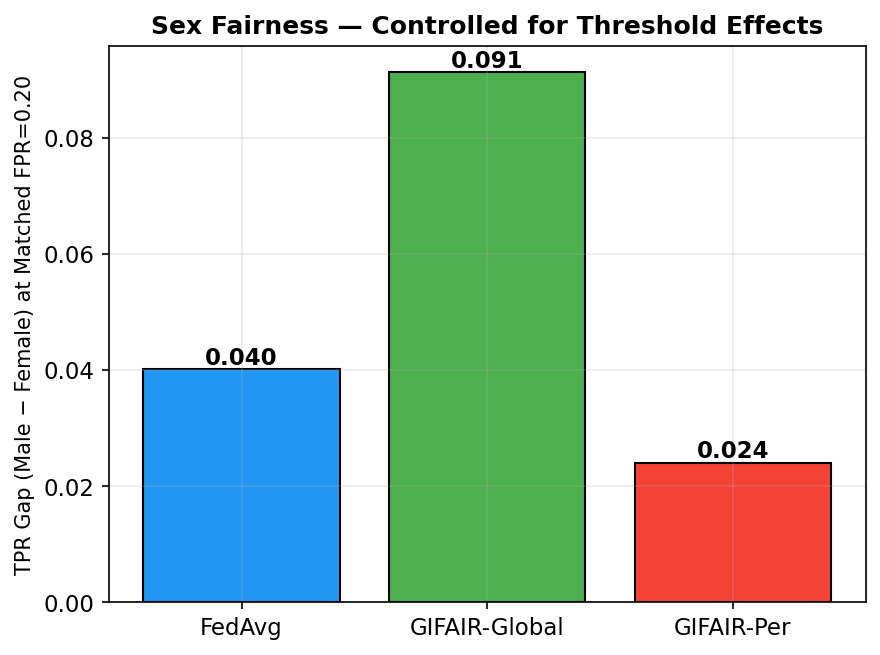

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))
methods3 = [m for m in METHODS if is_discriminative[m]]
vals = [matched_gap[m] for m in methods3]
bars = ax.bar(methods3, vals, color=[COLOURS[m] for m in methods3], edgecolor="black")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("TPR Gap (Male \u2212 Female) at Matched FPR=0.20")
ax.set_title("Sex Fairness — Controlled for Threshold Effects")
plt.tight_layout()
plt.savefig(f"{EVAL_DIR}/sex_fairness_matched_threshold.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
matched_gap_age = {}
for m in [mm for mm in METHODS if is_discriminative[mm]]:
    age_probs, age_labels = {}, {}
    for h in HOSPITAL_NAMES:
        probs, labels = all_data[m][h]
        data = test_clients[h]
        for grp in AGE_GROUPS:
            mask = data['Age Group'].values == grp
            age_probs.setdefault(grp, []).extend(probs[mask])
            age_labels.setdefault(grp, []).extend(labels[mask])

    target_fpr = 0.20
    tprs = {}
    for grp in AGE_GROUPS:
        y = np.array(age_labels[grp]); p = np.array(age_probs[grp])
        if len(y) < 10 or y.sum() == 0 or y.sum() == len(y):
            continue
        fpr, tpr, _ = roc_curve(y, p)
        idx = np.argmin(np.abs(fpr - target_fpr))
        tprs[grp] = tpr[idx]

    if len(tprs) >= 2:
        matched_gap_age[m] = max(tprs.values()) - min(tprs.values())
        print(f"{m}: {tprs}")
        print(f"  matched age gap = {matched_gap_age[m]:.3f}")

FedAvg: {'0-20': np.float64(0.4675925925925926), '20-40': np.float64(0.7033898305084746), '40-60': np.float64(0.5312208760484622), '60-80': np.float64(0.5368421052631579), '80+': np.float64(0.475)}
  matched age gap = 0.236
GIFAIR-Global: {'0-20': np.float64(0.5879629629629629), '20-40': np.float64(0.611864406779661), '40-60': np.float64(0.4547996272134203), '60-80': np.float64(0.4280701754385965), '80+': np.float64(0.225)}
  matched age gap = 0.387
GIFAIR-Per: {'0-20': np.float64(0.5972222222222222), '20-40': np.float64(0.8271186440677966), '40-60': np.float64(0.7325256290773532), '60-80': np.float64(0.7719298245614035), '80+': np.float64(0.65)}
  matched age gap = 0.230


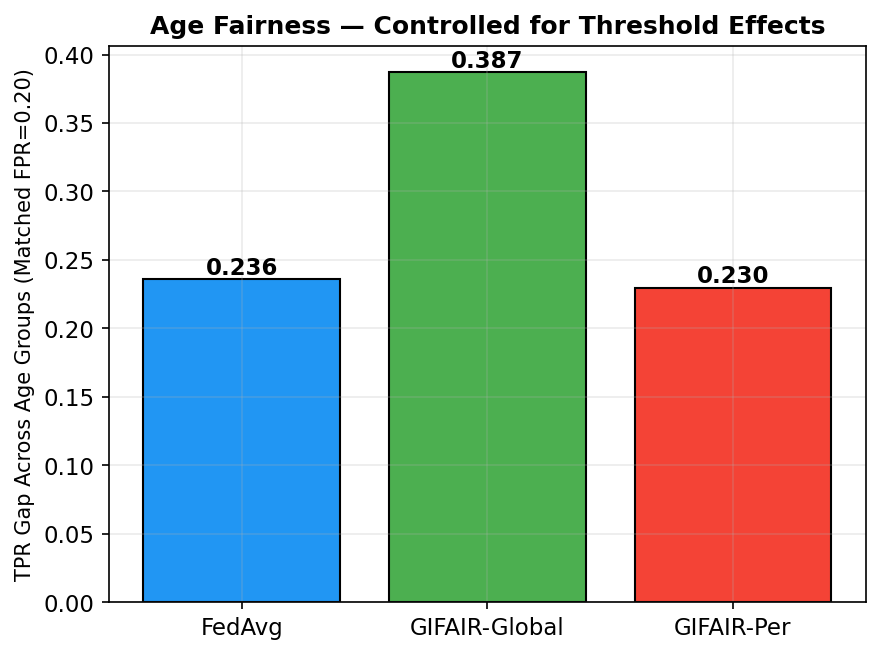

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))
methods3 = [m for m in METHODS if is_discriminative[m]]
vals = [matched_gap_age[m] for m in methods3]
bars = ax.bar(methods3, vals, color=[COLOURS[m] for m in methods3], edgecolor="black")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("TPR Gap Across Age Groups (Matched FPR=0.20)")
ax.set_title("Age Fairness — Controlled for Threshold Effects")
plt.tight_layout()
plt.savefig(f"{EVAL_DIR}/age_fairness_matched_threshold.png", dpi=300, bbox_inches="tight")
plt.show()

## Cell — Disconnect (guarded)
Only disconnects if the key output files were actually written — protects
against ending the session on a partially-failed run.

In [ ]:
'''expected_files = [
    f'{SAVE_DIR}/summary_all_methods_frozen_split.csv',
    f'{SAVE_DIR}/summary_global_all_methods_frozen_split.csv',
    f'{SAVE_DIR}/intersectional_subgroups_frozen_split.csv',
    f'{SAVE_DIR}/final_ranking_frozen_split.csv',
    f'{SAVE_DIR}/roc_curves_frozen_split.png',
    f'{SAVE_DIR}/pr_curves_frozen_split.png',
    f'{SAVE_DIR}/accuracy_bars_frozen_split.png',
    f'{SAVE_DIR}/fnr_bars_frozen_split.png',
    f'{SAVE_DIR}/poster_summary_bars.png',
    f'{SAVE_DIR}/publication_summary_table.csv',
    f'{SAVE_DIR}/confusion_matrices_fedavg_gifairglobal.png',
    f'{SAVE_DIR}/head_to_head_fedavg_gifairglobal.png',
    f'{SAVE_DIR}/plain_language_summary.txt',
]
expected_files += [
    f'{EVAL_DIR}/trade_off_scatter.png',
    f'{EVAL_DIR}/intersectional_heatmap.png',
    f'{EVAL_DIR}/predicted_positive_pictogram_3methods.png',
    f'{EVAL_DIR}/fpr_by_method.png',
    f'{EVAL_DIR}/sex_auc_comparison.png',
    f'{EVAL_DIR}/sensitivity_specificity_by_method.png',
]

all_saved = all(os.path.exists(f) for f in expected_files)

if all_saved:
    print("✓ All evaluation outputs confirmed saved — disconnecting session")
    from google.colab import runtime
    runtime.unassign()
else:
    missing = [f for f in expected_files if not os.path.exists(f)]
    print("⚠ Missing files — NOT disconnecting:", missing)
    '''

'expected_files = [\n    f\'{SAVE_DIR}/summary_all_methods_frozen_split.csv\',\n    f\'{SAVE_DIR}/summary_global_all_methods_frozen_split.csv\',\n    f\'{SAVE_DIR}/intersectional_subgroups_frozen_split.csv\',\n    f\'{SAVE_DIR}/final_ranking_frozen_split.csv\',\n    f\'{SAVE_DIR}/roc_curves_frozen_split.png\',\n    f\'{SAVE_DIR}/pr_curves_frozen_split.png\',\n    f\'{SAVE_DIR}/accuracy_bars_frozen_split.png\',\n    f\'{SAVE_DIR}/fnr_bars_frozen_split.png\',\n    f\'{SAVE_DIR}/poster_summary_bars.png\',\n    f\'{SAVE_DIR}/publication_summary_table.csv\',\n    f\'{SAVE_DIR}/confusion_matrices_fedavg_gifairglobal.png\',\n    f\'{SAVE_DIR}/head_to_head_fedavg_gifairglobal.png\',\n    f\'{SAVE_DIR}/plain_language_summary.txt\',\n]\nexpected_files += [\n    f\'{EVAL_DIR}/trade_off_scatter.png\',\n    f\'{EVAL_DIR}/intersectional_heatmap.png\',\n    f\'{EVAL_DIR}/predicted_positive_pictogram_3methods.png\',\n    f\'{EVAL_DIR}/fpr_by_method.png\',\n    f\'{EVAL_DIR}/sex_auc_comparison.png\',\n